# In this version T_c value have been hard-coded from Chi. In previous version of this code the T_c was calculated from Xib.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/isingdata-h5py-jb/G1_J1_data.h5py
/kaggle/input/isingdata-h5py-jb/Gp5_data.h5py
/kaggle/input/isingdata-h5py-jb/Gp1_data.h5py
/kaggle/input/isingdata-h5py-jb/G1_Jp01_data.h5py
/kaggle/input/isingdata-h5py-jb/G0_data.h5py


In [2]:
from __future__ import print_function, division
import os,sys
import numpy as np
import torch # pytorch package, allows using GPUs
# fix seed
seed=17
np.random.seed(seed)
torch.manual_seed(seed)

import pandas as pd
from tqdm.notebook import tqdm
from tqdm.notebook import trange
import pickle
import matplotlib.pyplot as plt

import time
start = time.time()


import scipy
import seaborn as sns
sns.set_style("whitegrid")

In [3]:
# Folder names for plots
images_folder_name = "images_for_Models_trained_on_Full_data"

if not os.path.isdir(images_folder_name):
    os.mkdir(images_folder_name)
    
if not os.path.isdir("Generated_plots"):
    os.mkdir("Generated_plots")
    
folder_path = os.path.join("Generated_plots","accuracies_and_losses")
if not os.path.isdir(folder_path):
    os.mkdir(folder_path)

In [4]:
import argparse # handles arguments
import sys; sys.argv=['']; del sys # required to use parser in jupyter notebooks

# training settings
parser = argparse.ArgumentParser(description='PyTorch Convmodel Ising Example')
parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                    help='input batch size for training (default: 64)')
parser.add_argument('--test-batch-size', type=int, default=5000, metavar='N',
                    help='input batch size for testing (default: 5000)')
parser.add_argument('--epochs', type=int, default=10, metavar='N',
                    help='number of epochs to train (default: 10)')
parser.add_argument('--lr', type=float, default=0.01, metavar='LR',
                    help='learning rate (default: 0.01)')
parser.add_argument('--momentum', type=float, default=0.5, metavar='M',
                    help='SGD momentum (default: 0.5)')
parser.add_argument('--no-cuda', action='store_true', default=False,
                    help='disables CUDA training')
parser.add_argument('--seed', type=int, default=1, metavar='S',
                    help='random seed (default: 1)')
parser.add_argument('--log-interval', type=int, default=500, metavar='N',
                    help='how many batches to wait before logging training status')
args = parser.parse_args()
args.epochs=50
args.cuda = not args.no_cuda and torch.cuda.is_available()

torch.manual_seed(args.seed)
if args.cuda:
    torch.cuda.manual_seed(args.seed)

cuda_kwargs = {'num_workers': 16, 'pin_memory': True} if args.cuda else {}

In [5]:
def Magnetization(configeration):
    """Given the configeration this functions outputs the total magnetization
    of that configeration"""
    return np.average(np.average(configeration))


def energy(configeration, J):
    """Give a configeration and value of J this functions caluculates the
    energy of the configeration considering the nearest neighbout interactions
    without external magnetic field """
    # E=-J*($\sum_{<i,j>}\sigma_i * \sigma_j $ )
    L = configeration.shape[0]
    Energy = 0

    for i in range(L):
        for j in range(L):
            S = configeration[i, j]
            nb_spins = neighbouring_spins(configeration, (i, j))
            Energy += np.sum(S * nb_spins)

    Energy = -0.5 * J * Energy
    return Energy


def energy2(configeration, J):
    """Same as energy(configeration, J) just faster"""
    L = configeration.shape[0]
    Energy = 0

    Energy += np.sum(np.sum(configeration[:, :-1] * configeration[:, 1:]))
    Energy += np.sum(np.sum(configeration[:, 0] * configeration[:, -1]))
    Energy += np.sum(np.sum(configeration[:-1, :] * configeration[1:, :]))
    Energy += np.sum(np.sum(configeration[0, :] * configeration[-1, :]))
    Energy = -J * Energy
    return Energy


def magnetic_susceptibility(Magnetization_list, T):
    k_b = 1
    beta = 1/(k_b*T)
    # N = L * L
    chi = (beta) * (np.average(Magnetization_list * Magnetization_list) -
                    np.average(np.abs(Magnetization_list))**2)
    return chi





# Transform
class Random_shuffle_Transform:
    """Given a configeration this transform randomly shuffles
    the configeration and retuns a new configeration without
    effecting the old one

    In this Class Labels will be uneffected.
    """

    def __call__(self, sample):
        inputs, targets = sample
        L1, L2 = inputs.shape
        inputs_transformed = np.copy(inputs)
        inputs_transformed = inputs_transformed.reshape(L1 * L2)
        rng = np.random.default_rng()
        inputs_transformed = rng.permutation(inputs_transformed)
        inputs_transformed = inputs_transformed.reshape(L1, L2)

        return inputs_transformed, targets


def Random_shuffle_configerations(input_configeration_array):
    """Give a an input array of shape (N, L1, L2) keeping the 
    N index fixed the functions Randomly shuffles the data in
    L1 and L2 indices i.e Given an array with N configeration
    this function shuffles the spins inside each configeration """
    N, L1, L2 = input_configeration_array.shape
    output_configeration_array = np.copy(input_configeration_array)
    output_configeration_array = output_configeration_array.reshape(
        -1, L1 * L2)
    for i in range(N):
        rng = np.random.default_rng()
        output_configeration_array[i] = rng.permutation(
            output_configeration_array[i])
    output_configeration_array = output_configeration_array.reshape(N, L1, L2)

    return output_configeration_array

# Creating pandas data frame to store the results for the paper

In [6]:
import pandas as pd

columns = ["Temperature Range","T_c","1_layer_DNN", "3_layer_DNN", "CNN","1_layer_DNN_FFT", "3_layer_DNN_FFT", "CNN_FFT"]
index = ["J=1.0,G=0.0,Critical", "J=1.0,G=0.0,Non-Critical", "J=1.0,G=0.1,Critical","J=1.0,G=0.1,Non-Critical", "J=1.0,G=0.5,Critical", "J=1.0,G=0.5,Non-Critical"]
index.extend(["J=0.0,G=1.0,Critical", "J=0.0,G=1.0,Non-Critical"])
index.extend(["J=1.0,G=1.0,Critical", "J=1.0,G=1.0,Non-Critical"])
Phase_accuracies_df = pd.DataFrame(None, index=index, columns=columns)

print(Phase_accuracies_df.loc["J=1.0,G=0.0,Critical", "1_layer_DNN"])
Phase_accuracies_df

nan


,Temperature Range,T_c,1_layer_DNN,3_layer_DNN,CNN,1_layer_DNN_FFT,3_layer_DNN_FFT,CNN_FFT
"J=1.0,G=0.0,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.0,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.1,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.1,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.5,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.5,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=0.0,G=1.0,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=0.0,G=1.0,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=1.0,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=1.0,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
%%time

import h5py
f5_G0 = h5py.File("../input/isingdata-h5py-jb/G0_data.h5py",'r')
f5_G1_J0 = h5py.File("../input/isingdata-h5py-jb/G1_Jp01_data.h5py",'r')
f5_G1_J1 = h5py.File("../input/isingdata-h5py-jb/G1_J1_data.h5py",'r')
f5_Gp1 = h5py.File("../input/isingdata-h5py-jb/Gp1_data.h5py",'r')
f5_Gp5 = h5py.File("../input/isingdata-h5py-jb/Gp5_data.h5py",'r')

CPU times: user 29.7 ms, sys: 11 ms, total: 40.7 ms
Wall time: 164 ms


# G=0 Train

In [8]:
%%time

#------------------------------------------
import pickle
#------------------------------------------

# Copied mostly from my Data_read_folder_specific.py file with necessory changes  
# -----------------------------------------------------------------------------------
# Parameters
Targs=np.arange(61)
L = 40
T_array = f5_G0['Ts'][:]
G = 0.0
J = 1.0

# folder name for saving the G=0.0 data in .pkl format
G_0_pkl_folder_path = f"G_0_data_in_pkl_format"
if not os.path.isdir(G_0_pkl_folder_path):
    os.mkdir(G_0_pkl_folder_path)

No_configerations_for_each_T = 10000 
for i in trange(T_array.shape[0]):
    T = T_array[i]
    data = f5_G0['arrs'][i,:,:].reshape(-1, L, L).astype("int8")
    
    data_output_file_name = f"configerations_L_{L}_G_{G:.2f}_J_{J:.2f}_T_{T:.6f}_.pkl"
# print(data_output_file_name)
    path = os.path.join(G_0_pkl_folder_path, data_output_file_name)
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    
# -----------------------------------------------------------------------------------
# To save space
del data

  0%|          | 0/61 [00:00<?, ?it/s]

CPU times: user 7.78 s, sys: 3.32 s, total: 11.1 s
Wall time: 15.2 s


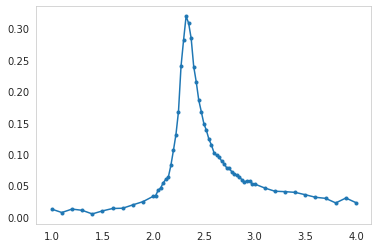

,Temperature Range,T_c,1_layer_DNN,3_layer_DNN,CNN,1_layer_DNN_FFT,3_layer_DNN_FFT,CNN_FFT
"J=1.0,G=0.0,Critical","[1.000 ,4.000]","[2.325 ,2.350]",NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.0,Non-Critical","[1.000 ,4.000]","[2.325 ,2.350]",NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.1,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.1,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.5,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.5,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=0.0,G=1.0,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=0.0,G=1.0,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=1.0,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=1.0,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
#---------------------------------------
#Critical Region: 
#---------------------------------------
Targs=np.arange(61)
xiBs=f5_G0['xiBs'][:]
factor=0.30 # Parameter which determines critical region
cut=np.amax(xiBs)*factor
labels_tmp=np.heaviside(xiBs[Targs]-cut,1.0)
crit_start=np.where(labels_tmp==1.0)[0][0]
crit_end=np.where(labels_tmp==1.0)[0][-1]

#######Critical temperature hardcoded#####################
#crit_Temp=(T_array[xiBs.argsort()[-1]]+T_array[xiBs.argsort()[-2]])/2
crit_Temp = 2.3125
######################

#print(T_array[crit_start])
#print(T_array[crit_end])
#print(T_array[crit_pt])
#print(xiBs.argsort()[-1])
#---------------------------------------

plt.figure()
plt.plot(T_array,xiBs,".-")
plt.grid()
plt.show()


# --------------------------------------
Phase_accuracies_df.loc["J=1.0,G=0.0,Critical", "Temperature Range"] = f"[{T_array[0]:.3f} ,{T_array[-1]:.3f}]"
Phase_accuracies_df.loc["J=1.0,G=0.0,Non-Critical", "Temperature Range"] = f"[{T_array[0]:.3f} ,{T_array[-1]:.3f}]"
Phase_accuracies_df.loc["J=1.0,G=0.0,Critical", "T_c"] = f"[{T_array[xiBs.argsort()[-1]]:.3f} ,{T_array[xiBs.argsort()[-2]]:.3f}]"
Phase_accuracies_df.loc["J=1.0,G=0.0,Non-Critical", "T_c"] = f"[{T_array[xiBs.argsort()[-1]]:.3f} ,{T_array[xiBs.argsort()[-2]]:.3f}]"
Phase_accuracies_df

In [10]:
%%time
# Creating ordered_partial,disordered_partial,ordered_complete,disordered_complete,critical data .pkl files for G=0.0


No_configerations_for_each_T = 10000 
# Copied mostly from my Analyze_folder_specific.py file with necessory changes  
# -----------------------------------------------------------------------------------
# Parameters that need to be set manually --------------------------------------------------------------<
J = 1.0
G = 0.0
T_critical = crit_Temp # From CHi values
T_low_for_critical = T_array[crit_start] # From XiB values
T_up_for_critical = T_array[crit_end] # From XiB values
print("J = ", J)
print("G = ", G)
print("T_critical = ", T_critical)
print("T_low_for_critical = ", T_low_for_critical)
print("T_up_for_critical = ", T_up_for_critical)
# ------------------------------------------------------------------------------------------------------>

# Saving all the file names into a dictionary called data file name

G_0_pkl_folder_path = f"./G_0_data_in_pkl_format"
data_file_names_list = []
for file_name in os.listdir(G_0_pkl_folder_path):
    if file_name.endswith('.pkl'):
        if file_name.startswith("configerations_"):
            data_file_names_list.append(file_name)

            
# Storing the data into ordered,disordered and critical data sets --------------------------------------<
# Here I have add "X_ordered_partial" and "X_disordered_partial" data sets contains ordered
# and disordered datasets respectively which are not a part of critical dataset
X_ordered_partial = []
X_disordered_partial = []
Y_ordered_partial = []
Y_disordered_partial = []
X_critical = []
Y_critical = []
T_list = []
for configerations_file_name in data_file_names_list:
    configerations_file_path = os.path.join(G_0_pkl_folder_path,configerations_file_name)
    T = float(configerations_file_name.split("_")[8])
    T_list.append(T)
    with open(configerations_file_path, 'rb') as f:
        configerations = pickle.load(f)

    if T < T_low_for_critical:
        X_ordered_partial.append(configerations)
        Y_ordered_partial.append(np.ones(configerations.shape[0]))
    elif T > T_up_for_critical:
        X_disordered_partial.append(configerations)
        Y_disordered_partial.append(np.zeros(configerations.shape[0]))

    elif (T <= T_up_for_critical) and (T >= T_low_for_critical):
        X_critical.append(configerations)
        if T < T_critical:
            Y_critical.append(np.ones(configerations.shape[0]))
        else:
            Y_critical.append(np.zeros(configerations.shape[0]))


X_ordered_partial = np.concatenate(tuple(X_ordered_partial), axis=0)
Y_ordered_partial = np.concatenate(tuple(Y_ordered_partial), axis=0)
X_disordered_partial = np.concatenate(tuple(X_disordered_partial), axis=0)
Y_disordered_partial = np.concatenate(tuple(Y_disordered_partial), axis=0)
X_critical = np.concatenate(tuple(X_critical), axis=0)
Y_critical = np.concatenate(tuple(Y_critical), axis=0)

# Printing shapes of X and unique values of Y Just to checck every thing is fine
# print("X_ordered_partial shape = ", X_ordered_partial.shape)
# print("X_disordered_partial shape = ", X_disordered_partial.shape)
# print("X_critical shape = ", X_critical.shape)
# print("Y_ordered_partial unique values ", np.unique(
#     Y_ordered_partial, return_counts=True))
# print("Y_disordered_partial unique values ", np.unique(
#     Y_disordered_partial, return_counts=True))
# print("Y_critical unique values ", np.unique(Y_critical, return_counts=True))

X_ordered_partial_file_name = "X_ordered_partial.pkl"
X_ordered_partial_file_path = os.path.join(G_0_pkl_folder_path,X_ordered_partial_file_name)
X_disordered_partial_file_name = "X_disordered_partial.pkl"
X_disordered_partial_file_path = os.path.join(G_0_pkl_folder_path,X_disordered_partial_file_name)
X_critical_file_name = "X_critical.pkl"
X_critical_file_path = os.path.join(G_0_pkl_folder_path,X_critical_file_name)
Y_ordered_partial_file_name = "Y_ordered_partial.pkl"
Y_ordered_partial_file_path = os.path.join(G_0_pkl_folder_path,Y_ordered_partial_file_name)
Y_disordered_partial_file_name = "Y_disordered_partial.pkl"
Y_disordered_partial_file_path = os.path.join(G_0_pkl_folder_path,Y_disordered_partial_file_name)
Y_critical_file_name = "Y_critical.pkl"
Y_critical_file_path = os.path.join(G_0_pkl_folder_path,Y_critical_file_name)

with open(X_ordered_partial_file_path, 'wb') as f:
    pickle.dump(X_ordered_partial, f)

with open(X_disordered_partial_file_path, 'wb') as f:
    pickle.dump(X_disordered_partial, f)

with open(X_critical_file_path, 'wb') as f:
    pickle.dump(X_critical, f)

with open(Y_ordered_partial_file_path, 'wb') as f:
    pickle.dump(Y_ordered_partial, f)

with open(Y_disordered_partial_file_path, 'wb') as f:
    pickle.dump(Y_disordered_partial, f)

with open(Y_critical_file_path, 'wb') as f:
    pickle.dump(Y_critical, f)
# ------------------------------------------------------------------------------------------------------>


# Storing the data into ordered and disordered data sets -----------------------------------------------<
# Here I have add "X_ordered_complete" and "X_disordered_complete" data sets contains ordered
# and disordered datasets respectively which are also included in critical dataset
X_ordered_complete = []
X_disordered_complete = []
Y_ordered_complete = []
Y_disordered_complete = []
for configerations_file_name in data_file_names_list:
    configerations_file_path = os.path.join(G_0_pkl_folder_path,configerations_file_name)
    T = float(configerations_file_name.split("_")[8])
    with open(configerations_file_path, 'rb') as f:
        configerations = pickle.load(f)

    if T < T_critical:
        X_ordered_complete.append(configerations)
        Y_ordered_complete.append(np.ones(configerations.shape[0]))
    else:
        X_disordered_complete.append(configerations)
        Y_disordered_complete.append(np.zeros(configerations.shape[0]))


X_ordered_complete = np.concatenate(tuple(X_ordered_complete), axis=0)
Y_ordered_complete = np.concatenate(tuple(Y_ordered_complete), axis=0)
X_disordered_complete = np.concatenate(tuple(X_disordered_complete), axis=0)
Y_disordered_complete = np.concatenate(tuple(Y_disordered_complete), axis=0)



# # Printing shapes of X and unique values of Y Just to checck every thing is fine
# print("X_ordered_complete shape = ", X_ordered_complete.shape)
# print("X_disordered_complete shape = ", X_disordered_complete.shape)
# print("Y_ordered_complete unique values ", np.unique(
#     Y_ordered_complete, return_counts=True))
# print("Y_disordered_complete unique values ", np.unique(
#     Y_disordered_complete, return_counts=True))



X_ordered_complete_file_name = "X_ordered_complete.pkl"
X_ordered_complete_file_path = os.path.join(G_0_pkl_folder_path,X_ordered_complete_file_name)
X_disordered_complete_file_name = "X_disordered_complete.pkl"
X_disordered_complete_file_path = os.path.join(G_0_pkl_folder_path,X_disordered_complete_file_name)
Y_ordered_complete_file_name = "Y_ordered_complete.pkl"
Y_ordered_complete_file_path = os.path.join(G_0_pkl_folder_path,Y_ordered_complete_file_name)
Y_disordered_complete_file_name = "Y_disordered_complete.pkl"
Y_disordered_complete_file_path = os.path.join(G_0_pkl_folder_path,Y_disordered_complete_file_name)

with open(X_ordered_complete_file_path, 'wb') as f:
    pickle.dump(X_ordered_complete, f)

with open(X_disordered_complete_file_path, 'wb') as f:
    pickle.dump(X_disordered_complete, f)

with open(Y_ordered_complete_file_path, 'wb') as f:
    pickle.dump(Y_ordered_complete, f)

with open(Y_disordered_complete_file_path, 'wb') as f:
    pickle.dump(Y_disordered_complete, f)

print()
# ------------------------------------------------------------------------------------------------------>

# Storing all the imporant paramets into a dictionart to be used in future------------------------------<
important_parameters_file_name = "important_parameters.pkl"
important_parameters_dict = {}
important_parameters_dict["J"] = J
important_parameters_dict["G"] = G
T_list.sort()
important_parameters_dict["T_list"] = T_list
important_parameters_dict["T_critical"] = T_critical
important_parameters_dict["T_low_for_critical"] = T_low_for_critical
important_parameters_dict["T_up_for_critical"] = T_up_for_critical
important_parameters_dict["No_configerations_for_each_T"] = No_configerations_for_each_T

important_parameters_file_path = os.path.join(G_0_pkl_folder_path,important_parameters_file_name)
with open(important_parameters_file_path, 'wb') as f:
    pickle.dump(important_parameters_dict, f)


print()
print("-----printing all the imporant paramets(also stored in the file xxx) into a dictionart to be used in future-----")
print(important_parameters_dict)

# ------------------------------------------------------------------------------------------------------>

# To save space
del X_ordered_partial, X_disordered_partial, Y_ordered_partial 
del Y_disordered_partial, X_critical, Y_critical, X_ordered_complete
del Y_ordered_complete, X_disordered_complete, Y_disordered_complete

J =  1.0
G =  0.0
T_critical =  2.3125
T_low_for_critical =  2.2
T_up_for_critical =  2.625


-----printing all the imporant paramets(also stored in the file xxx) into a dictionart to be used in future-----
{'J': 1.0, 'G': 0.0, 'T_list': [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.025, 2.05, 2.075, 2.1, 2.125, 2.15, 2.175, 2.2, 2.225, 2.25, 2.275, 2.3, 2.325, 2.35, 2.375, 2.4, 2.425, 2.45, 2.475, 2.5, 2.525, 2.55, 2.575, 2.6, 2.625, 2.65, 2.675, 2.7, 2.725, 2.75, 2.775, 2.8, 2.825, 2.85, 2.875, 2.9, 2.925, 2.95, 2.975, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0], 'T_critical': 2.3125, 'T_low_for_critical': 2.2, 'T_up_for_critical': 2.625, 'No_configerations_for_each_T': 10000}
CPU times: user 1.09 s, sys: 3.64 s, total: 4.73 s
Wall time: 5.48 s


# Training with G=0 train data set

Data Loader

In [11]:
#########################
# Data Loader
#########################

from torchvision import datasets  # load data


class Ising_Dataset(torch.utils.data.Dataset):
    """Ising pytorch dataset."""

    def __init__(self, data_type, transform=False):
        """
        Args:
            data_type (string): `train`, `test` or `critical`: creates data_loader
            transform (callable, optional): Optional transform to be applied on a sample.

        """

        from sklearn.model_selection import train_test_split
        import collections
        import pickle as pickle

        # load data
        G_0_pkl_data_folder_path = "./G_0_data_in_pkl_format"

        # "X_ordered_partial" and "X_disordered_partial" data sets contains ordered
        # and disordered datasets respectively which are not a part of critical dataset
        X_ordered_partial_file_name = "X_ordered_partial.pkl"
        X_ordered_partial_file_path = os.path.join(
            G_0_pkl_data_folder_path, X_ordered_partial_file_name)

        X_disordered_partial_file_name = "X_disordered_partial.pkl"
        X_disordered_partial_file_path = os.path.join(
            G_0_pkl_data_folder_path, X_disordered_partial_file_name)

        X_critical_file_name = "X_critical.pkl"
        X_critical_file_path = os.path.join(
            G_0_pkl_data_folder_path, X_critical_file_name)

        Y_ordered_partial_file_name = "Y_ordered_partial.pkl"
        Y_ordered_partial_file_path = os.path.join(
            G_0_pkl_data_folder_path, Y_ordered_partial_file_name)

        Y_disordered_partial_file_name = "Y_disordered_partial.pkl"
        Y_disordered_partial_file_path = os.path.join(
            G_0_pkl_data_folder_path, Y_disordered_partial_file_name)

        Y_critical_file_name = "Y_critical.pkl"
        Y_critical_file_path = os.path.join(
            G_0_pkl_data_folder_path, Y_critical_file_name)

        with open(X_ordered_partial_file_path, 'rb') as f:
            X_ordered_partial = pickle.load(f)

        with open(X_disordered_partial_file_path, 'rb') as f:
            X_disordered_partial = pickle.load(f)

        with open(X_critical_file_path, 'rb') as f:
            X_critical = pickle.load(f)

        with open(Y_ordered_partial_file_path, 'rb') as f:
            Y_ordered_partial = pickle.load(f)
            # This done so tha torch does not give the error
            # expected scalar type Long but found Double
            Y_ordered_partial = np.int64(Y_ordered_partial)

        with open(Y_disordered_partial_file_path, 'rb') as f:
            Y_disordered_partial = pickle.load(f)
            # This done so tha torch does not give the error
            # expected scalar type Long but found Double
            Y_disordered_partial = np.int64(Y_disordered_partial)

        with open(Y_critical_file_path, 'rb') as f:
            Y_critical = pickle.load(f)
            # This done so tha torch does not give the error
            # expected scalar type Long but found Double
            Y_critical = np.int64(Y_critical)

        # "X_ordered_complete" and "X_disordered_complete" data sets contains ordered
        # and disordered datasets respectively which are also included in critical dataset
        X_ordered_complete_file_name = "X_ordered_complete.pkl"
        X_ordered_complete_file_path = os.path.join(
            G_0_pkl_data_folder_path, X_ordered_complete_file_name)

        X_disordered_complete_file_name = "X_disordered_complete.pkl"
        X_disordered_complete_file_path = os.path.join(
            G_0_pkl_data_folder_path, X_disordered_complete_file_name)

        Y_ordered_complete_file_name = "Y_ordered_complete.pkl"
        Y_ordered_complete_file_path = os.path.join(
            G_0_pkl_data_folder_path, Y_ordered_complete_file_name)

        Y_disordered_complete_file_name = "Y_disordered_complete.pkl"
        Y_disordered_complete_file_path = os.path.join(
            G_0_pkl_data_folder_path, Y_disordered_complete_file_name)

        with open(X_ordered_complete_file_path, 'rb') as f:
            X_ordered_complete = pickle.load(f)

        with open(X_disordered_complete_file_path, 'rb') as f:
            X_disordered_complete = pickle.load(f)

        with open(Y_ordered_complete_file_path, 'rb') as f:
            Y_ordered_complete = pickle.load(f)
            # This done so tha torch does not give the error
            # expected scalar type Long but found Double
            Y_ordered_complete = np.int64(Y_ordered_complete)

        with open(Y_disordered_complete_file_path, 'rb') as f:
            Y_disordered_complete = pickle.load(f)
            # This done so tha torch does not give the error
            # expected scalar type Long but found Double
            Y_disordered_complete = np.int64(Y_disordered_complete)

        # pick random data points from ordered and disordered states to create the training and test sets
        # X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,train_size=0.8)

        if data_type == 'train_without_critucal':
            X = np.concatenate((X_ordered_partial, X_disordered_partial))
            Y = np.concatenate((Y_ordered_partial, Y_disordered_partial))
            print("Training datasets: ordered_partial and disordered_partial data set")

        if data_type == 'train_with_critucal':
            X = np.concatenate((X_ordered_complete, X_disordered_complete))
            Y = np.concatenate((Y_ordered_complete, Y_disordered_complete))
            print("Training datasets: ordered_complete and disordered_complete data set")

        if data_type == 'critical':
            X = X_critical
            Y = Y_critical
            print("Critical Data set")

        # these are necessary attributes in dataset class and must be assigned
        self.data = (X, Y)
        self.transform = transform

    # override __len__ and __getitem__ of the Dataset() class

    def __len__(self):
        return len(self.data[1])

    def __getitem__(self, idx):

        sample = (self.data[0][idx, ...], self.data[1][idx])
        if self.transform:
            sample = self.transform(sample)

        return sample


def load_data_for_training_without_critcal_dataset(kwargs, transform=False):
    # kwargs:  CUDA arguments, if enabled
    # load and noralise train,test, and data
    train_loader = torch.utils.data.DataLoader(
        Ising_Dataset(data_type='train_without_critucal', transform= transform),
        batch_size=args.batch_size, shuffle=True,**kwargs)

    critical_loader = torch.utils.data.DataLoader(
        Ising_Dataset(data_type='critical', transform= transform),
        batch_size=args.test_batch_size, shuffle=True,**kwargs)

    return train_loader, critical_loader


def load_data_for_training_with_critcal_dataset(kwargs, transform=False):
    # kwargs:  CUDA arguments, if enabled
    # load and noralise train,test, and data
    train_loader = torch.utils.data.DataLoader(
        Ising_Dataset(data_type='train_with_critucal', transform= transform),
        batch_size=args.batch_size, shuffle=True,**kwargs)

    critical_loader = torch.utils.data.DataLoader(
        Ising_Dataset(data_type='critical', transform= transform),
        batch_size=args.test_batch_size, shuffle=True,**kwargs)

    return train_loader, critical_loader


Writing the Class for all the models

In [12]:
################################
#Defining the models 
################################

import torch.nn as nn # construct NN


################################
# CNN model
################################

class CNN_model(nn.Module):
    # create convolutional net
    def __init__(self, N=10, L=40,kernel_size=2):
        # inherit attributes and methods of nn.Module
        super(CNN_model, self).__init__()	
        # create convolutional layer with input depth 1 and output depth N
        self.conv1 = nn.Conv2d(1, N, kernel_size=kernel_size, padding=int(kernel_size/2))
        # batch norm layer takes Depth
        self.bn1=nn.BatchNorm2d(N) 
        # create fully connected layer after maxpool operation reduced 40->18
        self.fc1 = nn.Linear(20*20*N, 2) 	
        self.N=N
        self.L=L
        print("The number of neurons in CNN layer is %i"%(N))

    def forward(self, x):
        #Unsqueeze command indicates one channel and turns x.shape from (:,40,40) to (:,1, 40,40)
        x=F.relu(self.conv1(torch.unsqueeze(x,1).float()))
        #print(x.shape)  #often useful to look at shapes for debugging
        x = F.max_pool2d(x,2)	 
        #print(x.shape)
        x=self.bn1(x) # largely unnecessary and here just for pedagogical purposes
        #print(F.log_softmax(self.fc1(x.view(-1,20*20*self.N)), dim=1).shape)
        return F.log_softmax(self.fc1(x.view(-1,20*20*self.N)), dim=1)
    
    
################################
# Shallow DNN model
################################
    

class FCN_2_layer_model(nn.Module):
    # Create a fully connected Neuaral network with one hidden layer 
    def __init__(self, N1=100):
        super(FCN_2_layer_model, self).__init__()
        self.linear1 = nn.Linear(1600, N1)
        self.linear2 = nn.Linear(N1, 2)
        print(f"This is a 2 layer network  with {N1}-neurons in the hidden layer")
    
    def forward(self,x):
        # Since in the data import each configeration is of shape (40,40) and
        # we want to convert inot a row vector of shape (1600,)
        x = torch.reshape(x, (-1,1600))
        x = x.float()
        x = F.relu(self.linear1(x))
        x = self.linear2(x)
        return F.log_softmax(x, dim=1)
        
    
################################
# Deep DNN model
################################


class FCN_4_layer_model(nn.Module):
    # Create a fully connected Neuaral network with one hidden layer 
    def __init__(self, N1=100,N2=100,N3=100):
        super(FCN_4_layer_model, self).__init__()
        self.linear1 = nn.Linear(1600, N1)
        self.linear2 = nn.Linear(N1, N2)
        self.linear3 = nn.Linear(N2, N3)
        self.linear4 = nn.Linear(N3, 2)
        print(f"This is a 4 layer network  with {N1},{N2},{N3}-neurons in the hidden layers")
    
    def forward(self,x):
        # Since in the data import each configeration is of shape (40,40) and
        # we want to convert inot a row vector of shape (1600,)
        x = torch.reshape(x, (-1,1600))
        x = x.float()
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        x = F.relu(self.linear3(x))
        x = self.linear4(x)
        return F.log_softmax(x, dim=1)
        


Train and Test functions

In [13]:
def train(epoch, model, train_loader,criterion = nn.NLLLoss(reduction='mean')):
    # these are very standard functions for going over data to train
    # Changed this function a little to sui the needs

    model.train() # effects Dropout and BatchNorm layers
    mean_total_loss = 0
    correct = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        if args.cuda:
            data, target = data.cuda(), target.cuda()
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        mean_total_loss += loss.item()*target.shape[0]
        loss.backward()
        optimizer.step()

        # Calculating the accuracy
        pred = output.data.max(1, keepdim=True)[1] # get the index of the max log-probability
        correct += pred.eq(target.data.view_as(pred)).cpu().sum().item()

        if batch_idx % args.log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
    
    mean_total_loss /= len(train_loader.dataset)
    accuracy=100. * correct / len(train_loader.dataset)
    return (mean_total_loss, accuracy)

def test(data_loader,model,verbose='Critical',criterion =nn.NLLLoss(reduction='mean')):
    # these are very standard functions for evaluating data
    # The reduction for the loss function/Class shhould always be "sum" rather than mean

    model.eval() # effects Dropout and BatchNorm layers
    with torch.no_grad():
        mean_total_loss = 0
        correct = 0
        for data, target in data_loader:
            if args.cuda:
                data, target = data.cuda(), target.cuda()
            output = model(data)
            loss = criterion(output, target)
            mean_total_loss += loss.item()*target.shape[0] # sum up batch loss
            pred = output.data.max(1, keepdim=True)[1] # get the index of the max log-probability
            correct += pred.eq(target.data.view_as(pred)).cpu().sum().item()

        mean_total_loss /= len(data_loader.dataset)
        print('\n'+verbose+' set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
            mean_total_loss, correct, len(data_loader.dataset),
            100. * correct / len(data_loader.dataset)))
        accuracy=100. * correct / len(data_loader.dataset)
        
    return (mean_total_loss, accuracy)

def evaluate_average_of_predictions(data_loader, model, verbose='Critical'):
    """Given a model and data_loader this function outputs the average
    of the predections(average number of ones in the predection).

    Warning:
    can be used only when the number of classes are 2 and there
    are 2 neurons at the out put layer.
    """

    model.eval()  # effects Dropout and BatchNorm layers
    prediction_sum = torch.tensor(0)
    if args.cuda:
        prediction_sum = prediction_sum.cuda()
    for data, target in data_loader:
        if args.cuda:
            data, target = data.cuda(), target.cuda()
        output = model(data)
        pred = output.data.max(1, keepdim=True)[1]
        prediction_sum += torch.sum(pred)

    average_of_predictions = prediction_sum / len(data_loader.dataset)

    return average_of_predictions.item()


def evaluate_average_of_expected_values(data_loader, model, verbose='Critical'):
    """Given a model and data_loader this function outputs the average
    of the expected_values(=0*(probabilty_of_zero)+1*(probabilty_of_one)).

    Warning:
    can be used only when the number of classes are 2 and there
    are 2 neurons at the out put layer.And the outout of the model
    should be output before the application of sorftmax
    """

    model.eval()
    expected_values_sum = torch.tensor(0.0)
    if args.cuda:
        expected_values_sum = expected_values_sum.cuda()
    for data, target in data_loader:
        if args.cuda:
            data, target = data.cuda(), target.cuda()
        output = model(data)
        probabilities = torch.exp(output)
        probabilities = probabilities / torch.sum(probabilities, dim=1, keepdim=True)
        expected_values = 0.0 * probabilities[:, 0] + 1.0 * probabilities[:, 1]
        expected_values_sum += torch.sum(expected_values)
    average_of_expected_values = expected_values_sum / len(data_loader.dataset)

    return average_of_expected_values.item()

CNN training model and saving it

In [14]:
%%time
# Traing the CNN Network with different depths
# implements forward and backward definitions of an autograd operation
import torch.nn.functional as F
# different update rules such as SGD, Nesterov-SGD, Adam, RMSProp, etc
import torch.optim as optim

# load data
# train_loader, critical_loader = load_data_for_training_with_critcal_dataset(cuda_kwargs)
## Use following for trainin on non-critical data only
train_loader, critical_loader=load_data_for_training_without_critcal_dataset(cuda_kwargs)



# create array of depth of convolutional layer
N_array = [1, 5, 10, 20, 50]
N_array = [5]
Fsize_array = [2, 3, 4]
Fsize_array=[2]

CNN = {}


final_test_accuracies_dict = {}

train_losses_dict = {}
test_losses_dict = {}
train_accuracies_dict = {}
test_accuracies_dict = {}

# loop over depths
for Fsize in Fsize_array:
    for N in N_array:
        CNN[f"N={N}_Fsize={Fsize}"] = CNN_model(N=N, kernel_size=Fsize)
        if args.cuda:
            CNN[f"N={N}_Fsize={Fsize}"].cuda()

        train_losses_dict[f"N={N}_Fsize={Fsize}"] = []
        test_losses_dict[f"N={N}_Fsize={Fsize}"] = []
        train_accuracies_dict[f"N={N}_Fsize={Fsize}"] = []
        test_accuracies_dict[f"N={N}_Fsize={Fsize}"] = []

        # negative log-likelihood (nll) loss for training: takes class labels NOT one-hot vectors!
        train_criterion = nn.NLLLoss(reduction='mean')
        test_criterion = nn.NLLLoss(reduction="mean")
        # define SGD optimizer
        optimizer = optim.SGD(
            CNN[f"N={N}_Fsize={Fsize}"].parameters(), lr=args.lr, momentum=args.momentum)
        #optimizer = optim.Adam(CNN[f"N={N}_Fsize={Fsize}"].parameters(), lr=args.lr, betas=(0.9, 0.999))

        # train the CNN[f"N={N}_Fsize={Fsize}"] and test its performance at each epoch
        for epoch in trange(1, args.epochs + 1):
            train_loss,train_accuracy = train(epoch, CNN[f"N={N}_Fsize={Fsize}"], train_loader,criterion=train_criterion)
            train_losses_dict[f"N={N}_Fsize={Fsize}"].append(train_loss)
            train_accuracies_dict[f"N={N}_Fsize={Fsize}"].append(train_accuracy)

            test_loss,test_accuracy = test(critical_loader, CNN[f"N={N}_Fsize={Fsize}"], verbose='Critical',criterion=test_criterion)
            if epoch == args.epochs:
                final_test_accuracies_dict['f"N={N}_Fsize={Fsize}"'] = test_accuracy
            else:
                test_losses_dict[f"N={N}_Fsize={Fsize}"].append(test_loss)
                test_accuracies_dict[f"N={N}_Fsize={Fsize}"].append(test_accuracy)

print("train_losses_dict -->",train_losses_dict)
print("test_losses_dict -->",test_losses_dict)
print("train_accuracies_dict -->",train_accuracies_dict)
print("test_accuracies_dict -->",test_accuracies_dict)


# To save memory
del train_loader, critical_loader

Training datasets: ordered_partial and disordered_partial data set


/opt/conda/lib/python3.7/site-packages/torch/utils/data/dataloader.py:481: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))


Critical Data set
The number of neurons in CNN layer is 5


  0%|          | 0/50 [00:00<?, ?it/s]

Train Epoch: 1 [0/440000 (0%)]	Loss: 0.611586
Train Epoch: 1 [32000/440000 (7%)]	Loss: 0.001207
Train Epoch: 1 [64000/440000 (15%)]	Loss: 0.000044
Train Epoch: 1 [96000/440000 (22%)]	Loss: 0.001711
Train Epoch: 1 [128000/440000 (29%)]	Loss: 0.000095
Train Epoch: 1 [160000/440000 (36%)]	Loss: 0.000299
Train Epoch: 1 [192000/440000 (44%)]	Loss: 0.000640
Train Epoch: 1 [224000/440000 (51%)]	Loss: 0.000109
Train Epoch: 1 [256000/440000 (58%)]	Loss: 0.000006
Train Epoch: 1 [288000/440000 (65%)]	Loss: 0.000011
Train Epoch: 1 [320000/440000 (73%)]	Loss: 0.000137
Train Epoch: 1 [352000/440000 (80%)]	Loss: 0.000105
Train Epoch: 1 [384000/440000 (87%)]	Loss: 0.000032
Train Epoch: 1 [416000/440000 (95%)]	Loss: 0.000083

Critical set: Average loss: 0.4407, Accuracy: 146911/170000 (86%)

Train Epoch: 2 [0/440000 (0%)]	Loss: 0.000005
Train Epoch: 2 [32000/440000 (7%)]	Loss: 0.000021
Train Epoch: 2 [64000/440000 (15%)]	Loss: 0.000002
Train Epoch: 2 [96000/440000 (22%)]	Loss: 0.000005
Train Epoch: 2 [

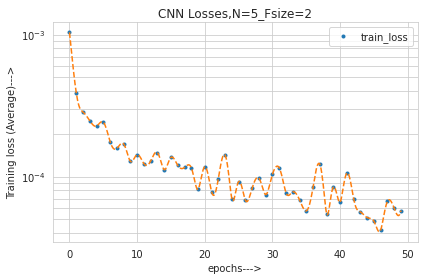

In [15]:
# plotting the losees and Accuracies of train and test data for CNN network


# for key in CNN.keys():
#     # plotting the Average losses for train and test data
#     plt.figure()
#     plt.plot(train_losses_dict[key],label="train_loss")
#     plt.plot(test_losses_dict[key],label="test_loss")
#     plt.xlabel("epochs--->")
#     plt.ylabel("loss (Average)--->")
#     plt.legend()
#     plt.grid(True)
#     plt.title(f"CNN Losses,{key}")
#     plt.show()

#     # plotting the Accuracies for train and test data
#     plt.figure()
#     plt.plot(train_accuracies_dict[key],label="train_accuracy")
#     plt.plot(test_accuracies_dict[key],label="test_accuracy")
#     plt.xlabel("epochs--->")
#     plt.ylabel("accuracy --->")
#     plt.ylim([0,110])
#     plt.legend()
#     plt.grid(True)
#     plt.title(f"CNN accuracies,{key}")
#     plt.show()
    

for key in CNN.keys():
    # plotting the Average losses for train only (for paper)
    epochs_arrayCNN=np.arange(0,args.epochs)
    Loss_CNN=train_losses_dict[key]
    plt.figure()
    plt.semilogy(epochs_arrayCNN,Loss_CNN,".",label="train_loss")
    int_fnc = scipy.interpolate.make_interp_spline(epochs_arrayCNN,Loss_CNN)
    x_new = np.linspace(0,epochs_arrayCNN.shape[0]-1,(epochs_arrayCNN.shape[0]-1)*10)
    y_new = int_fnc(x_new)
    plt.plot(x_new,y_new,'--')
    plt.xlabel("epochs--->")
    plt.ylabel("Training loss (Average)--->")
#     plt.xticks(epochs_arrayCNN)
    plt.legend()
    plt.grid(True,which = "both")
    plt.title(f"CNN Losses,{key}")
    figure_file_name = f"CNN,{key},losses.jpg"
    figure_file_path = os.path.join("Generated_plots","accuracies_and_losses",figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"epochs":list(range(0,args.epochs)), "CNN_train_losses":list(Loss_CNN)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

Traning the Fully connected models with only one hidden Layer

In [16]:
%%time
# Traing the Fully connected Networks with one hidden layer
import torch.nn.functional as F # implements forward and backward definitions of an autograd operation
import torch.optim as optim # different update rules such as SGD, Nesterov-SGD, Adam, RMSProp, etc

# load data
# train_loader, critical_loader=load_data_for_training_with_critcal_dataset(cuda_kwargs)
## Use following for trainin on non-critical data only
train_loader, critical_loader=load_data_for_training_without_critcal_dataset(cuda_kwargs)


final_test_accuracies_dict = {}

train_losses_dict = {}
test_losses_dict = {}
train_accuracies_dict = {}
test_accuracies_dict = {}


# create array of depth of convolutional layer
N_array=[100,200,300,400,500]
N_array = [100]
FCN_2 = {}
# loop over depths
for N in N_array:
    FCN_2[f"N1={N}"] = FCN_2_layer_model(N1=N)
    if args.cuda:
        FCN_2[f"N1={N}"].cuda()

    train_losses_dict[f"N1={N}"] = []
    test_losses_dict[f"N1={N}"] = []
    train_accuracies_dict[f"N1={N}"] = []
    test_accuracies_dict[f"N1={N}"] = []


    # negative log-likelihood (nll) loss for training: takes class labels NOT one-hot vectors!
    train_criterion = nn.NLLLoss(reduction='mean')
    test_criterion = nn.NLLLoss(reduction="mean")
    # define SGD optimizer
    optimizer = optim.SGD(FCN_2[f"N1={N}"].parameters(), lr=args.lr, momentum=args.momentum)
    #optimizer = optim.Adam(FCN_2[f"N1={N}"].parameters(), lr=args.lr, betas=(0.9, 0.999))

    # train the FCN_2_layer_model and test its performance at each epoch
    for epoch in trange(1, args.epochs + 1):
        train_loss,train_accuracy = train(epoch, FCN_2[f"N1={N}"], train_loader,criterion=train_criterion)
        train_losses_dict[f"N1={N}"].append(train_loss)
        train_accuracies_dict[f"N1={N}"].append(train_accuracy)


        test_loss,test_accuracy = test(critical_loader,FCN_2[f"N1={N}"], verbose='Critical',criterion=test_criterion)
        if epoch==args.epochs:
            final_test_accuracies_dict[f"N1={N}"] = test_accuracy
        else:
            test_losses_dict[f"N1={N}"].append(test_loss)
            test_accuracies_dict[f"N1={N}"].append(test_accuracy)

        
print("train_losses_dict -->",train_losses_dict)
print("test_losses_dict -->",test_losses_dict)
print("train_accuracies_dict -->",train_accuracies_dict)
print("test_accuracies_dict -->",test_accuracies_dict)



# To save memory
del train_loader, critical_loader

Training datasets: ordered_partial and disordered_partial data set


/opt/conda/lib/python3.7/site-packages/torch/utils/data/dataloader.py:481: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))


Critical Data set
This is a 2 layer network  with 100-neurons in the hidden layer


  0%|          | 0/50 [00:00<?, ?it/s]

Train Epoch: 1 [0/440000 (0%)]	Loss: 0.729195
Train Epoch: 1 [32000/440000 (7%)]	Loss: 0.016908
Train Epoch: 1 [64000/440000 (15%)]	Loss: 0.008036
Train Epoch: 1 [96000/440000 (22%)]	Loss: 0.008933
Train Epoch: 1 [128000/440000 (29%)]	Loss: 0.002460
Train Epoch: 1 [160000/440000 (36%)]	Loss: 0.002540
Train Epoch: 1 [192000/440000 (44%)]	Loss: 0.002037
Train Epoch: 1 [224000/440000 (51%)]	Loss: 0.001128
Train Epoch: 1 [256000/440000 (58%)]	Loss: 0.001887
Train Epoch: 1 [288000/440000 (65%)]	Loss: 0.002714
Train Epoch: 1 [320000/440000 (73%)]	Loss: 0.006397
Train Epoch: 1 [352000/440000 (80%)]	Loss: 0.001350
Train Epoch: 1 [384000/440000 (87%)]	Loss: 0.004065
Train Epoch: 1 [416000/440000 (95%)]	Loss: 0.001870

Critical set: Average loss: 0.4032, Accuracy: 150262/170000 (88%)

Train Epoch: 2 [0/440000 (0%)]	Loss: 0.000847
Train Epoch: 2 [32000/440000 (7%)]	Loss: 0.000666
Train Epoch: 2 [64000/440000 (15%)]	Loss: 0.000827
Train Epoch: 2 [96000/440000 (22%)]	Loss: 0.000659
Train Epoch: 2 [

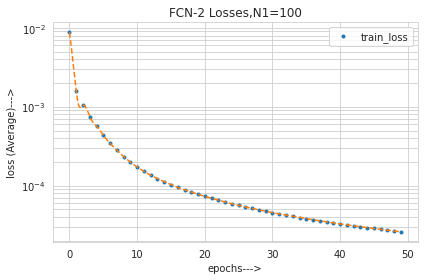

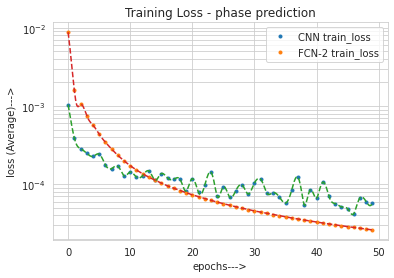

In [17]:
for key in FCN_2.keys():
    # plotting the Average losses for train only (for paper)
    epochs_arrayDNNsh=np.arange(0,args.epochs)
    Loss_DNNsh=train_losses_dict[key]
    plt.figure()
    plt.semilogy(epochs_arrayDNNsh,Loss_DNNsh,".",label="train_loss")
    int_fnc = scipy.interpolate.make_interp_spline(epochs_arrayDNNsh,Loss_DNNsh)
    x_new = np.linspace(0,epochs_arrayDNNsh.shape[0]-1,(epochs_arrayDNNsh.shape[0]-1)*10)
    y_new = int_fnc(x_new)
    plt.plot(x_new,y_new,'--')
    plt.xlabel("epochs--->")
    plt.ylabel("loss (Average)--->")
#     plt.xticks(epochs_arrayDNNsh)
    plt.legend()
    plt.grid(True, which = "both")
    plt.title(f"FCN-2 Losses,{key}")
    figure_file_name = f"FCN_2,{key},losses.jpg"
    figure_file_path = os.path.join("Generated_plots","accuracies_and_losses",figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"epochs":list(range(0,args.epochs)), "DNNsh_train_losses":list(Loss_DNNsh)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)
    

    
plt.figure()
plt.semilogy(epochs_arrayCNN,Loss_CNN,".",label="CNN train_loss")
plt.semilogy(epochs_arrayDNNsh,Loss_DNNsh,".",label="FCN-2 train_loss")
int_fnc_CNN = scipy.interpolate.make_interp_spline(epochs_arrayCNN,Loss_CNN)
int_fnc_DNNsh = scipy.interpolate.make_interp_spline(epochs_arrayDNNsh,Loss_DNNsh)
x_new_CNN = np.linspace(0,epochs_arrayCNN.shape[0]-1,(epochs_arrayCNN.shape[0]-1)*10)
y_new_CNN = int_fnc_CNN(x_new_CNN)
x_new_DNNsh = np.linspace(0,epochs_arrayDNNsh.shape[0]-1,(epochs_arrayDNNsh.shape[0]-1)*10)
y_new_DNNsh = int_fnc_DNNsh(x_new_DNNsh)
plt.plot(x_new_CNN,y_new_CNN,'--')
plt.plot(x_new_DNNsh,y_new_DNNsh,'--')
plt.xlabel("epochs--->")
plt.ylabel("loss (Average)--->")
# plt.xticks(epochs_arrayCNN)
plt.legend()
plt.grid(True, which="both")
plt.title("Training Loss - phase prediction")
plt.show()

Training Fully connected layers with 3 Hidden Layers

In [18]:
%%time
# Traing the Fully connected Networks with 4 hidden layers
import torch.nn.functional as F # implements forward and backward definitions of an autograd operation
import torch.optim as optim # different update rules such as SGD, Nesterov-SGD, Adam, RMSProp, etc

# load data
# train_loader, critical_loader=load_data_for_training_with_critcal_dataset(cuda_kwargs)
## Use following for trainin on non-critical data only
train_loader, critical_loader=load_data_for_training_without_critcal_dataset(cuda_kwargs)

final_test_accuracies_dict = {}

train_losses_dict = {}
test_losses_dict = {}
train_accuracies_dict = {}
test_accuracies_dict = {}

# create array of depth of convolutional layer
N_array=[100,200,300,400,500]
N_array = [100]
FCN_4 = {}
# loop over depths
for N in N_array:
    FCN_4[f"N1={N}_N2={N}_N3={N}"] = FCN_4_layer_model(N1=N,N2=N,N3=N)
    if args.cuda:
        FCN_4[f"N1={N}_N2={N}_N3={N}"].cuda()

    train_losses_dict[f"N1={N}_N2={N}_N3={N}"] = []
    test_losses_dict[f"N1={N}_N2={N}_N3={N}"] = []
    train_accuracies_dict[f"N1={N}_N2={N}_N3={N}"] = []
    test_accuracies_dict[f"N1={N}_N2={N}_N3={N}"] = []

    # negative log-likelihood (nll) loss for training: takes class labels NOT one-hot vectors!
    train_criterion = nn.NLLLoss(reduction='mean')
    test_criterion = nn.NLLLoss(reduction="mean")
    # define SGD optimizer
    optimizer = optim.SGD(FCN_4[f"N1={N}_N2={N}_N3={N}"].parameters(), lr=args.lr, momentum=args.momentum)
    #optimizer = optim.Adam(FCN_4[f"N1={N}_N2={N}_N3={N}"].parameters(), lr=args.lr, betas=(0.9, 0.999))

    # train the FCN_4[f"N1={N}_N2={N}_N3={N}"]_layer_model and test its performance at each epoch
    for epoch in trange(1, args.epochs + 1):
        train_loss,train_accuracy = train(epoch, FCN_4[f"N1={N}_N2={N}_N3={N}"], train_loader,criterion=train_criterion)
        train_losses_dict[f"N1={N}_N2={N}_N3={N}"].append(train_loss)
        train_accuracies_dict[f"N1={N}_N2={N}_N3={N}"].append(train_accuracy)

        test_loss,test_accuracy = test(critical_loader, FCN_4[f"N1={N}_N2={N}_N3={N}"], verbose='Critical',criterion=test_criterion)
        if epoch==args.epochs:
            final_test_accuracies_dict[f"N1={N}_N2={N}_N3={N}"] = test_accuracy
        else:
            test_losses_dict[f"N1={N}_N2={N}_N3={N}"].append(test_loss)
            test_accuracies_dict[f"N1={N}_N2={N}_N3={N}"].append(test_accuracy)
    
print("train_losses_dict -->",train_losses_dict)
print("test_losses_dict -->",test_losses_dict)
print("train_accuracies_dict -->",train_accuracies_dict)
print("test_accuracies_dict -->",test_accuracies_dict)


          
# To save memory
del train_loader, critical_loader

Training datasets: ordered_partial and disordered_partial data set


/opt/conda/lib/python3.7/site-packages/torch/utils/data/dataloader.py:481: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))


Critical Data set
This is a 4 layer network  with 100,100,100-neurons in the hidden layers


  0%|          | 0/50 [00:00<?, ?it/s]

Train Epoch: 1 [0/440000 (0%)]	Loss: 0.703108
Train Epoch: 1 [32000/440000 (7%)]	Loss: 0.016172
Train Epoch: 1 [64000/440000 (15%)]	Loss: 0.003456
Train Epoch: 1 [96000/440000 (22%)]	Loss: 0.001658
Train Epoch: 1 [128000/440000 (29%)]	Loss: 0.002021
Train Epoch: 1 [160000/440000 (36%)]	Loss: 0.000486
Train Epoch: 1 [192000/440000 (44%)]	Loss: 0.000684
Train Epoch: 1 [224000/440000 (51%)]	Loss: 0.000421
Train Epoch: 1 [256000/440000 (58%)]	Loss: 0.000295
Train Epoch: 1 [288000/440000 (65%)]	Loss: 0.000468
Train Epoch: 1 [320000/440000 (73%)]	Loss: 0.000941
Train Epoch: 1 [352000/440000 (80%)]	Loss: 0.001510
Train Epoch: 1 [384000/440000 (87%)]	Loss: 0.000349
Train Epoch: 1 [416000/440000 (95%)]	Loss: 0.001057

Critical set: Average loss: 0.4520, Accuracy: 150313/170000 (88%)

Train Epoch: 2 [0/440000 (0%)]	Loss: 0.000245
Train Epoch: 2 [32000/440000 (7%)]	Loss: 0.000310
Train Epoch: 2 [64000/440000 (15%)]	Loss: 0.000121
Train Epoch: 2 [96000/440000 (22%)]	Loss: 0.000107
Train Epoch: 2 [

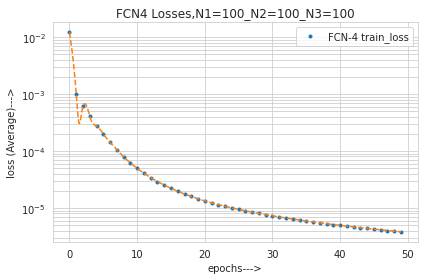

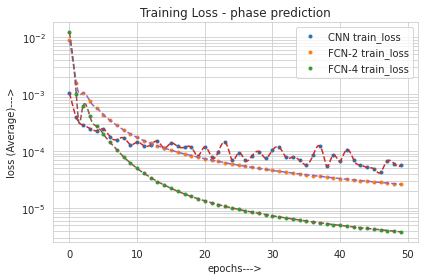

In [19]:
for key in FCN_4.keys():
    # plotting the Average losses for train only (for paper)
    epochs_arrayDNNdp=np.arange(0,args.epochs)
    Loss_DNNdp=train_losses_dict[key]
    plt.figure()
    plt.semilogy(epochs_arrayDNNdp,Loss_DNNdp,".",label="FCN-4 train_loss")
    int_fnc = scipy.interpolate.make_interp_spline(epochs_arrayDNNdp,Loss_DNNdp)
    x_new = np.linspace(0,epochs_arrayDNNdp.shape[0]-1,(epochs_arrayDNNdp.shape[0]-1)*10)
    y_new = int_fnc(x_new)
    plt.plot(x_new,y_new,'--')
    plt.xlabel("epochs--->")
    plt.ylabel("loss (Average)--->")
#     plt.xticks(epochs_arrayDNNdp)
    plt.legend()
    plt.grid(True, which = "both")
    plt.title(f"FCN4 Losses,{key}")
    figure_file_name = f"FCN_4,{key},losses.jpg"
    figure_file_path = os.path.join("Generated_plots","accuracies_and_losses",figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"epochs":list(range(0,args.epochs)), "DNNdp_train_losses":list(Loss_DNNdp)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)
    
plt.figure()
plt.semilogy(epochs_arrayCNN,Loss_CNN,".",label="CNN train_loss")
plt.semilogy(epochs_arrayDNNsh,Loss_DNNsh,".",label="FCN-2 train_loss")
plt.semilogy(epochs_arrayDNNdp,Loss_DNNdp,".",label="FCN-4 train_loss")
int_fnc_CNN = scipy.interpolate.make_interp_spline(epochs_arrayCNN,Loss_CNN)
int_fnc_DNNsh = scipy.interpolate.make_interp_spline(epochs_arrayDNNsh,Loss_DNNsh)
int_fnc_DNNdp = scipy.interpolate.make_interp_spline(epochs_arrayDNNdp,Loss_DNNdp)
x_new_CNN = np.linspace(0,epochs_arrayCNN.shape[0]-1,(epochs_arrayCNN.shape[0]-1)*10)
y_new_CNN = int_fnc_CNN(x_new_CNN)
x_new_DNNsh = np.linspace(0,epochs_arrayDNNsh.shape[0]-1,(epochs_arrayDNNsh.shape[0]-1)*10)
y_new_DNNsh = int_fnc_DNNsh(x_new_DNNsh)
x_new_DNNdp = np.linspace(0,epochs_arrayDNNdp.shape[0]-1,(epochs_arrayDNNdp.shape[0]-1)*10)
y_new_DNNdp = int_fnc_DNNdp(x_new_DNNdp)
plt.plot(x_new_CNN,y_new_CNN,'--')
plt.plot(x_new_DNNsh,y_new_DNNsh,'--')
plt.plot(x_new_DNNdp,y_new_DNNdp,'--')
plt.xlabel("epochs--->")
plt.ylabel("loss (Average)--->")
# plt.xticks(epochs_arrayCNN)
plt.legend()
plt.grid(True, which = "both")
plt.title("Training Loss - phase prediction")
figure_file_name = f"All_model_losses.jpg"
figure_file_path = os.path.join("Generated_plots","accuracies_and_losses",figure_file_name)
plt.tight_layout()
plt.savefig(figure_file_path)
# plt.show()
# Storing the the data related to the plot
df_dict = {"epochs":list(range(0,args.epochs)), "CNN_train_losses":list(Loss_CNN), "DNNsh_train_losses":list(Loss_DNNsh), "DNNdp_train_losses":list(Loss_DNNdp)}
df = pd.DataFrame(df_dict)
figure_data_file_path = figure_file_path[0:-4] + ".csv"
df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

Saving the models

In [20]:
%%time
import torch
import pickle
import os
# print()

folder_name_for_models_trained_Full_data = f"Models_trained_on_Full_data"
if not os.path.isdir(folder_name_for_models_trained_Full_data):
    os.mkdir(folder_name_for_models_trained_Full_data)

for key in FCN_2.keys():
    model_file_name = key + ".pth"
    model_file_path = os.path.join(
        folder_name_for_models_trained_Full_data, model_file_name)
    torch.save(FCN_2[key], model_file_path)

for key in FCN_4.keys():
    model_file_name = key + ".pth"
    model_file_path = os.path.join(
        folder_name_for_models_trained_Full_data, model_file_name)
    torch.save(FCN_4[key], model_file_path)

for key in CNN.keys():
    model_file_name = key + ".pth"
    model_file_path = os.path.join(
        folder_name_for_models_trained_Full_data, model_file_name)
    torch.save(CNN[key], model_file_path)


CPU times: user 6.02 ms, sys: 1.72 ms, total: 7.74 ms
Wall time: 13.2 ms


## Testing J=1.0, G=0.0 data

In [21]:
class Testing_dataset_g_0(torch.utils.data.Dataset):
    """Ising pytorch Testing dataset for G = 0.0"""

    def __init__(self, data_type, transform=False):
        """
        Args:
            data_type (string): `ordered`, `disordered` : creates data_loader
            transform (callable, optional): Optional transform to be applied on a sample.

        """

        # from sklearn.model_selection import train_test_split
        # import collections
        import pickle
        G_0_pkl_data_folder_path = "./G_0_data_in_pkl_format"

        X_ordered_file_name = "X_ordered_complete.pkl"
        X_ordered_file_path = os.path.join(G_0_pkl_data_folder_path, X_ordered_file_name)
        Y_ordered_file_name = "Y_ordered_complete.pkl"
        Y_ordered_file_path = os.path.join(G_0_pkl_data_folder_path, Y_ordered_file_name)
        X_disordered_file_name = "X_disordered_complete.pkl"
        X_disordered_file_path = os.path.join(G_0_pkl_data_folder_path, X_disordered_file_name)
        Y_disordered_file_name = "Y_disordered_complete.pkl"
        Y_disordered_file_path = os.path.join(G_0_pkl_data_folder_path, Y_disordered_file_name)

        with open(X_ordered_file_path, 'rb') as f:
            X_ordered = pickle.load(f)
        with open(Y_ordered_file_path, 'rb') as f:
            Y_ordered = pickle.load(f)
            Y_ordered = np.int64(Y_ordered)
        with open(X_disordered_file_path, 'rb') as f:
            X_disordered = pickle.load(f)
        with open(Y_disordered_file_path, 'rb') as f:
            Y_disordered = pickle.load(f)
            Y_disordered = np.int64(Y_disordered)

        if data_type == 'ordered':
            X = X_ordered
            Y = Y_ordered

        if data_type == 'disordered':
            X = X_disordered
            Y = Y_disordered

        # these are necessary attributes in dataset class and must be assigned
        self.data = (X, Y)
        self.transform = transform

    # override __len__ and __getitem__ of the Dataset() class

    def __len__(self):
        return len(self.data[1])

    def __getitem__(self, idx):

        sample = (self.data[0][idx, ...], self.data[1][idx])
        if self.transform:
            sample = self.transform(sample)

        return sample


def load_testing_dataset_g_0(kwargs, transform= False):
    # kwargs:  CUDA arguments, if enabled
    # load and noralise train,test, and data
    
    ordered_loader = torch.utils.data.DataLoader(
        Testing_dataset_g_0(data_type='ordered', transform= transform),
        batch_size=args.test_batch_size, shuffle=False,**kwargs)
    disordered_loader = torch.utils.data.DataLoader(
        Testing_dataset_g_0(data_type='disordered', transform= transform),
        batch_size=args.test_batch_size, shuffle=False,**kwargs)

    return ordered_loader, disordered_loader

In [22]:
%%time
ordered_loader, disordered_loader = load_testing_dataset_g_0(cuda_kwargs)

ordered_accuracies_dict = {}
disordered_accuracies_dict = {}

test_criterion = nn.NLLLoss(reduction="mean")


for key in FCN_2.keys():
    print(f"Acuracies of model FCN_2 key={key}")
    testing_model = FCN_2[key]

    if args.cuda:
        testing_model.cuda()
    _, ordered_accuracies_dict["FCN_2_"+key+"_ordered"] = test(ordered_loader, testing_model, verbose='ordered',criterion=test_criterion)
    _, disordered_accuracies_dict["FCN_2_"+key+"_disordered"] = test(disordered_loader, testing_model, verbose='disordered',criterion=test_criterion)

for key in FCN_4.keys():
    print(f"Acuracies of model FCN_4 key={key}")
    testing_model = FCN_4[key]

    if args.cuda:
        testing_model.cuda()
    _, ordered_accuracies_dict["FCN_4_"+key+"_ordered"] = test(ordered_loader, testing_model, verbose='ordered',criterion=test_criterion)
    _, disordered_accuracies_dict["FCN_4_"+key+"_disordered"] = test(disordered_loader, testing_model, verbose='disordered',criterion=test_criterion)

for key in CNN.keys():
    print(f"Acuracies of model CNN key={key}")
    testing_model = CNN[key]

    if args.cuda:
        testing_model.cuda()
    _, ordered_accuracies_dict["CNN_"+key+"_ordered"] = test(ordered_loader, testing_model, verbose='ordered',criterion=test_criterion)
    _, disordered_accuracies_dict["CNN_"+key+"_disordered"] = test(disordered_loader, testing_model, verbose='disordered',criterion=test_criterion)

for pair in ordered_accuracies_dict.items():
    print(pair)
for pair in disordered_accuracies_dict.items():
    print(pair)
    
# print(f"ordered_accuracies_dict = {ordered_accuracies_dict}")
# print(f"disordered_accuracies_dict = {disordered_accuracies_dict}")
          
# To save memory
del ordered_loader, disordered_loader

/opt/conda/lib/python3.7/site-packages/torch/utils/data/dataloader.py:481: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))


Acuracies of model FCN_2 key=N1=100

ordered set: Average loss: 0.1774, Accuracy: 224057/230000 (97%)


disordered set: Average loss: 0.1917, Accuracy: 366006/380000 (96%)

Acuracies of model FCN_4 key=N1=100_N2=100_N3=100

ordered set: Average loss: 0.2209, Accuracy: 224438/230000 (98%)


disordered set: Average loss: 0.2884, Accuracy: 364715/380000 (96%)

Acuracies of model CNN key=N=5_Fsize=2

ordered set: Average loss: 0.0211, Accuracy: 228506/230000 (99%)


disordered set: Average loss: 0.3173, Accuracy: 358270/380000 (94%)

('FCN_2_N1=100_ordered', 97.41608695652174)
('FCN_4_N1=100_N2=100_N3=100_ordered', 97.58173913043478)
('CNN_N=5_Fsize=2_ordered', 99.3504347826087)
('FCN_2_N1=100_disordered', 96.31736842105263)
('FCN_4_N1=100_N2=100_N3=100_disordered', 95.97763157894737)
('CNN_N=5_Fsize=2_disordered', 94.28157894736842)
CPU times: user 3.21 s, sys: 6.91 s, total: 10.1 s
Wall time: 23.1 s


## Calculating the accuracies for Critical and non critical Datasets for J=1.0, G=0.0

In [23]:
class Testing_dataset_g_0_ver2(torch.utils.data.Dataset):
    """Ising pytorch Testing dataset for G = 0.0"""

    def __init__(self, data_type, transform=False):
        """
        Args:
            data_type (string): f"T_{T:.6f}", Where T is one of the possible Temperatures
            transform (callable, optional): Optional transform to be applied on a sample.

        """

        # from sklearn.model_selection import train_test_split
        # import collections
        import pickle
        G_0_pkl_data_folder_path = "./G_0_data_in_pkl_format"
        important_parameters_file_name = "important_parameters.pkl"
        important_parameters_file_path = os.path.join(
            G_0_pkl_data_folder_path, important_parameters_file_name)
        with open(important_parameters_file_path, 'rb') as f:
            important_parameters_dict = pickle.load(f)

        T_critical = important_parameters_dict["T_critical"]
        T_low_for_critical = important_parameters_dict["T_low_for_critical"]  
        T_up_for_critical = important_parameters_dict["T_up_for_critical"]  

        data_file_names_list = []
        for file_name in os.listdir(G_0_pkl_data_folder_path):
            if file_name.endswith('.pkl'):
                if file_name.startswith('configerations_'):
                    data_file_names_list.append(file_name)

        X_dict = {}
        Y_dict = {}
        for data_file_name in data_file_names_list:
            T = np.float(data_file_name.split("_")[8])
            data_file_path = os.path.join(
                G_0_pkl_data_folder_path, data_file_name)
            with open(data_file_path, 'rb') as f:
                configerations = pickle.load(f)
            X_dict[f"T_{T:.6f}"] = configerations
            if T < T_critical:
                Y_dict[f"T_{T:.6f}"] = np.ones(configerations.shape[0])
                Y_dict[f"T_{T:.6f}"] = np.int64(Y_dict[f"T_{T:.6f}"])
            else:
                Y_dict[f"T_{T:.6f}"] = np.zeros(configerations.shape[0])
                Y_dict[f"T_{T:.6f}"] = np.int64(Y_dict[f"T_{T:.6f}"])

        X = X_dict[data_type]
        Y = Y_dict[data_type]

        # these are necessary attributes in dataset class and must be assigned
        self.data = (X, Y)
        self.transform = transform

    # override __len__ and __getitem__ of the Dataset() class

    def __len__(self):
        return len(self.data[1])

    def __getitem__(self, idx):

        sample = (self.data[0][idx, ...], self.data[1][idx])
        if self.transform:
            sample = self.transform(sample)

        return sample


def load_testing_dataset_g_0_ver2(kwargs, transform=False):
    # kwargs:  CUDA arguments, if enabled
    # load and noralise train,test, and data
    import pickle
    G_0_pkl_data_folder_path = "./G_0_data_in_pkl_format"
    important_parameters_file_name = "important_parameters.pkl"
    important_parameters_file_path = os.path.join(
        G_0_pkl_data_folder_path, important_parameters_file_name)
    with open(important_parameters_file_path, 'rb') as f:
        important_parameters_dict = pickle.load(f)
#     T_critical = important_parameters_dict["T_critical"]
    T_list = important_parameters_dict["T_list"]
#     No_configerations_for_each_T = important_parameters_dict["No_configerations_for_each_T"]

    data_loader_dict = {}
    for T in T_list:
        data_loader_dict[f"T_{T:.6f}"] = torch.utils.data.DataLoader(Testing_dataset_g_0_ver2(
            data_type=f"T_{T:.6f}", transform=transform), batch_size=args.test_batch_size, shuffle=False, **kwargs)

    return data_loader_dict


In [24]:
%%time
data_loader_dict = load_testing_dataset_g_0_ver2(cuda_kwargs)

accuracies_dict = {}

test_criterion = nn.NLLLoss(reduction="mean")

for key in FCN_2.keys():
    testing_model = FCN_2[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"FCN_2,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"FCN_2,{key},{T_key}",criterion=test_criterion)


for key in FCN_4.keys():
    testing_model = FCN_4[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"FCN_4,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"FCN_4,{key},{T_key}",criterion=test_criterion)

for key in CNN.keys():
    testing_model = CNN[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"CNN,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"CNN,{key},{T_key}",criterion=test_criterion)


for pair in accuracies_dict.items():
    print(pair)

# print(f"accuracies_dict = {accuracies_dict}")
# To save memory
del data_loader_dict


FCN_2,N1=100,T_1.000000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.100000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.200000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.300000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.400000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.500000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.600000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.700000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.800000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.900000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.000000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.025000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_

In [25]:
accuracies_folder_name = "accuracies_for_Models_trained_on_non_critical_data"

if not os.path.isdir(accuracies_folder_name):
    os.mkdir(accuracies_folder_name)

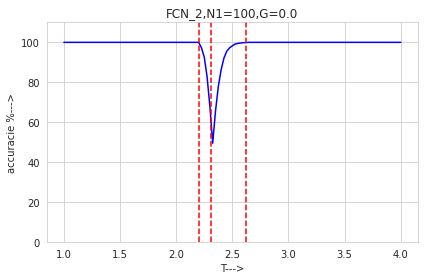

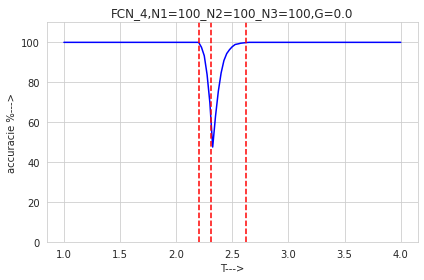

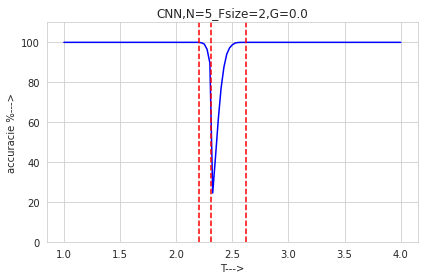

In [26]:
# Plottin all Networks accuriers  for g=0.0 data
import matplotlib.pyplot as plt
import pickle

G_0_pkl_data_folder_path = "./G_0_data_in_pkl_format"
important_parameters_file_name = "important_parameters.pkl"
important_parameters_file_path = os.path.join(G_0_pkl_data_folder_path, important_parameters_file_name)
with open(important_parameters_file_path, 'rb') as f:
    important_parameters_dict = pickle.load(f)
    T_list = important_parameters_dict["T_list"]
    T_critical = important_parameters_dict["T_critical"]
    T_low_for_critical = important_parameters_dict["T_low_for_critical"] 
    T_up_for_critical = important_parameters_dict["T_up_for_critical"]

for key in FCN_2.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"FCN_2,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"FCN_2,{key},G=0.0")
    figure_file_name = f"FCN_2,{key},G=0.0.jpg"
    figure_file_path = os.path.join(accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

for key in FCN_4.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"FCN_4,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"FCN_4,{key},G=0.0")
    figure_file_name = f"FCN_4,{key},G=0.0.jpg"
    figure_file_path = os.path.join(accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

for key in CNN.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"CNN,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"CNN,{key},G=0.0")
    figure_file_name = f"CNN,{key},G=0.0.jpg"
    figure_file_path = os.path.join(accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

In [27]:
import pandas as pd

G_0_pkl_data_folder_path = "./G_0_data_in_pkl_format"
important_parameters_file_name = "important_parameters.pkl"
important_parameters_file_path = os.path.join(G_0_pkl_data_folder_path, important_parameters_file_name)
with open(important_parameters_file_path, 'rb') as f:
    important_parameters_dict = pickle.load(f)
    T_list = important_parameters_dict["T_list"]
    T_critical = important_parameters_dict["T_critical"]
    T_low_for_critical = important_parameters_dict["T_low_for_critical"] 
    T_up_for_critical = important_parameters_dict["T_up_for_critical"]
    
    
    
critical_accuracies_dict = {}
non_critical_accuracies_dict = {}


accuracies_file_names_list = []
for file_name in os.listdir(accuracies_folder_name):
    if file_name.endswith('.csv'):
        if file_name.find("G=0.0")>=0:
            accuracies_file_names_list.append(file_name)


for accuracy_file_name in accuracies_file_names_list:
    accuracy_file_path = os.path.join(accuracies_folder_name, accuracy_file_name)
    df_all = pd.read_csv(accuracy_file_path, header=0)
    filt = (df_all['T_list'] >= T_low_for_critical) & (df_all['T_list'] <= T_up_for_critical)
    df_critical = df_all[filt]
    df_non_critical = df_all[~filt]
    critical_accuracies_dict[accuracy_file_name[0:-4]] = df_critical["accuracies"].mean()
    non_critical_accuracies_dict[accuracy_file_name[0:-4]] = df_non_critical["accuracies"].mean()

for pair in critical_accuracies_dict.items():
    print("critical accuracy -->",pair)
    
for pair in non_critical_accuracies_dict.items():
    print("non critical accuracy -->",pair)

critical accuracy --> ('CNN,N=5_Fsize=2,G=0.0', 86.33882352941178)
critical accuracy --> ('FCN_2,N1=100,G=0.0', 88.27235294117648)
critical accuracy --> ('FCN_4,N1=100_N2=100_N3=100,G=0.0', 87.73705882352942)
non critical accuracy --> ('CNN,N=5_Fsize=2,G=0.0', 100.0)
non critical accuracy --> ('FCN_2,N1=100,G=0.0', 100.0)
non critical accuracy --> ('FCN_4,N1=100_N2=100_N3=100,G=0.0', 100.0)


In [28]:
Phase_accuracies_df.loc["J=1.0,G=0.0,Critical", "1_layer_DNN"] = critical_accuracies_dict["FCN_2,N1=100,G=0.0"]
Phase_accuracies_df.loc["J=1.0,G=0.0,Critical", "3_layer_DNN"] = critical_accuracies_dict["FCN_4,N1=100_N2=100_N3=100,G=0.0"]
Phase_accuracies_df.loc["J=1.0,G=0.0,Critical", "CNN"] = critical_accuracies_dict["CNN,N=5_Fsize=2,G=0.0"]
Phase_accuracies_df.loc["J=1.0,G=0.0,Non-Critical", "1_layer_DNN"] = non_critical_accuracies_dict["FCN_2,N1=100,G=0.0"]
Phase_accuracies_df.loc["J=1.0,G=0.0,Non-Critical", "3_layer_DNN"] = non_critical_accuracies_dict["FCN_4,N1=100_N2=100_N3=100,G=0.0"]
Phase_accuracies_df.loc["J=1.0,G=0.0,Non-Critical", "CNN"] = non_critical_accuracies_dict["CNN,N=5_Fsize=2,G=0.0"]
Phase_accuracies_df

,Temperature Range,T_c,1_layer_DNN,3_layer_DNN,CNN,1_layer_DNN_FFT,3_layer_DNN_FFT,CNN_FFT
"J=1.0,G=0.0,Critical","[1.000 ,4.000]","[2.325 ,2.350]",88.272353,87.737059,86.338824,NaN,NaN,NaN
"J=1.0,G=0.0,Non-Critical","[1.000 ,4.000]","[2.325 ,2.350]",100.0,100.0,100.0,NaN,NaN,NaN
"J=1.0,G=0.1,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.1,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.5,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.5,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=0.0,G=1.0,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=0.0,G=1.0,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=1.0,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=1.0,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Testing the accuracies of all the models  for ordered and disordered datasets of J=1.0 ,G=0.1

### Loading the G=0.1 data

In [29]:
%%time
# G = 0.1 data
# Converting the Raw data with G=0.1 into the data type I need (.pkl files)
 
# Copied mostly from my Data_read_folder_specific.py file with necessory changes  
# -----------------------------------------------------------------------------------
# Parameters
L = 40
T_array = f5_Gp1['Ts'][:]
G = 0.1
J = 1.0

# folder name for saving the G=0.1 data in .pkl format
G_0_1_pkl_folder_path = f"G_0.1_data_in_pkl_format"
if not os.path.isdir(G_0_1_pkl_folder_path):
    os.mkdir(G_0_1_pkl_folder_path)

No_configerations_for_each_T = 10000 
for i in trange(T_array.shape[0]):
    T = T_array[i]
    data = f5_Gp1['arrs'][i,:,:].reshape(-1, L, L).astype("int8") 
    
    
    data_output_file_name = f"configerations_L_{L}_G_{G:.2f}_J_{J:.2f}_T_{T:.6f}_.pkl"
    # print(data_output_file_name)
    path = os.path.join(G_0_1_pkl_folder_path, data_output_file_name)
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    
# -----------------------------------------------------------------------------------
# To save space
del data

  0%|          | 0/61 [00:00<?, ?it/s]

CPU times: user 7.13 s, sys: 801 ms, total: 7.94 s
Wall time: 11.1 s


2.6375


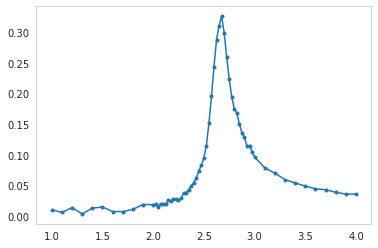

,Temperature Range,T_c,1_layer_DNN,3_layer_DNN,CNN,1_layer_DNN_FFT,3_layer_DNN_FFT,CNN_FFT
"J=1.0,G=0.0,Critical","[1.000 ,4.000]","[2.325 ,2.350]",88.272353,87.737059,86.338824,NaN,NaN,NaN
"J=1.0,G=0.0,Non-Critical","[1.000 ,4.000]","[2.325 ,2.350]",100.0,100.0,100.0,NaN,NaN,NaN
"J=1.0,G=0.1,Critical","[1.000 ,4.000]","[2.675 ,2.650]",NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.1,Non-Critical","[1.000 ,4.000]","[2.675 ,2.650]",NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.5,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.5,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=0.0,G=1.0,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=0.0,G=1.0,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=1.0,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=1.0,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
#---------------------------------------
#Critical Region: 
#---------------------------------------
Targs=np.arange(61)
xiBs=f5_Gp1['xiBs'][:]
factor=0.30 # Parameter which determines critical region
cut=np.amax(xiBs)*factor
labels_tmp=np.heaviside(xiBs[Targs]-cut,1.0)
crit_start=np.where(labels_tmp==1.0)[0][0]
crit_end=np.where(labels_tmp==1.0)[0][-1]

######Tc from chi###########
#crit_Temp=(T_array[xiBs.argsort()[-1]]+T_array[xiBs.argsort()[-2]])/2
crit_Temp=2.6375
###########

#print(T_array[crit_start])
#print(T_array[crit_end])
#print(T_array[crit_pt])
#print(xiBs.argsort()[-1])
print(crit_Temp)
#---------------------------------------

plt.figure()
plt.plot(T_array,xiBs,".-")
plt.grid()
plt.show()


# --------------------------------------
Phase_accuracies_df.loc["J=1.0,G=0.1,Critical", "Temperature Range"] = f"[{T_array[0]:.3f} ,{T_array[-1]:.3f}]"
Phase_accuracies_df.loc["J=1.0,G=0.1,Non-Critical", "Temperature Range"] = f"[{T_array[0]:.3f} ,{T_array[-1]:.3f}]"
Phase_accuracies_df.loc["J=1.0,G=0.1,Critical", "T_c"] = f"[{T_array[xiBs.argsort()[-1]]:.3f} ,{T_array[xiBs.argsort()[-2]]:.3f}]"
Phase_accuracies_df.loc["J=1.0,G=0.1,Non-Critical", "T_c"] = f"[{T_array[xiBs.argsort()[-1]]:.3f} ,{T_array[xiBs.argsort()[-2]]:.3f}]"
Phase_accuracies_df

In [31]:
%%time
# Creating ordered_partial,disordered_partial,ordered_complete,disordered_complete,critical data .pkl files for G=0.1

No_configerations_for_each_T = 10000 
# Copied mostly from my Analyze_folder_specific.py file with necessory changes  
# -----------------------------------------------------------------------------------
# Parameters that need to be set manually --------------------------------------------------------------<
J = 1.0
G = 0.1
T_critical = crit_Temp # From Chi values
T_low_for_critical = T_array[crit_start] # From XiB values
T_up_for_critical = T_array[crit_end] # From XiB values
print("J = ", J)
print("G = ", G)
print("T_critical = ", T_critical)
print("T_low_for_critical = ", T_low_for_critical)
print("T_up_for_critical = ", T_up_for_critical)
# ------------------------------------------------------------------------------------------------------>

# Saving all the file names into a dictionary called data file name
G_0_1_pkl_folder_path = f"./G_0.1_data_in_pkl_format"
data_file_names_list = []
for file_name in os.listdir(G_0_1_pkl_folder_path):
    if file_name.endswith('.pkl'):
        if file_name.startswith("configerations_"):
            data_file_names_list.append(file_name)

            
# Storing the data into ordered,disordered and critical data sets --------------------------------------<
# Here I have add "X_ordered_partial" and "X_disordered_partial" data sets contains ordered
# and disordered datasets respectively which are not a part of critical dataset
X_ordered_partial = []
X_disordered_partial = []
Y_ordered_partial = []
Y_disordered_partial = []
X_critical = []
Y_critical = []
T_list = []
for configerations_file_name in data_file_names_list:
    configerations_file_path = os.path.join(G_0_1_pkl_folder_path,configerations_file_name)
    T = float(configerations_file_name.split("_")[8])
    T_list.append(T)
    with open(configerations_file_path, 'rb') as f:
        configerations = pickle.load(f)

    if T < T_low_for_critical:
        X_ordered_partial.append(configerations)
        Y_ordered_partial.append(np.ones(configerations.shape[0]))
    elif T > T_up_for_critical:
        X_disordered_partial.append(configerations)
        Y_disordered_partial.append(np.zeros(configerations.shape[0]))

    elif (T <= T_up_for_critical) and (T >= T_low_for_critical):
        X_critical.append(configerations)
        if T < T_critical:
            Y_critical.append(np.ones(configerations.shape[0]))
        else:
            Y_critical.append(np.zeros(configerations.shape[0]))


X_ordered_partial = np.concatenate(tuple(X_ordered_partial), axis=0)
Y_ordered_partial = np.concatenate(tuple(Y_ordered_partial), axis=0)
X_disordered_partial = np.concatenate(tuple(X_disordered_partial), axis=0)
Y_disordered_partial = np.concatenate(tuple(Y_disordered_partial), axis=0)
X_critical = np.concatenate(tuple(X_critical), axis=0)
Y_critical = np.concatenate(tuple(Y_critical), axis=0)

# Printing shapes of X and unique values of Y Just to checck every thing is fine
# print("X_ordered_partial shape = ", X_ordered_partial.shape)
# print("X_disordered_partial shape = ", X_disordered_partial.shape)
# print("X_critical shape = ", X_critical.shape)
# print("Y_ordered_partial unique values ", np.unique(
#     Y_ordered_partial, return_counts=True))
# print("Y_disordered_partial unique values ", np.unique(
#     Y_disordered_partial, return_counts=True))
# print("Y_critical unique values ", np.unique(Y_critical, return_counts=True))

X_ordered_partial_file_name = "X_ordered_partial.pkl"
X_ordered_partial_file_path = os.path.join(G_0_1_pkl_folder_path,X_ordered_partial_file_name)
X_disordered_partial_file_name = "X_disordered_partial.pkl"
X_disordered_partial_file_path = os.path.join(G_0_1_pkl_folder_path,X_disordered_partial_file_name)
X_critical_file_name = "X_critical.pkl"
X_critical_file_path = os.path.join(G_0_1_pkl_folder_path,X_critical_file_name)
Y_ordered_partial_file_name = "Y_ordered_partial.pkl"
Y_ordered_partial_file_path = os.path.join(G_0_1_pkl_folder_path,Y_ordered_partial_file_name)
Y_disordered_partial_file_name = "Y_disordered_partial.pkl"
Y_disordered_partial_file_path = os.path.join(G_0_1_pkl_folder_path,Y_disordered_partial_file_name)
Y_critical_file_name = "Y_critical.pkl"
Y_critical_file_path = os.path.join(G_0_1_pkl_folder_path,Y_critical_file_name)

with open(X_ordered_partial_file_path, 'wb') as f:
    pickle.dump(X_ordered_partial, f)

with open(X_disordered_partial_file_path, 'wb') as f:
    pickle.dump(X_disordered_partial, f)

with open(X_critical_file_path, 'wb') as f:
    pickle.dump(X_critical, f)

with open(Y_ordered_partial_file_path, 'wb') as f:
    pickle.dump(Y_ordered_partial, f)

with open(Y_disordered_partial_file_path, 'wb') as f:
    pickle.dump(Y_disordered_partial, f)

with open(Y_critical_file_path, 'wb') as f:
    pickle.dump(Y_critical, f)
# ------------------------------------------------------------------------------------------------------>


# Storing the data into ordered and disordered data sets -----------------------------------------------<
# Here I have add "X_ordered_complete" and "X_disordered_complete" data sets contains ordered
# and disordered datasets respectively which are also included in critical dataset
X_ordered_complete = []
X_disordered_complete = []
Y_ordered_complete = []
Y_disordered_complete = []
for configerations_file_name in data_file_names_list:
    configerations_file_path = os.path.join(G_0_1_pkl_folder_path,configerations_file_name)
    T = float(configerations_file_name.split("_")[8])
    with open(configerations_file_path, 'rb') as f:
        configerations = pickle.load(f)

    if T < T_critical:
        X_ordered_complete.append(configerations)
        Y_ordered_complete.append(np.ones(configerations.shape[0]))
    else:
        X_disordered_complete.append(configerations)
        Y_disordered_complete.append(np.zeros(configerations.shape[0]))


X_ordered_complete = np.concatenate(tuple(X_ordered_complete), axis=0)
Y_ordered_complete = np.concatenate(tuple(Y_ordered_complete), axis=0)
X_disordered_complete = np.concatenate(tuple(X_disordered_complete), axis=0)
Y_disordered_complete = np.concatenate(tuple(Y_disordered_complete), axis=0)



# # Printing shapes of X and unique values of Y Just to checck every thing is fine
# print("X_ordered_complete shape = ", X_ordered_complete.shape)
# print("X_disordered_complete shape = ", X_disordered_complete.shape)
# print("Y_ordered_complete unique values ", np.unique(
#     Y_ordered_complete, return_counts=True))
# print("Y_disordered_complete unique values ", np.unique(
#     Y_disordered_complete, return_counts=True))



X_ordered_complete_file_name = "X_ordered_complete.pkl"
X_ordered_complete_file_path = os.path.join(G_0_1_pkl_folder_path,X_ordered_complete_file_name)
X_disordered_complete_file_name = "X_disordered_complete.pkl"
X_disordered_complete_file_path = os.path.join(G_0_1_pkl_folder_path,X_disordered_complete_file_name)
Y_ordered_complete_file_name = "Y_ordered_complete.pkl"
Y_ordered_complete_file_path = os.path.join(G_0_1_pkl_folder_path,Y_ordered_complete_file_name)
Y_disordered_complete_file_name = "Y_disordered_complete.pkl"
Y_disordered_complete_file_path = os.path.join(G_0_1_pkl_folder_path,Y_disordered_complete_file_name)

with open(X_ordered_complete_file_path, 'wb') as f:
    pickle.dump(X_ordered_complete, f)

with open(X_disordered_complete_file_path, 'wb') as f:
    pickle.dump(X_disordered_complete, f)

with open(Y_ordered_complete_file_path, 'wb') as f:
    pickle.dump(Y_ordered_complete, f)

with open(Y_disordered_complete_file_path, 'wb') as f:
    pickle.dump(Y_disordered_complete, f)

print()
# ------------------------------------------------------------------------------------------------------>

# Storing all the imporant paramets into a dictionart to be used in future------------------------------<
important_parameters_file_name = "important_parameters.pkl"
important_parameters_dict = {}
important_parameters_dict["J"] = J
important_parameters_dict["G"] = G
T_list.sort()
important_parameters_dict["T_list"] = T_list
important_parameters_dict["T_critical"] = T_critical
important_parameters_dict["T_low_for_critical"] = T_low_for_critical
important_parameters_dict["T_up_for_critical"] = T_up_for_critical
important_parameters_dict["No_configerations_for_each_T"] = No_configerations_for_each_T

important_parameters_file_path = os.path.join(G_0_1_pkl_folder_path,important_parameters_file_name)
with open(important_parameters_file_path, 'wb') as f:
    pickle.dump(important_parameters_dict, f)


print()
print("-----printing all the imporant paramets(also stored in the file xxx) into a dictionart to be used in future-----")
print(important_parameters_dict)

# ------------------------------------------------------------------------------------------------------>

# To save space
del X_ordered_partial, X_disordered_partial, Y_ordered_partial 
del Y_disordered_partial, X_critical, Y_critical, X_ordered_complete
del Y_ordered_complete, X_disordered_complete, Y_disordered_complete

J =  1.0
G =  0.1
T_critical =  2.6375
T_low_for_critical =  2.525
T_up_for_critical =  2.975


-----printing all the imporant paramets(also stored in the file xxx) into a dictionart to be used in future-----
{'J': 1.0, 'G': 0.1, 'T_list': [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.025, 2.05, 2.075, 2.1, 2.125, 2.15, 2.175, 2.2, 2.225, 2.25, 2.275, 2.3, 2.325, 2.35, 2.375, 2.4, 2.425, 2.45, 2.475, 2.5, 2.525, 2.55, 2.575, 2.6, 2.625, 2.65, 2.675, 2.7, 2.725, 2.75, 2.775, 2.8, 2.825, 2.85, 2.875, 2.9, 2.925, 2.95, 2.975, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0], 'T_critical': 2.6375, 'T_low_for_critical': 2.525, 'T_up_for_critical': 2.975, 'No_configerations_for_each_T': 10000}
CPU times: user 848 ms, sys: 4.48 s, total: 5.32 s
Wall time: 6.71 s


## Testing J=1.0, G=0.1 data

In [32]:
class Testing_dataset_g_0_1(torch.utils.data.Dataset):
    """Ising pytorch Testing dataset for G = 0.1"""

    def __init__(self, data_type, transform=False):
        """
        Args:
            data_type (string): `ordered`, `disordered` : creates data_loader
            transform (callable, optional): Optional transform to be applied on a sample.

        """

        # from sklearn.model_selection import train_test_split
        # import collections
        import pickle
        G_0_1_pkl_data_folder_path = "./G_0.1_data_in_pkl_format"

        X_ordered_file_name = "X_ordered_complete.pkl"
        X_ordered_file_path = os.path.join(G_0_1_pkl_data_folder_path, X_ordered_file_name)
        Y_ordered_file_name = "Y_ordered_complete.pkl"
        Y_ordered_file_path = os.path.join(G_0_1_pkl_data_folder_path, Y_ordered_file_name)
        X_disordered_file_name = "X_disordered_complete.pkl"
        X_disordered_file_path = os.path.join(G_0_1_pkl_data_folder_path, X_disordered_file_name)
        Y_disordered_file_name = "Y_disordered_complete.pkl"
        Y_disordered_file_path = os.path.join(G_0_1_pkl_data_folder_path, Y_disordered_file_name)

        with open(X_ordered_file_path, 'rb') as f:
            X_ordered = pickle.load(f)
        with open(Y_ordered_file_path, 'rb') as f:
            Y_ordered = pickle.load(f)
            Y_ordered = np.int64(Y_ordered)
        with open(X_disordered_file_path, 'rb') as f:
            X_disordered = pickle.load(f)
        with open(Y_disordered_file_path, 'rb') as f:
            Y_disordered = pickle.load(f)
            Y_disordered = np.int64(Y_disordered)

        if data_type == 'ordered':
            X = X_ordered
            Y = Y_ordered

        if data_type == 'disordered':
            X = X_disordered
            Y = Y_disordered

        # these are necessary attributes in dataset class and must be assigned
        self.data = (X, Y)
        self.transform = transform

    # override __len__ and __getitem__ of the Dataset() class

    def __len__(self):
        return len(self.data[1])

    def __getitem__(self, idx):

        sample = (self.data[0][idx, ...], self.data[1][idx])
        if self.transform:
            sample = self.transform(sample)

        return sample


def load_testing_dataset_g_0_1(kwargs, transform= False):
    # kwargs:  CUDA arguments, if enabled
    # load and noralise train,test, and data
    
    ordered_loader = torch.utils.data.DataLoader(
        Testing_dataset_g_0_1(data_type='ordered', transform= transform),
        batch_size=args.test_batch_size, shuffle=False,**kwargs)
    disordered_loader = torch.utils.data.DataLoader(
        Testing_dataset_g_0_1(data_type='disordered', transform= transform),
        batch_size=args.test_batch_size, shuffle=False,**kwargs)

    return ordered_loader, disordered_loader

In [33]:
%%time
ordered_loader, disordered_loader = load_testing_dataset_g_0_1(cuda_kwargs)

ordered_accuracies_dict = {}
disordered_accuracies_dict = {}

test_criterion = nn.NLLLoss(reduction="mean")


for key in FCN_2.keys():
    print(f"Acuracies of model FCN_2 key={key}")
    testing_model = FCN_2[key]

    if args.cuda:
        testing_model.cuda()
    _, ordered_accuracies_dict["FCN_2_"+key+"_ordered"] = test(ordered_loader, testing_model, verbose='ordered',criterion=test_criterion)
    _, disordered_accuracies_dict["FCN_2_"+key+"_disordered"] = test(disordered_loader, testing_model, verbose='disordered',criterion=test_criterion)

for key in FCN_4.keys():
    print(f"Acuracies of model FCN_4 key={key}")
    testing_model = FCN_4[key]

    if args.cuda:
        testing_model.cuda()
    _, ordered_accuracies_dict["FCN_4_"+key+"_ordered"] = test(ordered_loader, testing_model, verbose='ordered',criterion=test_criterion)
    _, disordered_accuracies_dict["FCN_4_"+key+"_disordered"] = test(disordered_loader, testing_model, verbose='disordered',criterion=test_criterion)

for key in CNN.keys():
    print(f"Acuracies of model CNN key={key}")
    testing_model = CNN[key]

    if args.cuda:
        testing_model.cuda()
    _, ordered_accuracies_dict["CNN_"+key+"_ordered"] = test(ordered_loader, testing_model, verbose='ordered',criterion=test_criterion)
    _, disordered_accuracies_dict["CNN_"+key+"_disordered"] = test(disordered_loader, testing_model, verbose='disordered',criterion=test_criterion)

for pair in ordered_accuracies_dict.items():
    print(pair)
for pair in disordered_accuracies_dict.items():
    print(pair)
    
# print(f"ordered_accuracies_dict = {ordered_accuracies_dict}")
# print(f"disordered_accuracies_dict = {disordered_accuracies_dict}")
          
# To save memory
del ordered_loader, disordered_loader

/opt/conda/lib/python3.7/site-packages/torch/utils/data/dataloader.py:481: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))


Acuracies of model FCN_2 key=N1=100

ordered set: Average loss: 0.1347, Accuracy: 352813/360000 (98%)


disordered set: Average loss: 0.3117, Accuracy: 234629/250000 (94%)

Acuracies of model FCN_4 key=N1=100_N2=100_N3=100

ordered set: Average loss: 0.1678, Accuracy: 353299/360000 (98%)


disordered set: Average loss: 0.4681, Accuracy: 233347/250000 (93%)

Acuracies of model CNN key=N=5_Fsize=2

ordered set: Average loss: 0.0335, Accuracy: 356627/360000 (99%)


disordered set: Average loss: 0.3369, Accuracy: 233273/250000 (93%)

('FCN_2_N1=100_ordered', 98.00361111111111)
('FCN_4_N1=100_N2=100_N3=100_ordered', 98.13861111111112)
('CNN_N=5_Fsize=2_ordered', 99.06305555555555)
('FCN_2_N1=100_disordered', 93.8516)
('FCN_4_N1=100_N2=100_N3=100_disordered', 93.3388)
('CNN_N=5_Fsize=2_disordered', 93.3092)
CPU times: user 3.23 s, sys: 6.51 s, total: 9.73 s
Wall time: 40.8 s


## Calculating the accuracies for Critical and non critical Datasets for J=1.0, G=0.1

In [34]:
class Testing_dataset_g_0_1_ver2(torch.utils.data.Dataset):
    """Ising pytorch Testing dataset for G = 0.1"""

    def __init__(self, data_type, transform=False):
        """
        Args:
            data_type (string): f"T_{T:.6f}", Where T is one of the possible Temperatures
            transform (callable, optional): Optional transform to be applied on a sample.

        """

        # from sklearn.model_selection import train_test_split
        # import collections
        import pickle
        G_0_1_pkl_data_folder_path = "./G_0.1_data_in_pkl_format"
        important_parameters_file_name = "important_parameters.pkl"
        important_parameters_file_path = os.path.join(
            G_0_1_pkl_data_folder_path, important_parameters_file_name)
        with open(important_parameters_file_path, 'rb') as f:
            important_parameters_dict = pickle.load(f)

        T_critical = important_parameters_dict["T_critical"]
        T_low_for_critical = important_parameters_dict["T_low_for_critical"]  
        T_up_for_critical = important_parameters_dict["T_up_for_critical"]  

        data_file_names_list = []
        for file_name in os.listdir(G_0_1_pkl_data_folder_path):
            if file_name.endswith('.pkl'):
                if file_name.startswith('configerations_'):
                    data_file_names_list.append(file_name)

        X_dict = {}
        Y_dict = {}
        for data_file_name in data_file_names_list:
            T = np.float(data_file_name.split("_")[8])
            data_file_path = os.path.join(
                G_0_1_pkl_data_folder_path, data_file_name)
            with open(data_file_path, 'rb') as f:
                configerations = pickle.load(f)
            X_dict[f"T_{T:.6f}"] = configerations
            if T < T_critical:
                Y_dict[f"T_{T:.6f}"] = np.ones(configerations.shape[0])
                Y_dict[f"T_{T:.6f}"] = np.int64(Y_dict[f"T_{T:.6f}"])
            else:
                Y_dict[f"T_{T:.6f}"] = np.zeros(configerations.shape[0])
                Y_dict[f"T_{T:.6f}"] = np.int64(Y_dict[f"T_{T:.6f}"])

        X = X_dict[data_type]
        Y = Y_dict[data_type]

        # these are necessary attributes in dataset class and must be assigned
        self.data = (X, Y)
        self.transform = transform

    # override __len__ and __getitem__ of the Dataset() class

    def __len__(self):
        return len(self.data[1])

    def __getitem__(self, idx):

        sample = (self.data[0][idx, ...], self.data[1][idx])
        if self.transform:
            sample = self.transform(sample)

        return sample


def load_testing_dataset_g_0_1_ver2(kwargs, transform=False):
    # kwargs:  CUDA arguments, if enabled
    # load and noralise train,test, and data
    import pickle
    G_0_1_pkl_data_folder_path = "./G_0.1_data_in_pkl_format"
    important_parameters_file_name = "important_parameters.pkl"
    important_parameters_file_path = os.path.join(
        G_0_1_pkl_data_folder_path, important_parameters_file_name)
    with open(important_parameters_file_path, 'rb') as f:
        important_parameters_dict = pickle.load(f)
#     T_critical = important_parameters_dict["T_critical"]
    T_list = important_parameters_dict["T_list"]
#     No_configerations_for_each_T = important_parameters_dict["No_configerations_for_each_T"]

    data_loader_dict = {}
    for T in T_list:
        data_loader_dict[f"T_{T:.6f}"] = torch.utils.data.DataLoader(Testing_dataset_g_0_1_ver2(
            data_type=f"T_{T:.6f}", transform=transform), batch_size=args.test_batch_size, shuffle=False, **kwargs)

    return data_loader_dict


In [35]:
%%time
data_loader_dict = load_testing_dataset_g_0_1_ver2(cuda_kwargs)

accuracies_dict = {}

test_criterion = nn.NLLLoss(reduction="mean")

for key in FCN_2.keys():
    testing_model = FCN_2[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"FCN_2,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"FCN_2,{key},{T_key}",criterion=test_criterion)


for key in FCN_4.keys():
    testing_model = FCN_4[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"FCN_4,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"FCN_4,{key},{T_key}",criterion=test_criterion)

for key in CNN.keys():
    testing_model = CNN[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"CNN,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"CNN,{key},{T_key}",criterion=test_criterion)


for pair in accuracies_dict.items():
    print(pair)

# print(f"accuracies_dict = {accuracies_dict}")
# To save memory
del data_loader_dict


FCN_2,N1=100,T_1.000000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.100000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.200000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.300000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.400000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.500000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.600000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.700000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.800000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.900000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.000000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.025000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_

In [36]:
accuracies_folder_name = "accuracies_for_Models_trained_on_non_critical_data"

if not os.path.isdir(accuracies_folder_name):
    os.mkdir(accuracies_folder_name)

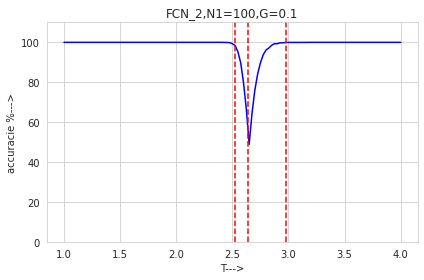

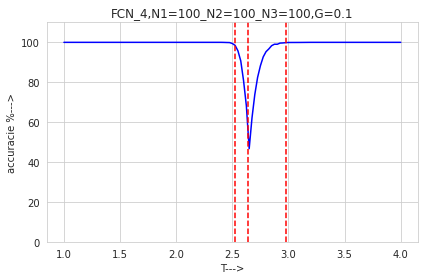

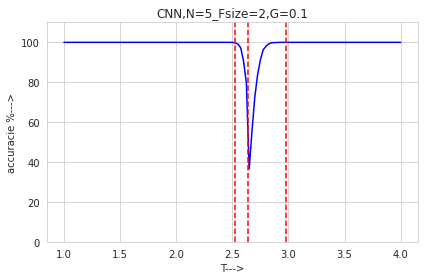

In [37]:
# Plottin all Networks accuriers  for g=0.1 data
import matplotlib.pyplot as plt
import pickle

G_0_1_pkl_data_folder_path = "./G_0.1_data_in_pkl_format"
important_parameters_file_name = "important_parameters.pkl"
important_parameters_file_path = os.path.join(G_0_1_pkl_data_folder_path, important_parameters_file_name)
with open(important_parameters_file_path, 'rb') as f:
    important_parameters_dict = pickle.load(f)
    T_list = important_parameters_dict["T_list"]
    T_critical = important_parameters_dict["T_critical"]
    T_low_for_critical = important_parameters_dict["T_low_for_critical"] 
    T_up_for_critical = important_parameters_dict["T_up_for_critical"]

for key in FCN_2.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"FCN_2,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"FCN_2,{key},G=0.1")
    figure_file_name = f"FCN_2,{key},G=0.1.jpg"
    figure_file_path = os.path.join(accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

for key in FCN_4.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"FCN_4,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"FCN_4,{key},G=0.1")
    figure_file_name = f"FCN_4,{key},G=0.1.jpg"
    figure_file_path = os.path.join(accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

for key in CNN.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"CNN,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"CNN,{key},G=0.1")
    figure_file_name = f"CNN,{key},G=0.1.jpg"
    figure_file_path = os.path.join(accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

In [38]:
import pandas as pd

G_0_1_pkl_data_folder_path = "./G_0.1_data_in_pkl_format"
important_parameters_file_name = "important_parameters.pkl"
important_parameters_file_path = os.path.join(G_0_1_pkl_data_folder_path, important_parameters_file_name)
with open(important_parameters_file_path, 'rb') as f:
    important_parameters_dict = pickle.load(f)
    T_list = important_parameters_dict["T_list"]
    T_critical = important_parameters_dict["T_critical"]
    T_low_for_critical = important_parameters_dict["T_low_for_critical"] 
    T_up_for_critical = important_parameters_dict["T_up_for_critical"]
    
    
    
critical_accuracies_dict = {}
non_critical_accuracies_dict = {}


accuracies_file_names_list = []
for file_name in os.listdir(accuracies_folder_name):
    if file_name.endswith('.csv'):
        if file_name.find("G=0.1")>=0:
            accuracies_file_names_list.append(file_name)


for accuracy_file_name in accuracies_file_names_list:
    accuracy_file_path = os.path.join(accuracies_folder_name, accuracy_file_name)
    df_all = pd.read_csv(accuracy_file_path, header=0)
    filt = (df_all['T_list'] >= T_low_for_critical) & (df_all['T_list'] <= T_up_for_critical)
    df_critical = df_all[filt]
    df_non_critical = df_all[~filt]
    critical_accuracies_dict[accuracy_file_name[0:-4]] = df_critical["accuracies"].mean()
    non_critical_accuracies_dict[accuracy_file_name[0:-4]] = df_non_critical["accuracies"].mean()

for pair in critical_accuracies_dict.items():
    print("critical accuracy -->",pair)
    
for pair in non_critical_accuracies_dict.items():
    print("non critical accuracy -->",pair)



critical accuracy --> ('FCN_4,N1=100_N2=100_N3=100,G=0.1', 86.41588235294117)
critical accuracy --> ('FCN_2,N1=100,G=0.1', 86.88882352941175)
critical accuracy --> ('CNN,N=5_Fsize=2,G=0.1', 88.19)
non critical accuracy --> ('FCN_4,N1=100_N2=100_N3=100,G=0.1', 99.9406818181818)
non critical accuracy --> ('FCN_2,N1=100,G=0.1', 99.93886363636365)
non critical accuracy --> ('CNN,N=5_Fsize=2,G=0.1', 99.99477272727273)


In [39]:
Phase_accuracies_df.loc["J=1.0,G=0.1,Critical", "1_layer_DNN"] = critical_accuracies_dict["FCN_2,N1=100,G=0.1"]
Phase_accuracies_df.loc["J=1.0,G=0.1,Critical", "3_layer_DNN"] = critical_accuracies_dict["FCN_4,N1=100_N2=100_N3=100,G=0.1"]
Phase_accuracies_df.loc["J=1.0,G=0.1,Critical", "CNN"] = critical_accuracies_dict["CNN,N=5_Fsize=2,G=0.1"]
Phase_accuracies_df.loc["J=1.0,G=0.1,Non-Critical", "1_layer_DNN"] = non_critical_accuracies_dict["FCN_2,N1=100,G=0.1"]
Phase_accuracies_df.loc["J=1.0,G=0.1,Non-Critical", "3_layer_DNN"] = non_critical_accuracies_dict["FCN_4,N1=100_N2=100_N3=100,G=0.1"]
Phase_accuracies_df.loc["J=1.0,G=0.1,Non-Critical", "CNN"] = non_critical_accuracies_dict["CNN,N=5_Fsize=2,G=0.1"]
Phase_accuracies_df

,Temperature Range,T_c,1_layer_DNN,3_layer_DNN,CNN,1_layer_DNN_FFT,3_layer_DNN_FFT,CNN_FFT
"J=1.0,G=0.0,Critical","[1.000 ,4.000]","[2.325 ,2.350]",88.272353,87.737059,86.338824,NaN,NaN,NaN
"J=1.0,G=0.0,Non-Critical","[1.000 ,4.000]","[2.325 ,2.350]",100.0,100.0,100.0,NaN,NaN,NaN
"J=1.0,G=0.1,Critical","[1.000 ,4.000]","[2.675 ,2.650]",86.888824,86.415882,88.19,NaN,NaN,NaN
"J=1.0,G=0.1,Non-Critical","[1.000 ,4.000]","[2.675 ,2.650]",99.938864,99.940682,99.994773,NaN,NaN,NaN
"J=1.0,G=0.5,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.5,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=0.0,G=1.0,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=0.0,G=1.0,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=1.0,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=1.0,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Testing for J=1.0, G=0.5 data 

In [40]:
%%time
# G = 0.5 data
# Converting the Raw data with G=0.5 into the data type I need (.pkl files)


# Copied mostly from my Data_read_folder_specific.py file with necessory changes  
# -----------------------------------------------------------------------------------
# Parameters
L = 40
T_array = f5_Gp5['Ts'][:]
G = 0.5
J = 1.0

# folder name for saving the G=0.5 data in .pkl format
G_0_5_pkl_folder_path = f"G_0.5_data_in_pkl_format"
if not os.path.isdir(G_0_5_pkl_folder_path):
    os.mkdir(G_0_5_pkl_folder_path)

No_configerations_for_each_T = 10000 
for i in trange(T_array.shape[0]):
    T = T_array[i]
    data = f5_Gp5['arrs'][i,:,:].reshape(-1, L, L).astype("int8")
    
    data_output_file_name = f"configerations_L_{L}_G_{G:.2f}_J_{J:.2f}_T_{T:.6f}_.pkl"
    # print(data_output_file_name)
    path = os.path.join(G_0_5_pkl_folder_path, data_output_file_name)
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    
# -----------------------------------------------------------------------------------
# To save space
del data

  0%|          | 0/61 [00:00<?, ?it/s]

CPU times: user 8.08 s, sys: 813 ms, total: 8.9 s
Wall time: 13.1 s


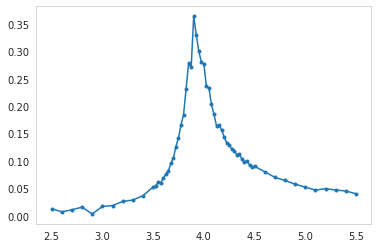

,Temperature Range,T_c,1_layer_DNN,3_layer_DNN,CNN,1_layer_DNN_FFT,3_layer_DNN_FFT,CNN_FFT
"J=1.0,G=0.0,Critical","[1.000 ,4.000]","[2.325 ,2.350]",88.272353,87.737059,86.338824,NaN,NaN,NaN
"J=1.0,G=0.0,Non-Critical","[1.000 ,4.000]","[2.325 ,2.350]",100.0,100.0,100.0,NaN,NaN,NaN
"J=1.0,G=0.1,Critical","[1.000 ,4.000]","[2.675 ,2.650]",86.888824,86.415882,88.19,NaN,NaN,NaN
"J=1.0,G=0.1,Non-Critical","[1.000 ,4.000]","[2.675 ,2.650]",99.938864,99.940682,99.994773,NaN,NaN,NaN
"J=1.0,G=0.5,Critical","[2.500 ,5.500]","[3.900 ,3.925]",NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.5,Non-Critical","[2.500 ,5.500]","[3.900 ,3.925]",NaN,NaN,NaN,NaN,NaN,NaN
"J=0.0,G=1.0,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=0.0,G=1.0,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=1.0,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=1.0,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
#---------------------------------------
#Critical Region: 
#---------------------------------------
Targs=np.arange(61)
xiBs=f5_Gp5['xiBs'][:]
factor=0.30 # Parameter which determines critical region
cut=np.amax(xiBs)*factor
labels_tmp=np.heaviside(xiBs[Targs]-cut,1.0)
crit_start=np.where(labels_tmp==1.0)[0][0]
crit_end=np.where(labels_tmp==1.0)[0][-1]

#Tc from Chi
#crit_Temp=(T_array[xiBs.argsort()[-1]]+T_array[xiBs.argsort()[-2]])/2
crit_Temp=3.8875
################################

#print(T_array[crit_start])
#print(T_array[crit_end])
#print(T_array[crit_pt])
#print(xiBs.argsort()[-1])
#---------------------------------------

plt.figure()
plt.plot(T_array,xiBs,".-")
plt.grid()
plt.show()


# --------------------------------------
Phase_accuracies_df.loc["J=1.0,G=0.5,Critical", "Temperature Range"] = f"[{T_array[0]:.3f} ,{T_array[-1]:.3f}]"
Phase_accuracies_df.loc["J=1.0,G=0.5,Non-Critical", "Temperature Range"] = f"[{T_array[0]:.3f} ,{T_array[-1]:.3f}]"
Phase_accuracies_df.loc["J=1.0,G=0.5,Critical", "T_c"] = f"[{T_array[xiBs.argsort()[-1]]:.3f} ,{T_array[xiBs.argsort()[-2]]:.3f}]"
Phase_accuracies_df.loc["J=1.0,G=0.5,Non-Critical", "T_c"] = f"[{T_array[xiBs.argsort()[-1]]:.3f} ,{T_array[xiBs.argsort()[-2]]:.3f}]"
Phase_accuracies_df


In [42]:
%%time
# Creating ordered_partial,disordered_partial,ordered_complete,disordered_complete,critical data .pkl files for G=0.5

No_configerations_for_each_T = 10000 
# Copied mostly from my Analyze_folder_specific.py file with necessory changes  
# -----------------------------------------------------------------------------------
# Parameters that need to be set manually --------------------------------------------------------------<
J = 1.0
G = 0.5
T_critical = crit_Temp # From Chi values
T_low_for_critical = T_array[crit_start] # From XiB values
T_up_for_critical = T_array[crit_end] # From XiB values
print("J = ", J)
print("G = ", G)
print("T_critical = ", T_critical)
print("T_low_for_critical = ", T_low_for_critical)
print("T_up_for_critical = ", T_up_for_critical)
# ------------------------------------------------------------------------------------------------------>

# Saving all the file names into a dictionary called data file name
G_0_5_pkl_folder_path = f"./G_0.5_data_in_pkl_format"
data_file_names_list = []
for file_name in os.listdir(G_0_5_pkl_folder_path):
    if file_name.endswith('.pkl'):
        if file_name.startswith("configerations_"):
            data_file_names_list.append(file_name)

            
# Storing the data into ordered,disordered and critical data sets --------------------------------------<
# Here I have add "X_ordered_partial" and "X_disordered_partial" data sets contains ordered
# and disordered datasets respectively which are not a part of critical dataset
X_ordered_partial = []
X_disordered_partial = []
Y_ordered_partial = []
Y_disordered_partial = []
X_critical = []
Y_critical = []
T_list = []
for configerations_file_name in data_file_names_list:
    configerations_file_path = os.path.join(G_0_5_pkl_folder_path,configerations_file_name)
    T = float(configerations_file_name.split("_")[8])
    T_list.append(T)
    with open(configerations_file_path, 'rb') as f:
        configerations = pickle.load(f)

    if T < T_low_for_critical:
        X_ordered_partial.append(configerations)
        Y_ordered_partial.append(np.ones(configerations.shape[0]))
    elif T > T_up_for_critical:
        X_disordered_partial.append(configerations)
        Y_disordered_partial.append(np.zeros(configerations.shape[0]))

    elif (T <= T_up_for_critical) and (T >= T_low_for_critical):
        X_critical.append(configerations)
        if T < T_critical:
            Y_critical.append(np.ones(configerations.shape[0]))
        else:
            Y_critical.append(np.zeros(configerations.shape[0]))


X_ordered_partial = np.concatenate(tuple(X_ordered_partial), axis=0)
Y_ordered_partial = np.concatenate(tuple(Y_ordered_partial), axis=0)
X_disordered_partial = np.concatenate(tuple(X_disordered_partial), axis=0)
Y_disordered_partial = np.concatenate(tuple(Y_disordered_partial), axis=0)
X_critical = np.concatenate(tuple(X_critical), axis=0)
Y_critical = np.concatenate(tuple(Y_critical), axis=0)

# Printing shapes of X and unique values of Y Just to checck every thing is fine
# print("X_ordered_partial shape = ", X_ordered_partial.shape)
# print("X_disordered_partial shape = ", X_disordered_partial.shape)
# print("X_critical shape = ", X_critical.shape)
# print("Y_ordered_partial unique values ", np.unique(
#     Y_ordered_partial, return_counts=True))
# print("Y_disordered_partial unique values ", np.unique(
#     Y_disordered_partial, return_counts=True))
# print("Y_critical unique values ", np.unique(Y_critical, return_counts=True))

X_ordered_partial_file_name = "X_ordered_partial.pkl"
X_ordered_partial_file_path = os.path.join(G_0_5_pkl_folder_path,X_ordered_partial_file_name)
X_disordered_partial_file_name = "X_disordered_partial.pkl"
X_disordered_partial_file_path = os.path.join(G_0_5_pkl_folder_path,X_disordered_partial_file_name)
X_critical_file_name = "X_critical.pkl"
X_critical_file_path = os.path.join(G_0_5_pkl_folder_path,X_critical_file_name)
Y_ordered_partial_file_name = "Y_ordered_partial.pkl"
Y_ordered_partial_file_path = os.path.join(G_0_5_pkl_folder_path,Y_ordered_partial_file_name)
Y_disordered_partial_file_name = "Y_disordered_partial.pkl"
Y_disordered_partial_file_path = os.path.join(G_0_5_pkl_folder_path,Y_disordered_partial_file_name)
Y_critical_file_name = "Y_critical.pkl"
Y_critical_file_path = os.path.join(G_0_5_pkl_folder_path,Y_critical_file_name)

with open(X_ordered_partial_file_path, 'wb') as f:
    pickle.dump(X_ordered_partial, f)

with open(X_disordered_partial_file_path, 'wb') as f:
    pickle.dump(X_disordered_partial, f)

with open(X_critical_file_path, 'wb') as f:
    pickle.dump(X_critical, f)

with open(Y_ordered_partial_file_path, 'wb') as f:
    pickle.dump(Y_ordered_partial, f)

with open(Y_disordered_partial_file_path, 'wb') as f:
    pickle.dump(Y_disordered_partial, f)

with open(Y_critical_file_path, 'wb') as f:
    pickle.dump(Y_critical, f)
# ------------------------------------------------------------------------------------------------------>


# Storing the data into ordered and disordered data sets -----------------------------------------------<
# Here I have add "X_ordered_complete" and "X_disordered_complete" data sets contains ordered
# and disordered datasets respectively which are also included in critical dataset
X_ordered_complete = []
X_disordered_complete = []
Y_ordered_complete = []
Y_disordered_complete = []
for configerations_file_name in data_file_names_list:
    configerations_file_path = os.path.join(G_0_5_pkl_folder_path,configerations_file_name)
    T = float(configerations_file_name.split("_")[8])
    with open(configerations_file_path, 'rb') as f:
        configerations = pickle.load(f)

    if T < T_critical:
        X_ordered_complete.append(configerations)
        Y_ordered_complete.append(np.ones(configerations.shape[0]))
    else:
        X_disordered_complete.append(configerations)
        Y_disordered_complete.append(np.zeros(configerations.shape[0]))


X_ordered_complete = np.concatenate(tuple(X_ordered_complete), axis=0)
Y_ordered_complete = np.concatenate(tuple(Y_ordered_complete), axis=0)
X_disordered_complete = np.concatenate(tuple(X_disordered_complete), axis=0)
Y_disordered_complete = np.concatenate(tuple(Y_disordered_complete), axis=0)



# # Printing shapes of X and unique values of Y Just to checck every thing is fine
# print("X_ordered_complete shape = ", X_ordered_complete.shape)
# print("X_disordered_complete shape = ", X_disordered_complete.shape)
# print("Y_ordered_complete unique values ", np.unique(
#     Y_ordered_complete, return_counts=True))
# print("Y_disordered_complete unique values ", np.unique(
#     Y_disordered_complete, return_counts=True))



X_ordered_complete_file_name = "X_ordered_complete.pkl"
X_ordered_complete_file_path = os.path.join(G_0_5_pkl_folder_path,X_ordered_complete_file_name)
X_disordered_complete_file_name = "X_disordered_complete.pkl"
X_disordered_complete_file_path = os.path.join(G_0_5_pkl_folder_path,X_disordered_complete_file_name)
Y_ordered_complete_file_name = "Y_ordered_complete.pkl"
Y_ordered_complete_file_path = os.path.join(G_0_5_pkl_folder_path,Y_ordered_complete_file_name)
Y_disordered_complete_file_name = "Y_disordered_complete.pkl"
Y_disordered_complete_file_path = os.path.join(G_0_5_pkl_folder_path,Y_disordered_complete_file_name)

with open(X_ordered_complete_file_path, 'wb') as f:
    pickle.dump(X_ordered_complete, f)

with open(X_disordered_complete_file_path, 'wb') as f:
    pickle.dump(X_disordered_complete, f)

with open(Y_ordered_complete_file_path, 'wb') as f:
    pickle.dump(Y_ordered_complete, f)

with open(Y_disordered_complete_file_path, 'wb') as f:
    pickle.dump(Y_disordered_complete, f)

print()
# ------------------------------------------------------------------------------------------------------>

# Storing all the imporant paramets into a dictionart to be used in future------------------------------<
important_parameters_file_name = "important_parameters.pkl"
important_parameters_dict = {}
important_parameters_dict["J"] = J
important_parameters_dict["G"] = G
T_list.sort()
important_parameters_dict["T_list"] = T_list
important_parameters_dict["T_critical"] = T_critical
important_parameters_dict["T_low_for_critical"] = T_low_for_critical
important_parameters_dict["T_up_for_critical"] = T_up_for_critical
important_parameters_dict["No_configerations_for_each_T"] = No_configerations_for_each_T

important_parameters_file_path = os.path.join(G_0_5_pkl_folder_path,important_parameters_file_name)
with open(important_parameters_file_path, 'wb') as f:
    pickle.dump(important_parameters_dict, f)


print()
print("-----printing all the imporant paramets(also stored in the file xxx) into a dictionart to be used in future-----")
print(important_parameters_dict)

# ------------------------------------------------------------------------------------------------------>

# To save space
del X_ordered_partial, X_disordered_partial, Y_ordered_partial 
del Y_disordered_partial, X_critical, Y_critical, X_ordered_complete
del Y_ordered_complete, X_disordered_complete, Y_disordered_complete

J =  1.0
G =  0.5
T_critical =  3.8875
T_low_for_critical =  3.725
T_up_for_critical =  4.35


-----printing all the imporant paramets(also stored in the file xxx) into a dictionart to be used in future-----
{'J': 1.0, 'G': 0.5, 'T_list': [2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.525, 3.55, 3.575, 3.6, 3.625, 3.65, 3.675, 3.7, 3.725, 3.75, 3.775, 3.8, 3.825, 3.85, 3.875, 3.9, 3.925, 3.95, 3.975, 4.0, 4.025, 4.05, 4.075, 4.1, 4.125, 4.15, 4.175, 4.2, 4.225, 4.25, 4.275, 4.3, 4.325, 4.35, 4.375, 4.4, 4.425, 4.45, 4.475, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0, 5.1, 5.2, 5.3, 5.4, 5.5], 'T_critical': 3.8875, 'T_low_for_critical': 3.725, 'T_up_for_critical': 4.35, 'No_configerations_for_each_T': 10000}
CPU times: user 886 ms, sys: 4.27 s, total: 5.16 s
Wall time: 6.37 s


## Testing J=1.0, G=0.5

In [43]:
class Testing_dataset_g_0_5(torch.utils.data.Dataset):
    """Ising pytorch Testing dataset for G = 0.5"""

    def __init__(self, data_type, transform=False):
        """
        Args:
            data_type (string): `ordered`, `disordered` : creates data_loader
            transform (callable, optional): Optional transform to be applied on a sample.

        """

        # from sklearn.model_selection import train_test_split
        # import collections
        import pickle
        G_0_5_pkl_data_folder_path = "./G_0.5_data_in_pkl_format"

        X_ordered_file_name = "X_ordered_complete.pkl"
        X_ordered_file_path = os.path.join(G_0_5_pkl_data_folder_path, X_ordered_file_name)
        Y_ordered_file_name = "Y_ordered_complete.pkl"
        Y_ordered_file_path = os.path.join(G_0_5_pkl_data_folder_path, Y_ordered_file_name)
        X_disordered_file_name = "X_disordered_complete.pkl"
        X_disordered_file_path = os.path.join(G_0_5_pkl_data_folder_path, X_disordered_file_name)
        Y_disordered_file_name = "Y_disordered_complete.pkl"
        Y_disordered_file_path = os.path.join(G_0_5_pkl_data_folder_path, Y_disordered_file_name)

        with open(X_ordered_file_path, 'rb') as f:
            X_ordered = pickle.load(f)
        with open(Y_ordered_file_path, 'rb') as f:
            Y_ordered = pickle.load(f)
            Y_ordered = np.int64(Y_ordered)
        with open(X_disordered_file_path, 'rb') as f:
            X_disordered = pickle.load(f)
        with open(Y_disordered_file_path, 'rb') as f:
            Y_disordered = pickle.load(f)
            Y_disordered = np.int64(Y_disordered)

        if data_type == 'ordered':
            X = X_ordered
            Y = Y_ordered

        if data_type == 'disordered':
            X = X_disordered
            Y = Y_disordered

        # these are necessary attributes in dataset class and must be assigned
        self.data = (X, Y)
        self.transform = transform

    # override __len__ and __getitem__ of the Dataset() class

    def __len__(self):
        return len(self.data[1])

    def __getitem__(self, idx):

        sample = (self.data[0][idx, ...], self.data[1][idx])
        if self.transform:
            sample = self.transform(sample)

        return sample


def load_testing_dataset_g_0_5(kwargs, transform= False):
    # kwargs:  CUDA arguments, if enabled
    # load and noralise train,test, and data
    
    ordered_loader = torch.utils.data.DataLoader(
        Testing_dataset_g_0_5(data_type='ordered', transform= transform),
        batch_size=args.test_batch_size, shuffle=False,**kwargs)
    disordered_loader = torch.utils.data.DataLoader(
        Testing_dataset_g_0_5(data_type='disordered', transform= transform),
        batch_size=args.test_batch_size, shuffle=False,**kwargs)

    return ordered_loader, disordered_loader

In [44]:
%%time
ordered_loader, disordered_loader = load_testing_dataset_g_0_5(cuda_kwargs)

ordered_accuracies_dict = {}
disordered_accuracies_dict = {}

test_criterion = nn.NLLLoss(reduction="mean")

for key in FCN_2.keys():
    print(f"Acuracies of model FCN_2 key={key}")
    testing_model = FCN_2[key]

    if args.cuda:
        testing_model.cuda()
    _, ordered_accuracies_dict["FCN_2_"+key+"_ordered"] = test(ordered_loader, testing_model, verbose='ordered',criterion=test_criterion)
    _, disordered_accuracies_dict["FCN_2_"+key+"_disordered"] = test(disordered_loader, testing_model, verbose='disordered',criterion=test_criterion)

for key in FCN_4.keys():
    print(f"Acuracies of model FCN_4 key={key}")
    testing_model = FCN_4[key]

    if args.cuda:
        testing_model.cuda()
    _, ordered_accuracies_dict["FCN_4_"+key+"_ordered"] = test(ordered_loader, testing_model, verbose='ordered',criterion=test_criterion)
    _, disordered_accuracies_dict["FCN_4_"+key+"_disordered"] = test(disordered_loader, testing_model, verbose='disordered',criterion=test_criterion)

for key in CNN.keys():
    print(f"Acuracies of model CNN key={key}")
    testing_model = CNN[key]

    if args.cuda:
        testing_model.cuda()
    _, ordered_accuracies_dict["CNN_"+key+"_ordered"] = test(ordered_loader, testing_model, verbose='ordered',criterion=test_criterion)
    _, disordered_accuracies_dict["CNN_"+key+"_disordered"] = test(disordered_loader, testing_model, verbose='disordered',criterion=test_criterion)

for pair in ordered_accuracies_dict.items():
    print(pair)
for pair in disordered_accuracies_dict.items():
    print(pair)
    
# print(f"ordered_accuracies_dict = {ordered_accuracies_dict}")
# print(f"disordered_accuracies_dict = {disordered_accuracies_dict}")
          
# To save memory
del ordered_loader, disordered_loader

/opt/conda/lib/python3.7/site-packages/torch/utils/data/dataloader.py:481: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))


Acuracies of model FCN_2 key=N1=100

ordered set: Average loss: 0.3240, Accuracy: 247515/260000 (95%)


disordered set: Average loss: 0.2641, Accuracy: 330595/350000 (94%)

Acuracies of model FCN_4 key=N1=100_N2=100_N3=100

ordered set: Average loss: 0.4125, Accuracy: 248137/260000 (95%)


disordered set: Average loss: 0.3924, Accuracy: 329022/350000 (94%)

Acuracies of model CNN key=N=5_Fsize=2

ordered set: Average loss: 0.4146, Accuracy: 239814/260000 (92%)


disordered set: Average loss: 0.0641, Accuracy: 344211/350000 (98%)

('FCN_2_N1=100_ordered', 95.19807692307693)
('FCN_4_N1=100_N2=100_N3=100_ordered', 95.4373076923077)
('CNN_N=5_Fsize=2_ordered', 92.23615384615384)
('FCN_2_N1=100_disordered', 94.45571428571428)
('FCN_4_N1=100_N2=100_N3=100_disordered', 94.00628571428571)
('CNN_N=5_Fsize=2_disordered', 98.346)
CPU times: user 3.3 s, sys: 6.79 s, total: 10.1 s
Wall time: 23.5 s


## Calculating the accuracies for Critical and non critical Datasets for J=1.0, G=0.5

In [45]:
class Testing_dataset_g_0_5_ver2(torch.utils.data.Dataset):
    """Ising pytorch Testing dataset for G = 0.5"""

    def __init__(self, data_type, transform=False):
        """
        Args:
            data_type (string): f"T_{T:.6f}", Where T is one of the possible Temperatures
            transform (callable, optional): Optional transform to be applied on a sample.

        """

        # from sklearn.model_selection import train_test_split
        # import collections
        import pickle
        G_0_5_pkl_data_folder_path = "./G_0.5_data_in_pkl_format"
        important_parameters_file_name = "important_parameters.pkl"
        important_parameters_file_path = os.path.join(
            G_0_5_pkl_data_folder_path, important_parameters_file_name)
        with open(important_parameters_file_path, 'rb') as f:
            important_parameters_dict = pickle.load(f)

        T_critical = important_parameters_dict["T_critical"]
        T_low_for_critical = important_parameters_dict["T_low_for_critical"]  
        T_up_for_critical = important_parameters_dict["T_up_for_critical"]  

        data_file_names_list = []
        for file_name in os.listdir(G_0_5_pkl_data_folder_path):
            if file_name.endswith('.pkl'):
                if file_name.startswith('configerations_'):
                    data_file_names_list.append(file_name)

        X_dict = {}
        Y_dict = {}
        for data_file_name in data_file_names_list:
            T = np.float(data_file_name.split("_")[8])
            data_file_path = os.path.join(
                G_0_5_pkl_data_folder_path, data_file_name)
            with open(data_file_path, 'rb') as f:
                configerations = pickle.load(f)
            X_dict[f"T_{T:.6f}"] = configerations
            if T < T_critical:
                Y_dict[f"T_{T:.6f}"] = np.ones(configerations.shape[0])
                Y_dict[f"T_{T:.6f}"] = np.int64(Y_dict[f"T_{T:.6f}"])
            else:
                Y_dict[f"T_{T:.6f}"] = np.zeros(configerations.shape[0])
                Y_dict[f"T_{T:.6f}"] = np.int64(Y_dict[f"T_{T:.6f}"])

        X = X_dict[data_type]
        Y = Y_dict[data_type]

        # these are necessary attributes in dataset class and must be assigned
        self.data = (X, Y)
        self.transform = transform

    # override __len__ and __getitem__ of the Dataset() class

    def __len__(self):
        return len(self.data[1])

    def __getitem__(self, idx):

        sample = (self.data[0][idx, ...], self.data[1][idx])
        if self.transform:
            sample = self.transform(sample)

        return sample


def load_testing_dataset_g_0_5_ver2(kwargs, transform=False):
    # kwargs:  CUDA arguments, if enabled
    # load and noralise train,test, and data
    import pickle
    G_0_5_pkl_data_folder_path = "./G_0.5_data_in_pkl_format"
    important_parameters_file_name = "important_parameters.pkl"
    important_parameters_file_path = os.path.join(
        G_0_5_pkl_data_folder_path, important_parameters_file_name)
    with open(important_parameters_file_path, 'rb') as f:
        important_parameters_dict = pickle.load(f)
#     T_critical = important_parameters_dict["T_critical"]
    T_list = important_parameters_dict["T_list"]
#     No_configerations_for_each_T = important_parameters_dict["No_configerations_for_each_T"]

    data_loader_dict = {}
    for T in T_list:
        data_loader_dict[f"T_{T:.6f}"] = torch.utils.data.DataLoader(Testing_dataset_g_0_5_ver2(
            data_type=f"T_{T:.6f}", transform=transform), batch_size=args.test_batch_size, shuffle=False, **kwargs)

    return data_loader_dict

In [46]:
%%time
data_loader_dict = load_testing_dataset_g_0_5_ver2(cuda_kwargs)

accuracies_dict = {}

test_criterion = nn.NLLLoss(reduction="mean")

for key in FCN_2.keys():
    testing_model = FCN_2[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"FCN_2,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"FCN_2,{key},{T_key}",criterion=test_criterion)


for key in FCN_4.keys():
    testing_model = FCN_4[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"FCN_4,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"FCN_4,{key},{T_key}",criterion=test_criterion)

for key in CNN.keys():
    testing_model = CNN[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"CNN,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"CNN,{key},{T_key}",criterion=test_criterion)


for pair in accuracies_dict.items():
    print(pair)

# print(f"accuracies_dict = {accuracies_dict}")
# To save memory
del data_loader_dict



FCN_2,N1=100,T_2.500000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.600000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.700000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.800000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.900000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_3.000000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_3.100000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_3.200000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_3.300000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_3.400000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_3.500000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_3.525000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_

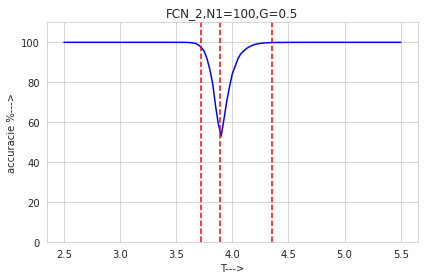

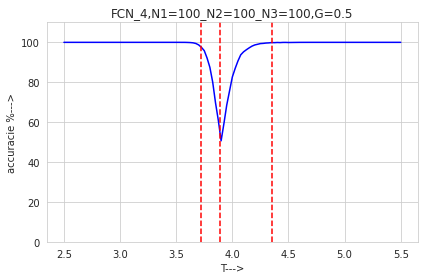

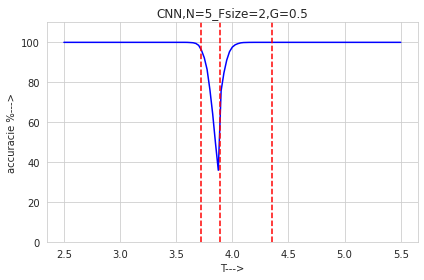

In [47]:
# Plottin all Networks accuriers  for g=0.5 data
import matplotlib.pyplot as plt
import pickle

G_0_5_pkl_data_folder_path = "./G_0.5_data_in_pkl_format"
important_parameters_file_name = "important_parameters.pkl"
important_parameters_file_path = os.path.join(G_0_5_pkl_data_folder_path, important_parameters_file_name)
with open(important_parameters_file_path, 'rb') as f:
    important_parameters_dict = pickle.load(f)
    T_list = important_parameters_dict["T_list"]
    T_critical = important_parameters_dict["T_critical"]
    T_low_for_critical = important_parameters_dict["T_low_for_critical"] 
    T_up_for_critical = important_parameters_dict["T_up_for_critical"]

for key in FCN_2.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"FCN_2,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"FCN_2,{key},G=0.5")
    figure_file_name = f"FCN_2,{key},G=0.5.jpg"
    figure_file_path = os.path.join(accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

for key in FCN_4.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"FCN_4,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"FCN_4,{key},G=0.5")
    figure_file_name = f"FCN_4,{key},G=0.5.jpg"
    figure_file_path = os.path.join(accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

for key in CNN.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"CNN,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"CNN,{key},G=0.5")
    figure_file_name = f"CNN,{key},G=0.5.jpg"
    figure_file_path = os.path.join(accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

In [48]:
import pandas as pd

G_0_5_pkl_data_folder_path = "./G_0.5_data_in_pkl_format"
important_parameters_file_name = "important_parameters.pkl"
important_parameters_file_path = os.path.join(G_0_5_pkl_data_folder_path, important_parameters_file_name)
with open(important_parameters_file_path, 'rb') as f:
    important_parameters_dict = pickle.load(f)
    T_list = important_parameters_dict["T_list"]
    T_critical = important_parameters_dict["T_critical"]
    T_low_for_critical = important_parameters_dict["T_low_for_critical"] 
    T_up_for_critical = important_parameters_dict["T_up_for_critical"]
    
    
    
critical_accuracies_dict = {}
non_critical_accuracies_dict = {}


accuracies_file_names_list = []
for file_name in os.listdir(accuracies_folder_name):
    if file_name.endswith('.csv'):
        if file_name.find("G=0.5")>=0:
            accuracies_file_names_list.append(file_name)


for accuracy_file_name in accuracies_file_names_list:
    accuracy_file_path = os.path.join(accuracies_folder_name, accuracy_file_name)
    df_all = pd.read_csv(accuracy_file_path, header=0)
    filt = (df_all['T_list'] >= T_low_for_critical) & (df_all['T_list'] <= T_up_for_critical)
    df_critical = df_all[filt]
    df_non_critical = df_all[~filt]
    critical_accuracies_dict[accuracy_file_name[0:-4]] = df_critical["accuracies"].mean()
    non_critical_accuracies_dict[accuracy_file_name[0:-4]] = df_non_critical["accuracies"].mean()

for pair in critical_accuracies_dict.items():
    print("critical accuracy -->",pair)
    
for pair in non_critical_accuracies_dict.items():
    print("non critical accuracy -->",pair)



critical accuracy --> ('FCN_4,N1=100_N2=100_N3=100,G=0.5', 86.9792)
critical accuracy --> ('CNN,N=5_Fsize=2,G=0.5', 89.70480000000002)
critical accuracy --> ('FCN_2,N1=100,G=0.5', 87.35719999999999)
non critical accuracy --> ('FCN_4,N1=100_N2=100_N3=100,G=0.5', 99.91972222222222)
non critical accuracy --> ('CNN,N=5_Fsize=2,G=0.5', 99.93416666666667)
non critical accuracy --> ('FCN_2,N1=100,G=0.5', 99.92138888888888)


In [49]:
Phase_accuracies_df.loc["J=1.0,G=0.5,Critical", "1_layer_DNN"] = critical_accuracies_dict["FCN_2,N1=100,G=0.5"]
Phase_accuracies_df.loc["J=1.0,G=0.5,Critical", "3_layer_DNN"] = critical_accuracies_dict["FCN_4,N1=100_N2=100_N3=100,G=0.5"]
Phase_accuracies_df.loc["J=1.0,G=0.5,Critical", "CNN"] = critical_accuracies_dict["CNN,N=5_Fsize=2,G=0.5"]
Phase_accuracies_df.loc["J=1.0,G=0.5,Non-Critical", "1_layer_DNN"] = non_critical_accuracies_dict["FCN_2,N1=100,G=0.5"]
Phase_accuracies_df.loc["J=1.0,G=0.5,Non-Critical", "3_layer_DNN"] = non_critical_accuracies_dict["FCN_4,N1=100_N2=100_N3=100,G=0.5"]
Phase_accuracies_df.loc["J=1.0,G=0.5,Non-Critical", "CNN"] = non_critical_accuracies_dict["CNN,N=5_Fsize=2,G=0.5"]
Phase_accuracies_df

,Temperature Range,T_c,1_layer_DNN,3_layer_DNN,CNN,1_layer_DNN_FFT,3_layer_DNN_FFT,CNN_FFT
"J=1.0,G=0.0,Critical","[1.000 ,4.000]","[2.325 ,2.350]",88.272353,87.737059,86.338824,NaN,NaN,NaN
"J=1.0,G=0.0,Non-Critical","[1.000 ,4.000]","[2.325 ,2.350]",100.0,100.0,100.0,NaN,NaN,NaN
"J=1.0,G=0.1,Critical","[1.000 ,4.000]","[2.675 ,2.650]",86.888824,86.415882,88.19,NaN,NaN,NaN
"J=1.0,G=0.1,Non-Critical","[1.000 ,4.000]","[2.675 ,2.650]",99.938864,99.940682,99.994773,NaN,NaN,NaN
"J=1.0,G=0.5,Critical","[2.500 ,5.500]","[3.900 ,3.925]",87.3572,86.9792,89.7048,NaN,NaN,NaN
"J=1.0,G=0.5,Non-Critical","[2.500 ,5.500]","[3.900 ,3.925]",99.921389,99.919722,99.934167,NaN,NaN,NaN
"J=0.0,G=1.0,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=0.0,G=1.0,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=1.0,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=1.0,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Testing the accuracies of all the models  for ordered and disordered datasets of J=0.0 ,G=1.0

In [50]:
%%time
# G = 1.0 , J=0.0 data
# Converting the Raw data with G = 1.0 , J=0.0 into the data type I need (.pkl files)


# Copied mostly from my Data_read_folder_specific.py file with necessory changes  
# -----------------------------------------------------------------------------------
# Parameters
L = 40
T_array = f5_G1_J0['Ts'][:]
G = 1.0
J = 0.0

# folder name for saving the G=0.5 data in .pkl format
G_1_J_0_pkl_folder_path = f"G_1_J_0_data_in_pkl_format"
if not os.path.isdir(G_1_J_0_pkl_folder_path):
    os.mkdir(G_1_J_0_pkl_folder_path)

No_configerations_for_each_T = 10000 
for i in trange(T_array.shape[0]):
    T = T_array[i]
    data = f5_G1_J0['arrs'][i,:,:].reshape(-1, L, L).astype("int8")
    
    data_output_file_name = f"configerations_L_{L}_G_{G:.2f}_J_{J:.2f}_T_{T:.6f}_.pkl"
    # print(data_output_file_name)
    path = os.path.join(G_1_J_0_pkl_folder_path, data_output_file_name)
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    
# -----------------------------------------------------------------------------------
# To save space
del data

  0%|          | 0/61 [00:00<?, ?it/s]

CPU times: user 8 s, sys: 816 ms, total: 8.81 s
Wall time: 12.6 s


2.4625


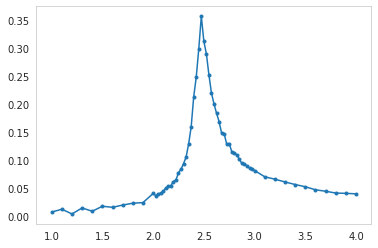

,Temperature Range,T_c,1_layer_DNN,3_layer_DNN,CNN,1_layer_DNN_FFT,3_layer_DNN_FFT,CNN_FFT
"J=1.0,G=0.0,Critical","[1.000 ,4.000]","[2.325 ,2.350]",88.272353,87.737059,86.338824,NaN,NaN,NaN
"J=1.0,G=0.0,Non-Critical","[1.000 ,4.000]","[2.325 ,2.350]",100.0,100.0,100.0,NaN,NaN,NaN
"J=1.0,G=0.1,Critical","[1.000 ,4.000]","[2.675 ,2.650]",86.888824,86.415882,88.19,NaN,NaN,NaN
"J=1.0,G=0.1,Non-Critical","[1.000 ,4.000]","[2.675 ,2.650]",99.938864,99.940682,99.994773,NaN,NaN,NaN
"J=1.0,G=0.5,Critical","[2.500 ,5.500]","[3.900 ,3.925]",87.3572,86.9792,89.7048,NaN,NaN,NaN
"J=1.0,G=0.5,Non-Critical","[2.500 ,5.500]","[3.900 ,3.925]",99.921389,99.919722,99.934167,NaN,NaN,NaN
"J=0.0,G=1.0,Critical","[1.000 ,4.000]","[2.475 ,2.500]",NaN,NaN,NaN,NaN,NaN,NaN
"J=0.0,G=1.0,Non-Critical","[1.000 ,4.000]","[2.475 ,2.500]",NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=1.0,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=1.0,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
#---------------------------------------
#Critical Region: 
#---------------------------------------
Targs=np.arange(61)
xiBs=f5_G1_J0['xiBs'][:]
factor=0.30 # Parameter which determines critical region
cut=np.amax(xiBs)*factor
labels_tmp=np.heaviside(xiBs[Targs]-cut,1.0)
crit_start=np.where(labels_tmp==1.0)[0][0]
crit_end=np.where(labels_tmp==1.0)[0][-1]

#Tc from Chi
#crit_Temp=(T_array[xiBs.argsort()[-1]]+T_array[xiBs.argsort()[-2]])/2
crit_Temp=2.4625
#############################

#print(T_array[crit_start])
#print(T_array[crit_end])
#print(T_array[crit_pt])
#print(xiBs.argsort()[-1])
print(crit_Temp)
#---------------------------------------

plt.figure()
plt.plot(T_array,xiBs,".-")
plt.grid()
plt.show()


# --------------------------------------
Phase_accuracies_df.loc["J=0.0,G=1.0,Critical", "Temperature Range"] = f"[{T_array[0]:.3f} ,{T_array[-1]:.3f}]"
Phase_accuracies_df.loc["J=0.0,G=1.0,Non-Critical", "Temperature Range"] = f"[{T_array[0]:.3f} ,{T_array[-1]:.3f}]"
Phase_accuracies_df.loc["J=0.0,G=1.0,Critical", "T_c"] = f"[{T_array[xiBs.argsort()[-1]]:.3f} ,{T_array[xiBs.argsort()[-2]]:.3f}]"
Phase_accuracies_df.loc["J=0.0,G=1.0,Non-Critical", "T_c"] = f"[{T_array[xiBs.argsort()[-1]]:.3f} ,{T_array[xiBs.argsort()[-2]]:.3f}]"
Phase_accuracies_df

In [52]:
%%time
# Creating ordered_partial,disordered_partial,ordered_complete,disordered_complete,critical data .pkl files for J=0.0,G=1.0

No_configerations_for_each_T = 10000 
# Copied mostly from my Analyze_folder_specific.py file with necessory changes  
# -----------------------------------------------------------------------------------
# Parameters that need to be set manually --------------------------------------------------------------<
J = 0.0
G = 1.0
T_critical = crit_Temp # From Chi values
T_low_for_critical = T_array[crit_start] # From XiB values
T_up_for_critical = T_array[crit_end] # From XiB values
print("J = ", J)
print("G = ", G)
print("T_critical = ", T_critical)
print("T_low_for_critical = ", T_low_for_critical)
print("T_up_for_critical = ", T_up_for_critical)
# ------------------------------------------------------------------------------------------------------>

# Saving all the file names into a dictionary called data file name
G_1_J_0_pkl_folder_path = f"./G_1_J_0_data_in_pkl_format"
data_file_names_list = []
for file_name in os.listdir(G_1_J_0_pkl_folder_path):
    if file_name.endswith('.pkl'):
        if file_name.startswith("configerations_"):
            data_file_names_list.append(file_name)

            
# Storing the data into ordered,disordered and critical data sets --------------------------------------<
# Here I have add "X_ordered_partial" and "X_disordered_partial" data sets contains ordered
# and disordered datasets respectively which are not a part of critical dataset
X_ordered_partial = []
X_disordered_partial = []
Y_ordered_partial = []
Y_disordered_partial = []
X_critical = []
Y_critical = []
T_list = []
for configerations_file_name in data_file_names_list:
    configerations_file_path = os.path.join(G_1_J_0_pkl_folder_path,configerations_file_name)
    T = float(configerations_file_name.split("_")[8])
    T_list.append(T)
    with open(configerations_file_path, 'rb') as f:
        configerations = pickle.load(f)

    if T < T_low_for_critical:
        X_ordered_partial.append(configerations)
        Y_ordered_partial.append(np.ones(configerations.shape[0]))
    elif T > T_up_for_critical:
        X_disordered_partial.append(configerations)
        Y_disordered_partial.append(np.zeros(configerations.shape[0]))

    elif (T <= T_up_for_critical) and (T >= T_low_for_critical):
        X_critical.append(configerations)
        if T < T_critical:
            Y_critical.append(np.ones(configerations.shape[0]))
        else:
            Y_critical.append(np.zeros(configerations.shape[0]))


X_ordered_partial = np.concatenate(tuple(X_ordered_partial), axis=0)
Y_ordered_partial = np.concatenate(tuple(Y_ordered_partial), axis=0)
X_disordered_partial = np.concatenate(tuple(X_disordered_partial), axis=0)
Y_disordered_partial = np.concatenate(tuple(Y_disordered_partial), axis=0)
X_critical = np.concatenate(tuple(X_critical), axis=0)
Y_critical = np.concatenate(tuple(Y_critical), axis=0)

# Printing shapes of X and unique values of Y Just to checck every thing is fine
# print("X_ordered_partial shape = ", X_ordered_partial.shape)
# print("X_disordered_partial shape = ", X_disordered_partial.shape)
# print("X_critical shape = ", X_critical.shape)
# print("Y_ordered_partial unique values ", np.unique(
#     Y_ordered_partial, return_counts=True))
# print("Y_disordered_partial unique values ", np.unique(
#     Y_disordered_partial, return_counts=True))
# print("Y_critical unique values ", np.unique(Y_critical, return_counts=True))

X_ordered_partial_file_name = "X_ordered_partial.pkl"
X_ordered_partial_file_path = os.path.join(G_1_J_0_pkl_folder_path,X_ordered_partial_file_name)
X_disordered_partial_file_name = "X_disordered_partial.pkl"
X_disordered_partial_file_path = os.path.join(G_1_J_0_pkl_folder_path,X_disordered_partial_file_name)
X_critical_file_name = "X_critical.pkl"
X_critical_file_path = os.path.join(G_1_J_0_pkl_folder_path,X_critical_file_name)
Y_ordered_partial_file_name = "Y_ordered_partial.pkl"
Y_ordered_partial_file_path = os.path.join(G_1_J_0_pkl_folder_path,Y_ordered_partial_file_name)
Y_disordered_partial_file_name = "Y_disordered_partial.pkl"
Y_disordered_partial_file_path = os.path.join(G_1_J_0_pkl_folder_path,Y_disordered_partial_file_name)
Y_critical_file_name = "Y_critical.pkl"
Y_critical_file_path = os.path.join(G_1_J_0_pkl_folder_path,Y_critical_file_name)

with open(X_ordered_partial_file_path, 'wb') as f:
    pickle.dump(X_ordered_partial, f)

with open(X_disordered_partial_file_path, 'wb') as f:
    pickle.dump(X_disordered_partial, f)

with open(X_critical_file_path, 'wb') as f:
    pickle.dump(X_critical, f)

with open(Y_ordered_partial_file_path, 'wb') as f:
    pickle.dump(Y_ordered_partial, f)

with open(Y_disordered_partial_file_path, 'wb') as f:
    pickle.dump(Y_disordered_partial, f)

with open(Y_critical_file_path, 'wb') as f:
    pickle.dump(Y_critical, f)
# ------------------------------------------------------------------------------------------------------>


# Storing the data into ordered and disordered data sets -----------------------------------------------<
# Here I have add "X_ordered_complete" and "X_disordered_complete" data sets contains ordered
# and disordered datasets respectively which are also included in critical dataset
X_ordered_complete = []
X_disordered_complete = []
Y_ordered_complete = []
Y_disordered_complete = []
for configerations_file_name in data_file_names_list:
    configerations_file_path = os.path.join(G_1_J_0_pkl_folder_path,configerations_file_name)
    T = float(configerations_file_name.split("_")[8])
    with open(configerations_file_path, 'rb') as f:
        configerations = pickle.load(f)

    if T < T_critical:
        X_ordered_complete.append(configerations)
        Y_ordered_complete.append(np.ones(configerations.shape[0]))
    else:
        X_disordered_complete.append(configerations)
        Y_disordered_complete.append(np.zeros(configerations.shape[0]))


X_ordered_complete = np.concatenate(tuple(X_ordered_complete), axis=0)
Y_ordered_complete = np.concatenate(tuple(Y_ordered_complete), axis=0)
X_disordered_complete = np.concatenate(tuple(X_disordered_complete), axis=0)
Y_disordered_complete = np.concatenate(tuple(Y_disordered_complete), axis=0)



# # Printing shapes of X and unique values of Y Just to checck every thing is fine
# print("X_ordered_complete shape = ", X_ordered_complete.shape)
# print("X_disordered_complete shape = ", X_disordered_complete.shape)
# print("Y_ordered_complete unique values ", np.unique(
#     Y_ordered_complete, return_counts=True))
# print("Y_disordered_complete unique values ", np.unique(
#     Y_disordered_complete, return_counts=True))



X_ordered_complete_file_name = "X_ordered_complete.pkl"
X_ordered_complete_file_path = os.path.join(G_1_J_0_pkl_folder_path,X_ordered_complete_file_name)
X_disordered_complete_file_name = "X_disordered_complete.pkl"
X_disordered_complete_file_path = os.path.join(G_1_J_0_pkl_folder_path,X_disordered_complete_file_name)
Y_ordered_complete_file_name = "Y_ordered_complete.pkl"
Y_ordered_complete_file_path = os.path.join(G_1_J_0_pkl_folder_path,Y_ordered_complete_file_name)
Y_disordered_complete_file_name = "Y_disordered_complete.pkl"
Y_disordered_complete_file_path = os.path.join(G_1_J_0_pkl_folder_path,Y_disordered_complete_file_name)

with open(X_ordered_complete_file_path, 'wb') as f:
    pickle.dump(X_ordered_complete, f)

with open(X_disordered_complete_file_path, 'wb') as f:
    pickle.dump(X_disordered_complete, f)

with open(Y_ordered_complete_file_path, 'wb') as f:
    pickle.dump(Y_ordered_complete, f)

with open(Y_disordered_complete_file_path, 'wb') as f:
    pickle.dump(Y_disordered_complete, f)

print()
# ------------------------------------------------------------------------------------------------------>

# Storing all the imporant paramets into a dictionart to be used in future------------------------------<
important_parameters_file_name = "important_parameters.pkl"
important_parameters_dict = {}
important_parameters_dict["J"] = J
important_parameters_dict["G"] = G
T_list.sort()
important_parameters_dict["T_list"] = T_list
important_parameters_dict["T_critical"] = T_critical
important_parameters_dict["T_low_for_critical"] = T_low_for_critical
important_parameters_dict["T_up_for_critical"] = T_up_for_critical
important_parameters_dict["No_configerations_for_each_T"] = No_configerations_for_each_T

important_parameters_file_path = os.path.join(G_1_J_0_pkl_folder_path,important_parameters_file_name)
with open(important_parameters_file_path, 'wb') as f:
    pickle.dump(important_parameters_dict, f)


print()
print("-----printing all the imporant paramets(also stored in the file xxx) into a dictionart to be used in future-----")
print(important_parameters_dict)

# ------------------------------------------------------------------------------------------------------>

# To save space
del X_ordered_partial, X_disordered_partial, Y_ordered_partial 
del Y_disordered_partial, X_critical, Y_critical, X_ordered_complete
del Y_ordered_complete, X_disordered_complete, Y_disordered_complete

J =  0.0
G =  1.0
T_critical =  2.4625
T_low_for_critical =  2.35
T_up_for_critical =  2.825


-----printing all the imporant paramets(also stored in the file xxx) into a dictionart to be used in future-----
{'J': 0.0, 'G': 1.0, 'T_list': [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.025, 2.05, 2.075, 2.1, 2.125, 2.15, 2.175, 2.2, 2.225, 2.25, 2.275, 2.3, 2.325, 2.35, 2.375, 2.4, 2.425, 2.45, 2.475, 2.5, 2.525, 2.55, 2.575, 2.6, 2.625, 2.65, 2.675, 2.7, 2.725, 2.75, 2.775, 2.8, 2.825, 2.85, 2.875, 2.9, 2.925, 2.95, 2.975, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0], 'T_critical': 2.4625, 'T_low_for_critical': 2.35, 'T_up_for_critical': 2.825, 'No_configerations_for_each_T': 10000}
CPU times: user 929 ms, sys: 5.12 s, total: 6.04 s
Wall time: 7.16 s


## Testing J=0.0, G=1.0 data

In [53]:
class Testing_dataset_G_1_J_0(torch.utils.data.Dataset):
    """Ising pytorch Testing dataset for J=0.0, G=1.0"""

    def __init__(self, data_type, transform=False):
        """
        Args:
            data_type (string): `ordered`, `disordered` : creates data_loader
            transform (callable, optional): Optional transform to be applied on a sample.

        """

        # from sklearn.model_selection import train_test_split
        # import collections
        import pickle
        G_1_J_0_pkl_folder_path = "./G_1_J_0_data_in_pkl_format"

        X_ordered_file_name = "X_ordered_complete.pkl"
        X_ordered_file_path = os.path.join(G_1_J_0_pkl_folder_path, X_ordered_file_name)
        Y_ordered_file_name = "Y_ordered_complete.pkl"
        Y_ordered_file_path = os.path.join(G_1_J_0_pkl_folder_path, Y_ordered_file_name)
        X_disordered_file_name = "X_disordered_complete.pkl"
        X_disordered_file_path = os.path.join(G_1_J_0_pkl_folder_path, X_disordered_file_name)
        Y_disordered_file_name = "Y_disordered_complete.pkl"
        Y_disordered_file_path = os.path.join(G_1_J_0_pkl_folder_path, Y_disordered_file_name)

        with open(X_ordered_file_path, 'rb') as f:
            X_ordered = pickle.load(f)
        with open(Y_ordered_file_path, 'rb') as f:
            Y_ordered = pickle.load(f)
            Y_ordered = np.int64(Y_ordered)
        with open(X_disordered_file_path, 'rb') as f:
            X_disordered = pickle.load(f)
        with open(Y_disordered_file_path, 'rb') as f:
            Y_disordered = pickle.load(f)
            Y_disordered = np.int64(Y_disordered)

        if data_type == 'ordered':
            X = X_ordered
            Y = Y_ordered

        if data_type == 'disordered':
            X = X_disordered
            Y = Y_disordered

        # these are necessary attributes in dataset class and must be assigned
        self.data = (X, Y)
        self.transform = transform

    # override __len__ and __getitem__ of the Dataset() class

    def __len__(self):
        return len(self.data[1])

    def __getitem__(self, idx):

        sample = (self.data[0][idx, ...], self.data[1][idx])
        if self.transform:
            sample = self.transform(sample)

        return sample


def load_testing_dataset_G_1_J_0(kwargs, transform= False):
    # kwargs:  CUDA arguments, if enabled
    # load and noralise train,test, and data
    
    ordered_loader = torch.utils.data.DataLoader(
        Testing_dataset_G_1_J_0(data_type='ordered', transform= transform),
        batch_size=args.test_batch_size, shuffle=False,**kwargs)
    disordered_loader = torch.utils.data.DataLoader(
        Testing_dataset_G_1_J_0(data_type='disordered', transform= transform),
        batch_size=args.test_batch_size, shuffle=False,**kwargs)

    return ordered_loader, disordered_loader

In [54]:
%%time
ordered_loader, disordered_loader = load_testing_dataset_G_1_J_0(cuda_kwargs)

ordered_accuracies_dict = {}
disordered_accuracies_dict = {}

test_criterion = nn.NLLLoss(reduction="mean")


for key in FCN_2.keys():
    print(f"Acuracies of model FCN_2 key={key}")
    testing_model = FCN_2[key]

    if args.cuda:
        testing_model.cuda()
    _, ordered_accuracies_dict["FCN_2_"+key+"_ordered"] = test(ordered_loader, testing_model, verbose='ordered',criterion=test_criterion)
    _, disordered_accuracies_dict["FCN_2_"+key+"_disordered"] = test(disordered_loader, testing_model, verbose='disordered',criterion=test_criterion)

for key in FCN_4.keys():
    print(f"Acuracies of model FCN_4 key={key}")
    testing_model = FCN_4[key]

    if args.cuda:
        testing_model.cuda()
    _, ordered_accuracies_dict["FCN_4_"+key+"_ordered"] = test(ordered_loader, testing_model, verbose='ordered',criterion=test_criterion)
    _, disordered_accuracies_dict["FCN_4_"+key+"_disordered"] = test(disordered_loader, testing_model, verbose='disordered',criterion=test_criterion)

for key in CNN.keys():
    print(f"Acuracies of model CNN key={key}")
    testing_model = CNN[key]

    if args.cuda:
        testing_model.cuda()
    _, ordered_accuracies_dict["CNN_"+key+"_ordered"] = test(ordered_loader, testing_model, verbose='ordered',criterion=test_criterion)
    _, disordered_accuracies_dict["CNN_"+key+"_disordered"] = test(disordered_loader, testing_model, verbose='disordered',criterion=test_criterion)

for pair in ordered_accuracies_dict.items():
    print(pair)
for pair in disordered_accuracies_dict.items():
    print(pair)
    
# print(f"ordered_accuracies_dict = {ordered_accuracies_dict}")
# print(f"disordered_accuracies_dict = {disordered_accuracies_dict}")
          
# To save memory
del ordered_loader, disordered_loader

/opt/conda/lib/python3.7/site-packages/torch/utils/data/dataloader.py:481: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))


Acuracies of model FCN_2 key=N1=100

ordered set: Average loss: 0.2348, Accuracy: 279317/290000 (96%)


disordered set: Average loss: 0.1074, Accuracy: 311308/320000 (97%)

Acuracies of model FCN_4 key=N1=100_N2=100_N3=100

ordered set: Average loss: 0.3341, Accuracy: 279105/290000 (96%)


disordered set: Average loss: 0.1412, Accuracy: 311565/320000 (97%)

Acuracies of model CNN key=N=5_Fsize=2

ordered set: Average loss: 3.3740, Accuracy: 237487/290000 (82%)


disordered set: Average loss: 0.0003, Accuracy: 319977/320000 (100%)

('FCN_2_N1=100_ordered', 96.31620689655172)
('FCN_4_N1=100_N2=100_N3=100_ordered', 96.24310344827586)
('CNN_N=5_Fsize=2_ordered', 81.89206896551724)
('FCN_2_N1=100_disordered', 97.28375)
('FCN_4_N1=100_N2=100_N3=100_disordered', 97.3640625)
('CNN_N=5_Fsize=2_disordered', 99.9928125)
CPU times: user 3.29 s, sys: 6.77 s, total: 10.1 s
Wall time: 38.1 s


## Calculating the accuracies for Critical and non critical Datasets for J=0.0, G=1.0

In [55]:
class Testing_dataset_G_1_J_0_ver2(torch.utils.data.Dataset):
    """Ising pytorch Testing dataset for J=0.0 , G=1.0"""

    def __init__(self, data_type, transform=False):
        """
        Args:
            data_type (string): f"T_{T:.6f}", Where T is one of the possible Temperatures
            transform (callable, optional): Optional transform to be applied on a sample.

        """

        # from sklearn.model_selection import train_test_split
        # import collections
        import pickle
        G_1_J_0_pkl_folder_path = "./G_1_J_0_data_in_pkl_format"
        important_parameters_file_name = "important_parameters.pkl"
        important_parameters_file_path = os.path.join(
            G_1_J_0_pkl_folder_path, important_parameters_file_name)
        with open(important_parameters_file_path, 'rb') as f:
            important_parameters_dict = pickle.load(f)

        T_critical = important_parameters_dict["T_critical"]
        T_low_for_critical = important_parameters_dict["T_low_for_critical"]  
        T_up_for_critical = important_parameters_dict["T_up_for_critical"]  

        data_file_names_list = []
        for file_name in os.listdir(G_1_J_0_pkl_folder_path):
            if file_name.endswith('.pkl'):
                if file_name.startswith('configerations_'):
                    data_file_names_list.append(file_name)

        X_dict = {}
        Y_dict = {}
        for data_file_name in data_file_names_list:
            T = np.float(data_file_name.split("_")[8])
            data_file_path = os.path.join(
                G_1_J_0_pkl_folder_path, data_file_name)
            with open(data_file_path, 'rb') as f:
                configerations = pickle.load(f)
            X_dict[f"T_{T:.6f}"] = configerations
            if T < T_critical:
                Y_dict[f"T_{T:.6f}"] = np.ones(configerations.shape[0])
                Y_dict[f"T_{T:.6f}"] = np.int64(Y_dict[f"T_{T:.6f}"])
            else:
                Y_dict[f"T_{T:.6f}"] = np.zeros(configerations.shape[0])
                Y_dict[f"T_{T:.6f}"] = np.int64(Y_dict[f"T_{T:.6f}"])

        X = X_dict[data_type]
        Y = Y_dict[data_type]

        # these are necessary attributes in dataset class and must be assigned
        self.data = (X, Y)
        self.transform = transform

    # override __len__ and __getitem__ of the Dataset() class

    def __len__(self):
        return len(self.data[1])

    def __getitem__(self, idx):

        sample = (self.data[0][idx, ...], self.data[1][idx])
        if self.transform:
            sample = self.transform(sample)

        return sample


def load_testing_dataset_G_1_J_0_ver2(kwargs, transform=False):
    # kwargs:  CUDA arguments, if enabled
    # load and noralise train,test, and data
    import pickle
    G_1_J_0_pkl_folder_path = "./G_1_J_0_data_in_pkl_format"
    important_parameters_file_name = "important_parameters.pkl"
    important_parameters_file_path = os.path.join(
        G_1_J_0_pkl_folder_path, important_parameters_file_name)
    with open(important_parameters_file_path, 'rb') as f:
        important_parameters_dict = pickle.load(f)
#     T_critical = important_parameters_dict["T_critical"]
    T_list = important_parameters_dict["T_list"]
#     No_configerations_for_each_T = important_parameters_dict["No_configerations_for_each_T"]

    data_loader_dict = {}
    for T in T_list:
        data_loader_dict[f"T_{T:.6f}"] = torch.utils.data.DataLoader(Testing_dataset_G_1_J_0_ver2(
            data_type=f"T_{T:.6f}", transform=transform), batch_size=args.test_batch_size, shuffle=False, **kwargs)

    return data_loader_dict


In [56]:
%%time
data_loader_dict = load_testing_dataset_G_1_J_0_ver2(cuda_kwargs)

accuracies_dict = {}

test_criterion = nn.NLLLoss(reduction="mean")

for key in FCN_2.keys():
    testing_model = FCN_2[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"FCN_2,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"FCN_2,{key},{T_key}",criterion=test_criterion)


for key in FCN_4.keys():
    testing_model = FCN_4[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"FCN_4,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"FCN_4,{key},{T_key}",criterion=test_criterion)

for key in CNN.keys():
    testing_model = CNN[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"CNN,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"CNN,{key},{T_key}",criterion=test_criterion)


for pair in accuracies_dict.items():
    print(pair)

# print(f"accuracies_dict = {accuracies_dict}")
# To save memory
del data_loader_dict


FCN_2,N1=100,T_1.000000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.100000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.200000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.300000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.400000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.500000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.600000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.700000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.800000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.900000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.000000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.025000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_

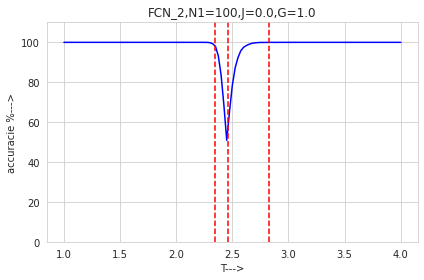

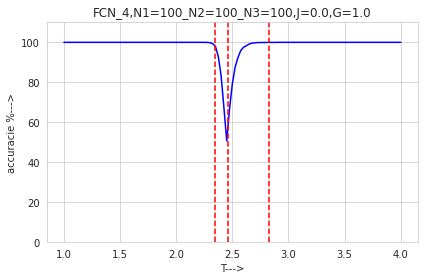

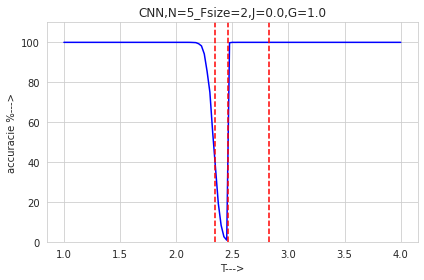

In [57]:
# Plottin all Networks accuriers  for J=0.0,G=1.0 data
import matplotlib.pyplot as plt
import pickle

G_1_J_0_pkl_folder_path = "./G_1_J_0_data_in_pkl_format"
important_parameters_file_name = "important_parameters.pkl"
important_parameters_file_path = os.path.join(G_1_J_0_pkl_folder_path, important_parameters_file_name)
with open(important_parameters_file_path, 'rb') as f:
    important_parameters_dict = pickle.load(f)
    T_list = important_parameters_dict["T_list"]
    T_critical = important_parameters_dict["T_critical"]
    T_low_for_critical = important_parameters_dict["T_low_for_critical"] 
    T_up_for_critical = important_parameters_dict["T_up_for_critical"]

for key in FCN_2.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"FCN_2,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"FCN_2,{key},J=0.0,G=1.0")
    figure_file_name = f"FCN_2,{key},J=0.0,G=1.0.jpg"
    figure_file_path = os.path.join(accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

for key in FCN_4.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"FCN_4,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"FCN_4,{key},J=0.0,G=1.0")
    figure_file_name = f"FCN_4,{key},J=0.0,G=1.0.jpg"
    figure_file_path = os.path.join(accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

for key in CNN.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"CNN,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"CNN,{key},J=0.0,G=1.0")
    figure_file_name = f"CNN,{key},J=0.0,G=1.0.jpg"
    figure_file_path = os.path.join(accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

In [58]:
import pandas as pd

G_1_J_0_pkl_folder_path = "./G_1_J_0_data_in_pkl_format"
important_parameters_file_name = "important_parameters.pkl"
important_parameters_file_path = os.path.join(G_1_J_0_pkl_folder_path, important_parameters_file_name)
with open(important_parameters_file_path, 'rb') as f:
    important_parameters_dict = pickle.load(f)
    T_list = important_parameters_dict["T_list"]
    T_critical = important_parameters_dict["T_critical"]
    T_low_for_critical = important_parameters_dict["T_low_for_critical"] 
    T_up_for_critical = important_parameters_dict["T_up_for_critical"]
    
    
    
critical_accuracies_dict = {}
non_critical_accuracies_dict = {}


accuracies_file_names_list = []
for file_name in os.listdir(accuracies_folder_name):
    if file_name.endswith('.csv'):
        if file_name.find("J=0.0,G=1.0")>=0:
            accuracies_file_names_list.append(file_name)


for accuracy_file_name in accuracies_file_names_list:
    accuracy_file_path = os.path.join(accuracies_folder_name, accuracy_file_name)
    df_all = pd.read_csv(accuracy_file_path, header=0)
    filt = (df_all['T_list'] >= T_low_for_critical) & (df_all['T_list'] <= T_up_for_critical)
    df_critical = df_all[filt]
    df_non_critical = df_all[~filt]
    critical_accuracies_dict[accuracy_file_name[0:-4]] = df_critical["accuracies"].mean()
    non_critical_accuracies_dict[accuracy_file_name[0:-4]] = df_non_critical["accuracies"].mean()

for pair in critical_accuracies_dict.items():
    print("critical accuracy -->",pair)
    
for pair in non_critical_accuracies_dict.items():
    print("non critical accuracy -->",pair)

critical accuracy --> ('FCN_2,N1=100,J=0.0,G=1.0', 90.3585)
critical accuracy --> ('CNN,N=5_Fsize=2,J=0.0,G=1.0', 78.3905)
critical accuracy --> ('FCN_4,N1=100_N2=100_N3=100,J=0.0,G=1.0', 90.38100000000001)
non critical accuracy --> ('FCN_2,N1=100,J=0.0,G=1.0', 99.97756097560973)
non critical accuracy --> ('CNN,N=5_Fsize=2,J=0.0,G=1.0', 97.72756097560975)
non critical accuracy --> ('FCN_4,N1=100_N2=100_N3=100,J=0.0,G=1.0', 99.97756097560975)


In [59]:
Phase_accuracies_df.loc["J=0.0,G=1.0,Critical", "1_layer_DNN"] = critical_accuracies_dict["FCN_2,N1=100,J=0.0,G=1.0"]
Phase_accuracies_df.loc["J=0.0,G=1.0,Critical", "3_layer_DNN"] = critical_accuracies_dict["FCN_4,N1=100_N2=100_N3=100,J=0.0,G=1.0"]
Phase_accuracies_df.loc["J=0.0,G=1.0,Critical", "CNN"] = critical_accuracies_dict["CNN,N=5_Fsize=2,J=0.0,G=1.0"]
Phase_accuracies_df.loc["J=0.0,G=1.0,Non-Critical", "1_layer_DNN"] = non_critical_accuracies_dict["FCN_2,N1=100,J=0.0,G=1.0"]
Phase_accuracies_df.loc["J=0.0,G=1.0,Non-Critical", "3_layer_DNN"] = non_critical_accuracies_dict["FCN_4,N1=100_N2=100_N3=100,J=0.0,G=1.0"]
Phase_accuracies_df.loc["J=0.0,G=1.0,Non-Critical", "CNN"] = non_critical_accuracies_dict["CNN,N=5_Fsize=2,J=0.0,G=1.0"]
Phase_accuracies_df

,Temperature Range,T_c,1_layer_DNN,3_layer_DNN,CNN,1_layer_DNN_FFT,3_layer_DNN_FFT,CNN_FFT
"J=1.0,G=0.0,Critical","[1.000 ,4.000]","[2.325 ,2.350]",88.272353,87.737059,86.338824,NaN,NaN,NaN
"J=1.0,G=0.0,Non-Critical","[1.000 ,4.000]","[2.325 ,2.350]",100.0,100.0,100.0,NaN,NaN,NaN
"J=1.0,G=0.1,Critical","[1.000 ,4.000]","[2.675 ,2.650]",86.888824,86.415882,88.19,NaN,NaN,NaN
"J=1.0,G=0.1,Non-Critical","[1.000 ,4.000]","[2.675 ,2.650]",99.938864,99.940682,99.994773,NaN,NaN,NaN
"J=1.0,G=0.5,Critical","[2.500 ,5.500]","[3.900 ,3.925]",87.3572,86.9792,89.7048,NaN,NaN,NaN
"J=1.0,G=0.5,Non-Critical","[2.500 ,5.500]","[3.900 ,3.925]",99.921389,99.919722,99.934167,NaN,NaN,NaN
"J=0.0,G=1.0,Critical","[1.000 ,4.000]","[2.475 ,2.500]",90.3585,90.381,78.3905,NaN,NaN,NaN
"J=0.0,G=1.0,Non-Critical","[1.000 ,4.000]","[2.475 ,2.500]",99.977561,99.977561,97.727561,NaN,NaN,NaN
"J=1.0,G=1.0,Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=1.0,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Testing the accuracies of all the models  for ordered and disordered datasets of J=1.0 ,G=1.0

In [60]:
%%time
# G = 1.0 , J=1.0 data
# Converting the Raw data with G = 1.0 , J=1.0 into the data type I need (.pkl files)


# Copied mostly from my Data_read_folder_specific.py file with necessory changes  
# -----------------------------------------------------------------------------------
# Parameters
L = 40
T_array = f5_G1_J1['Ts'][:]
G = 1.0
J = 1.0

# folder name for saving the G = 1.0 , J=1.0 data in .pkl format
G_1_J_1_pkl_folder_path = f"G_1_J_1_data_in_pkl_format"
if not os.path.isdir(G_1_J_1_pkl_folder_path):
    os.mkdir(G_1_J_1_pkl_folder_path)

No_configerations_for_each_T = 10000 
for i in trange(T_array.shape[0]):
    T = T_array[i]
    data = f5_G1_J1['arrs'][i,:,:].reshape(-1, L, L).astype("int8")
    
    data_output_file_name = f"configerations_L_{L}_G_{G:.2f}_J_{J:.2f}_T_{T:.6f}_.pkl"
    # print(data_output_file_name)
    path = os.path.join(G_1_J_1_pkl_folder_path, data_output_file_name)
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    
# -----------------------------------------------------------------------------------
# To save space
del data

  0%|          | 0/80 [00:00<?, ?it/s]

CPU times: user 9.79 s, sys: 1.07 s, total: 10.9 s
Wall time: 15 s


5.3625


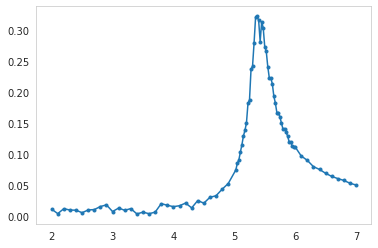

,Temperature Range,T_c,1_layer_DNN,3_layer_DNN,CNN,1_layer_DNN_FFT,3_layer_DNN_FFT,CNN_FFT
"J=1.0,G=0.0,Critical","[1.000 ,4.000]","[2.325 ,2.350]",88.272353,87.737059,86.338824,NaN,NaN,NaN
"J=1.0,G=0.0,Non-Critical","[1.000 ,4.000]","[2.325 ,2.350]",100.0,100.0,100.0,NaN,NaN,NaN
"J=1.0,G=0.1,Critical","[1.000 ,4.000]","[2.675 ,2.650]",86.888824,86.415882,88.19,NaN,NaN,NaN
"J=1.0,G=0.1,Non-Critical","[1.000 ,4.000]","[2.675 ,2.650]",99.938864,99.940682,99.994773,NaN,NaN,NaN
"J=1.0,G=0.5,Critical","[2.500 ,5.500]","[3.900 ,3.925]",87.3572,86.9792,89.7048,NaN,NaN,NaN
"J=1.0,G=0.5,Non-Critical","[2.500 ,5.500]","[3.900 ,3.925]",99.921389,99.919722,99.934167,NaN,NaN,NaN
"J=0.0,G=1.0,Critical","[1.000 ,4.000]","[2.475 ,2.500]",90.3585,90.381,78.3905,NaN,NaN,NaN
"J=0.0,G=1.0,Non-Critical","[1.000 ,4.000]","[2.475 ,2.500]",99.977561,99.977561,97.727561,NaN,NaN,NaN
"J=1.0,G=1.0,Critical","[2.000 ,7.000]","[5.375 ,5.350]",NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=1.0,Non-Critical","[2.000 ,7.000]","[5.375 ,5.350]",NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
#---------------------------------------
#Critical Region: 
#---------------------------------------
Targs=np.arange(80)
xiBs=f5_G1_J1['xiBs'][:]
factor=0.30 # Parameter which determines critical region
cut=np.amax(xiBs)*factor
labels_tmp=np.heaviside(xiBs[Targs]-cut,1.0)
crit_start=np.where(labels_tmp==1.0)[0][0]
crit_end=np.where(labels_tmp==1.0)[0][-1]

#T_c from Chi 
#crit_Temp=(T_array[xiBs.argsort()[-1]]+T_array[xiBs.argsort()[-2]])/2
crit_Temp= 5.3625
###################################

#print(T_array[crit_start])
#print(T_array[crit_end])
#print(T_array[crit_pt])
#print(xiBs.argsort()[-1])
print(crit_Temp)
#---------------------------------------

plt.figure()
plt.plot(T_array,xiBs,".-")
plt.grid()
plt.show()


# --------------------------------------
Phase_accuracies_df.loc["J=1.0,G=1.0,Critical", "Temperature Range"] = f"[{T_array[0]:.3f} ,{T_array[-1]:.3f}]"
Phase_accuracies_df.loc["J=1.0,G=1.0,Non-Critical", "Temperature Range"] = f"[{T_array[0]:.3f} ,{T_array[-1]:.3f}]"
Phase_accuracies_df.loc["J=1.0,G=1.0,Critical", "T_c"] = f"[{T_array[xiBs.argsort()[-1]]:.3f} ,{T_array[xiBs.argsort()[-2]]:.3f}]"
Phase_accuracies_df.loc["J=1.0,G=1.0,Non-Critical", "T_c"] = f"[{T_array[xiBs.argsort()[-1]]:.3f} ,{T_array[xiBs.argsort()[-2]]:.3f}]"
Phase_accuracies_df

In [62]:
%%time
# Creating ordered_partial,disordered_partial,ordered_complete,disordered_complete,critical data .pkl files for J=1.0,G=1.0

No_configerations_for_each_T = 10000 
# Copied mostly from my Analyze_folder_specific.py file with necessory changes  
# -----------------------------------------------------------------------------------
# Parameters that need to be set manually --------------------------------------------------------------<
J = 1.0
G = 1.0
T_critical = crit_Temp # From Chi values
T_low_for_critical = T_array[crit_start] # From XiB values
T_up_for_critical = T_array[crit_end] # From XiB values
print("J = ", J)
print("G = ", G)
print("T_critical = ", T_critical)
print("T_low_for_critical = ", T_low_for_critical)
print("T_up_for_critical = ", T_up_for_critical)
# ------------------------------------------------------------------------------------------------------>

# Saving all the file names into a dictionary called data file name
G_1_J_1_pkl_folder_path = f"./G_1_J_1_data_in_pkl_format"
data_file_names_list = []
for file_name in os.listdir(G_1_J_1_pkl_folder_path):
    if file_name.endswith('.pkl'):
        if file_name.startswith("configerations_"):
            data_file_names_list.append(file_name)

            
# Storing the data into ordered,disordered and critical data sets --------------------------------------<
# Here I have add "X_ordered_partial" and "X_disordered_partial" data sets contains ordered
# and disordered datasets respectively which are not a part of critical dataset
X_ordered_partial = []
X_disordered_partial = []
Y_ordered_partial = []
Y_disordered_partial = []
X_critical = []
Y_critical = []
T_list = []
for configerations_file_name in data_file_names_list:
    configerations_file_path = os.path.join(G_1_J_1_pkl_folder_path,configerations_file_name)
    T = float(configerations_file_name.split("_")[8])
    T_list.append(T)
    with open(configerations_file_path, 'rb') as f:
        configerations = pickle.load(f)

    if T < T_low_for_critical:
        X_ordered_partial.append(configerations)
        Y_ordered_partial.append(np.ones(configerations.shape[0]))
    elif T > T_up_for_critical:
        X_disordered_partial.append(configerations)
        Y_disordered_partial.append(np.zeros(configerations.shape[0]))

    elif (T <= T_up_for_critical) and (T >= T_low_for_critical):
        X_critical.append(configerations)
        if T < T_critical:
            Y_critical.append(np.ones(configerations.shape[0]))
        else:
            Y_critical.append(np.zeros(configerations.shape[0]))


X_ordered_partial = np.concatenate(tuple(X_ordered_partial), axis=0)
Y_ordered_partial = np.concatenate(tuple(Y_ordered_partial), axis=0)
X_disordered_partial = np.concatenate(tuple(X_disordered_partial), axis=0)
Y_disordered_partial = np.concatenate(tuple(Y_disordered_partial), axis=0)
X_critical = np.concatenate(tuple(X_critical), axis=0)
Y_critical = np.concatenate(tuple(Y_critical), axis=0)

# Printing shapes of X and unique values of Y Just to checck every thing is fine
# print("X_ordered_partial shape = ", X_ordered_partial.shape)
# print("X_disordered_partial shape = ", X_disordered_partial.shape)
# print("X_critical shape = ", X_critical.shape)
# print("Y_ordered_partial unique values ", np.unique(
#     Y_ordered_partial, return_counts=True))
# print("Y_disordered_partial unique values ", np.unique(
#     Y_disordered_partial, return_counts=True))
# print("Y_critical unique values ", np.unique(Y_critical, return_counts=True))

X_ordered_partial_file_name = "X_ordered_partial.pkl"
X_ordered_partial_file_path = os.path.join(G_1_J_1_pkl_folder_path,X_ordered_partial_file_name)
X_disordered_partial_file_name = "X_disordered_partial.pkl"
X_disordered_partial_file_path = os.path.join(G_1_J_1_pkl_folder_path,X_disordered_partial_file_name)
X_critical_file_name = "X_critical.pkl"
X_critical_file_path = os.path.join(G_1_J_1_pkl_folder_path,X_critical_file_name)
Y_ordered_partial_file_name = "Y_ordered_partial.pkl"
Y_ordered_partial_file_path = os.path.join(G_1_J_1_pkl_folder_path,Y_ordered_partial_file_name)
Y_disordered_partial_file_name = "Y_disordered_partial.pkl"
Y_disordered_partial_file_path = os.path.join(G_1_J_1_pkl_folder_path,Y_disordered_partial_file_name)
Y_critical_file_name = "Y_critical.pkl"
Y_critical_file_path = os.path.join(G_1_J_1_pkl_folder_path,Y_critical_file_name)

with open(X_ordered_partial_file_path, 'wb') as f:
    pickle.dump(X_ordered_partial, f)

with open(X_disordered_partial_file_path, 'wb') as f:
    pickle.dump(X_disordered_partial, f)

with open(X_critical_file_path, 'wb') as f:
    pickle.dump(X_critical, f)

with open(Y_ordered_partial_file_path, 'wb') as f:
    pickle.dump(Y_ordered_partial, f)

with open(Y_disordered_partial_file_path, 'wb') as f:
    pickle.dump(Y_disordered_partial, f)

with open(Y_critical_file_path, 'wb') as f:
    pickle.dump(Y_critical, f)
# ------------------------------------------------------------------------------------------------------>


# Storing the data into ordered and disordered data sets -----------------------------------------------<
# Here I have add "X_ordered_complete" and "X_disordered_complete" data sets contains ordered
# and disordered datasets respectively which are also included in critical dataset
X_ordered_complete = []
X_disordered_complete = []
Y_ordered_complete = []
Y_disordered_complete = []
for configerations_file_name in data_file_names_list:
    configerations_file_path = os.path.join(G_1_J_1_pkl_folder_path,configerations_file_name)
    T = float(configerations_file_name.split("_")[8])
    with open(configerations_file_path, 'rb') as f:
        configerations = pickle.load(f)

    if T < T_critical:
        X_ordered_complete.append(configerations)
        Y_ordered_complete.append(np.ones(configerations.shape[0]))
    else:
        X_disordered_complete.append(configerations)
        Y_disordered_complete.append(np.zeros(configerations.shape[0]))


X_ordered_complete = np.concatenate(tuple(X_ordered_complete), axis=0)
Y_ordered_complete = np.concatenate(tuple(Y_ordered_complete), axis=0)
X_disordered_complete = np.concatenate(tuple(X_disordered_complete), axis=0)
Y_disordered_complete = np.concatenate(tuple(Y_disordered_complete), axis=0)



# # Printing shapes of X and unique values of Y Just to checck every thing is fine
# print("X_ordered_complete shape = ", X_ordered_complete.shape)
# print("X_disordered_complete shape = ", X_disordered_complete.shape)
# print("Y_ordered_complete unique values ", np.unique(
#     Y_ordered_complete, return_counts=True))
# print("Y_disordered_complete unique values ", np.unique(
#     Y_disordered_complete, return_counts=True))



X_ordered_complete_file_name = "X_ordered_complete.pkl"
X_ordered_complete_file_path = os.path.join(G_1_J_1_pkl_folder_path,X_ordered_complete_file_name)
X_disordered_complete_file_name = "X_disordered_complete.pkl"
X_disordered_complete_file_path = os.path.join(G_1_J_1_pkl_folder_path,X_disordered_complete_file_name)
Y_ordered_complete_file_name = "Y_ordered_complete.pkl"
Y_ordered_complete_file_path = os.path.join(G_1_J_1_pkl_folder_path,Y_ordered_complete_file_name)
Y_disordered_complete_file_name = "Y_disordered_complete.pkl"
Y_disordered_complete_file_path = os.path.join(G_1_J_1_pkl_folder_path,Y_disordered_complete_file_name)

with open(X_ordered_complete_file_path, 'wb') as f:
    pickle.dump(X_ordered_complete, f)

with open(X_disordered_complete_file_path, 'wb') as f:
    pickle.dump(X_disordered_complete, f)

with open(Y_ordered_complete_file_path, 'wb') as f:
    pickle.dump(Y_ordered_complete, f)

with open(Y_disordered_complete_file_path, 'wb') as f:
    pickle.dump(Y_disordered_complete, f)

print()
# ------------------------------------------------------------------------------------------------------>

# Storing all the imporant paramets into a dictionart to be used in future------------------------------<
important_parameters_file_name = "important_parameters.pkl"
important_parameters_dict = {}
important_parameters_dict["J"] = J
important_parameters_dict["G"] = G
T_list.sort()
important_parameters_dict["T_list"] = T_list
important_parameters_dict["T_critical"] = T_critical
important_parameters_dict["T_low_for_critical"] = T_low_for_critical
important_parameters_dict["T_up_for_critical"] = T_up_for_critical
important_parameters_dict["No_configerations_for_each_T"] = No_configerations_for_each_T

important_parameters_file_path = os.path.join(G_1_J_1_pkl_folder_path,important_parameters_file_name)
with open(important_parameters_file_path, 'wb') as f:
    pickle.dump(important_parameters_dict, f)


print()
print("-----printing all the imporant paramets(also stored in the file xxx) into a dictionart to be used in future-----")
print(important_parameters_dict)

# ------------------------------------------------------------------------------------------------------>

# To save space
del X_ordered_partial, X_disordered_partial, Y_ordered_partial 
del Y_disordered_partial, X_critical, Y_critical, X_ordered_complete
del Y_ordered_complete, X_disordered_complete, Y_disordered_complete

J =  1.0
G =  1.0
T_critical =  5.3625
T_low_for_critical =  5.1
T_up_for_critical =  6.1


-----printing all the imporant paramets(also stored in the file xxx) into a dictionart to be used in future-----
{'J': 1.0, 'G': 1.0, 'T_list': [2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.025, 5.05, 5.075, 5.1, 5.125, 5.15, 5.175, 5.2, 5.225, 5.25, 5.275, 5.3, 5.325, 5.35, 5.375, 5.4, 5.425, 5.45, 5.475, 5.5, 5.525, 5.55, 5.575, 5.6, 5.625, 5.65, 5.675, 5.7, 5.725, 5.75, 5.775, 5.8, 5.825, 5.85, 5.875, 5.9, 5.925, 5.95, 5.975, 6.0, 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9, 7.0], 'T_critical': 5.3625, 'T_low_for_critical': 5.1, 'T_up_for_critical': 6.1, 'No_configerations_for_each_T': 10000}
CPU times: user 1.24 s, sys: 6.78 s, total: 8.02 s
Wall time: 18.8 s


## Testing J=0.0, G=1.0 data

In [63]:
class Testing_dataset_G_1_J_1(torch.utils.data.Dataset):
    """Ising pytorch Testing dataset for J=1.0, G=1.0"""

    def __init__(self, data_type, transform=False):
        """
        Args:
            data_type (string): `ordered`, `disordered` : creates data_loader
            transform (callable, optional): Optional transform to be applied on a sample.

        """

        # from sklearn.model_selection import train_test_split
        # import collections
        import pickle
        G_1_J_1_pkl_folder_path = "./G_1_J_1_data_in_pkl_format"

        X_ordered_file_name = "X_ordered_complete.pkl"
        X_ordered_file_path = os.path.join(G_1_J_1_pkl_folder_path, X_ordered_file_name)
        Y_ordered_file_name = "Y_ordered_complete.pkl"
        Y_ordered_file_path = os.path.join(G_1_J_1_pkl_folder_path, Y_ordered_file_name)
        X_disordered_file_name = "X_disordered_complete.pkl"
        X_disordered_file_path = os.path.join(G_1_J_1_pkl_folder_path, X_disordered_file_name)
        Y_disordered_file_name = "Y_disordered_complete.pkl"
        Y_disordered_file_path = os.path.join(G_1_J_1_pkl_folder_path, Y_disordered_file_name)

        with open(X_ordered_file_path, 'rb') as f:
            X_ordered = pickle.load(f)
        with open(Y_ordered_file_path, 'rb') as f:
            Y_ordered = pickle.load(f)
            Y_ordered = np.int64(Y_ordered)
        with open(X_disordered_file_path, 'rb') as f:
            X_disordered = pickle.load(f)
        with open(Y_disordered_file_path, 'rb') as f:
            Y_disordered = pickle.load(f)
            Y_disordered = np.int64(Y_disordered)

        if data_type == 'ordered':
            X = X_ordered
            Y = Y_ordered

        if data_type == 'disordered':
            X = X_disordered
            Y = Y_disordered

        # these are necessary attributes in dataset class and must be assigned
        self.data = (X, Y)
        self.transform = transform

    # override __len__ and __getitem__ of the Dataset() class

    def __len__(self):
        return len(self.data[1])

    def __getitem__(self, idx):

        sample = (self.data[0][idx, ...], self.data[1][idx])
        if self.transform:
            sample = self.transform(sample)

        return sample


def load_testing_dataset_G_1_J_1(kwargs, transform= False):
    # kwargs:  CUDA arguments, if enabled
    # load and noralise train,test, and data
    
    ordered_loader = torch.utils.data.DataLoader(
        Testing_dataset_G_1_J_1(data_type='ordered', transform= transform),
        batch_size=args.test_batch_size, shuffle=False,**kwargs)
    disordered_loader = torch.utils.data.DataLoader(
        Testing_dataset_G_1_J_1(data_type='disordered', transform= transform),
        batch_size=args.test_batch_size, shuffle=False,**kwargs)

    return ordered_loader, disordered_loader

In [64]:
%%time
ordered_loader, disordered_loader = load_testing_dataset_G_1_J_1(cuda_kwargs)

ordered_accuracies_dict = {}
disordered_accuracies_dict = {}

test_criterion = nn.NLLLoss(reduction="mean")


for key in FCN_2.keys():
    print(f"Acuracies of model FCN_2 key={key}")
    testing_model = FCN_2[key]

    if args.cuda:
        testing_model.cuda()
    _, ordered_accuracies_dict["FCN_2_"+key+"_ordered"] = test(ordered_loader, testing_model, verbose='ordered',criterion=test_criterion)
    _, disordered_accuracies_dict["FCN_2_"+key+"_disordered"] = test(disordered_loader, testing_model, verbose='disordered',criterion=test_criterion)

for key in FCN_4.keys():
    print(f"Acuracies of model FCN_4 key={key}")
    testing_model = FCN_4[key]

    if args.cuda:
        testing_model.cuda()
    _, ordered_accuracies_dict["FCN_4_"+key+"_ordered"] = test(ordered_loader, testing_model, verbose='ordered',criterion=test_criterion)
    _, disordered_accuracies_dict["FCN_4_"+key+"_disordered"] = test(disordered_loader, testing_model, verbose='disordered',criterion=test_criterion)

for key in CNN.keys():
    print(f"Acuracies of model CNN key={key}")
    testing_model = CNN[key]

    if args.cuda:
        testing_model.cuda()
    _, ordered_accuracies_dict["CNN_"+key+"_ordered"] = test(ordered_loader, testing_model, verbose='ordered',criterion=test_criterion)
    _, disordered_accuracies_dict["CNN_"+key+"_disordered"] = test(disordered_loader, testing_model, verbose='disordered',criterion=test_criterion)

for pair in ordered_accuracies_dict.items():
    print(pair)
for pair in disordered_accuracies_dict.items():
    print(pair)
    
# print(f"ordered_accuracies_dict = {ordered_accuracies_dict}")
# print(f"disordered_accuracies_dict = {disordered_accuracies_dict}")
          
# To save memory
del ordered_loader, disordered_loader

/opt/conda/lib/python3.7/site-packages/torch/utils/data/dataloader.py:481: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))


Acuracies of model FCN_2 key=N1=100

ordered set: Average loss: 0.2488, Accuracy: 423602/440000 (96%)


disordered set: Average loss: 0.3497, Accuracy: 332849/360000 (92%)

Acuracies of model FCN_4 key=N1=100_N2=100_N3=100

ordered set: Average loss: 0.3202, Accuracy: 424290/440000 (96%)


disordered set: Average loss: 0.5103, Accuracy: 331361/360000 (92%)

Acuracies of model CNN key=N=5_Fsize=2

ordered set: Average loss: 0.7191, Accuracy: 393148/440000 (89%)


disordered set: Average loss: 0.0251, Accuracy: 357396/360000 (99%)

('FCN_2_N1=100_ordered', 96.27318181818181)
('FCN_4_N1=100_N2=100_N3=100_ordered', 96.42954545454545)
('CNN_N=5_Fsize=2_ordered', 89.35181818181819)
('FCN_2_N1=100_disordered', 92.45805555555556)
('FCN_4_N1=100_N2=100_N3=100_disordered', 92.04472222222222)
('CNN_N=5_Fsize=2_disordered', 99.27666666666667)
CPU times: user 4.2 s, sys: 8.26 s, total: 12.5 s
Wall time: 29.2 s


## Calculating the accuracies for Critical and non critical Datasets for J=1.0, G=1.0

In [65]:
class Testing_dataset_G_1_J_1_ver2(torch.utils.data.Dataset):
    """Ising pytorch Testing dataset for J=1.0 , G=1.0"""

    def __init__(self, data_type, transform=False):
        """
        Args:
            data_type (string): f"T_{T:.6f}", Where T is one of the possible Temperatures
            transform (callable, optional): Optional transform to be applied on a sample.

        """

        # from sklearn.model_selection import train_test_split
        # import collections
        import pickle
        G_1_J_1_pkl_folder_path = "./G_1_J_1_data_in_pkl_format"
        important_parameters_file_name = "important_parameters.pkl"
        important_parameters_file_path = os.path.join(
            G_1_J_1_pkl_folder_path, important_parameters_file_name)
        with open(important_parameters_file_path, 'rb') as f:
            important_parameters_dict = pickle.load(f)

        T_critical = important_parameters_dict["T_critical"]
        T_low_for_critical = important_parameters_dict["T_low_for_critical"]  
        T_up_for_critical = important_parameters_dict["T_up_for_critical"]  

        data_file_names_list = []
        for file_name in os.listdir(G_1_J_1_pkl_folder_path):
            if file_name.endswith('.pkl'):
                if file_name.startswith('configerations_'):
                    data_file_names_list.append(file_name)

        X_dict = {}
        Y_dict = {}
        for data_file_name in data_file_names_list:
            T = np.float(data_file_name.split("_")[8])
            data_file_path = os.path.join(
                G_1_J_1_pkl_folder_path, data_file_name)
            with open(data_file_path, 'rb') as f:
                configerations = pickle.load(f)
            X_dict[f"T_{T:.6f}"] = configerations
            if T < T_critical:
                Y_dict[f"T_{T:.6f}"] = np.ones(configerations.shape[0])
                Y_dict[f"T_{T:.6f}"] = np.int64(Y_dict[f"T_{T:.6f}"])
            else:
                Y_dict[f"T_{T:.6f}"] = np.zeros(configerations.shape[0])
                Y_dict[f"T_{T:.6f}"] = np.int64(Y_dict[f"T_{T:.6f}"])

        X = X_dict[data_type]
        Y = Y_dict[data_type]

        # these are necessary attributes in dataset class and must be assigned
        self.data = (X, Y)
        self.transform = transform

    # override __len__ and __getitem__ of the Dataset() class

    def __len__(self):
        return len(self.data[1])

    def __getitem__(self, idx):

        sample = (self.data[0][idx, ...], self.data[1][idx])
        if self.transform:
            sample = self.transform(sample)

        return sample


def load_testing_dataset_G_1_J_1_ver2(kwargs, transform=False):
    # kwargs:  CUDA arguments, if enabled
    # load and noralise train,test, and data
    import pickle
    G_1_J_1_pkl_folder_path = "./G_1_J_1_data_in_pkl_format"
    important_parameters_file_name = "important_parameters.pkl"
    important_parameters_file_path = os.path.join(
        G_1_J_1_pkl_folder_path, important_parameters_file_name)
    with open(important_parameters_file_path, 'rb') as f:
        important_parameters_dict = pickle.load(f)
#     T_critical = important_parameters_dict["T_critical"]
    T_list = important_parameters_dict["T_list"]
#     No_configerations_for_each_T = important_parameters_dict["No_configerations_for_each_T"]

    data_loader_dict = {}
    for T in T_list:
        data_loader_dict[f"T_{T:.6f}"] = torch.utils.data.DataLoader(Testing_dataset_G_1_J_1_ver2(
            data_type=f"T_{T:.6f}", transform=transform), batch_size=args.test_batch_size, shuffle=False, **kwargs)

    return data_loader_dict

In [66]:
%%time
data_loader_dict = load_testing_dataset_G_1_J_1_ver2(cuda_kwargs)

accuracies_dict = {}

test_criterion = nn.NLLLoss(reduction="mean")

for key in FCN_2.keys():
    testing_model = FCN_2[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"FCN_2,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"FCN_2,{key},{T_key}",criterion=test_criterion)


for key in FCN_4.keys():
    testing_model = FCN_4[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"FCN_4,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"FCN_4,{key},{T_key}",criterion=test_criterion)

for key in CNN.keys():
    testing_model = CNN[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"CNN,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"CNN,{key},{T_key}",criterion=test_criterion)


for pair in accuracies_dict.items():
    print(pair)

# print(f"accuracies_dict = {accuracies_dict}")
# To save memory
del data_loader_dict


FCN_2,N1=100,T_2.000000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.100000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.200000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.300000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.400000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.500000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.600000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.700000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.800000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.900000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_3.000000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_3.100000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_

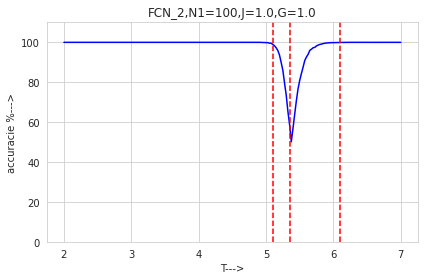

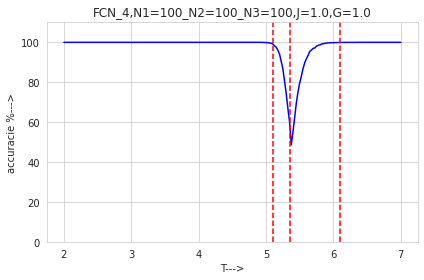

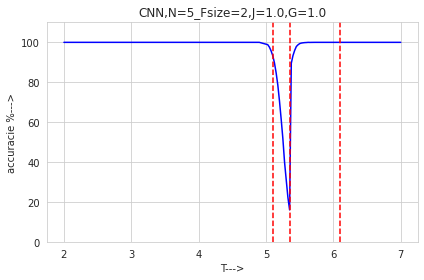

In [67]:
# Plottin all Networks accuriers  for J=1.0,G=1.0 data
import matplotlib.pyplot as plt
import pickle

G_1_J_1_pkl_folder_path = "./G_1_J_1_data_in_pkl_format"
important_parameters_file_name = "important_parameters.pkl"
important_parameters_file_path = os.path.join(G_1_J_1_pkl_folder_path, important_parameters_file_name)
with open(important_parameters_file_path, 'rb') as f:
    important_parameters_dict = pickle.load(f)
    T_list = important_parameters_dict["T_list"]
    T_critical = important_parameters_dict["T_critical"]
    T_low_for_critical = important_parameters_dict["T_low_for_critical"] 
    T_up_for_critical = important_parameters_dict["T_up_for_critical"]

for key in FCN_2.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"FCN_2,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"FCN_2,{key},J=1.0,G=1.0")
    figure_file_name = f"FCN_2,{key},J=1.0,G=1.0.jpg"
    figure_file_path = os.path.join(accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

for key in FCN_4.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"FCN_4,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"FCN_4,{key},J=1.0,G=1.0")
    figure_file_name = f"FCN_4,{key},J=1.0,G=1.0.jpg"
    figure_file_path = os.path.join(accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

for key in CNN.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"CNN,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"CNN,{key},J=1.0,G=1.0")
    figure_file_name = f"CNN,{key},J=1.0,G=1.0.jpg"
    figure_file_path = os.path.join(accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

In [68]:
import pandas as pd

G_1_J_1_pkl_folder_path = "./G_1_J_1_data_in_pkl_format"
important_parameters_file_name = "important_parameters.pkl"
important_parameters_file_path = os.path.join(G_1_J_1_pkl_folder_path, important_parameters_file_name)
with open(important_parameters_file_path, 'rb') as f:
    important_parameters_dict = pickle.load(f)
    T_list = important_parameters_dict["T_list"]
    T_critical = important_parameters_dict["T_critical"]
    T_low_for_critical = important_parameters_dict["T_low_for_critical"] 
    T_up_for_critical = important_parameters_dict["T_up_for_critical"]
    
    
    
critical_accuracies_dict = {}
non_critical_accuracies_dict = {}


accuracies_file_names_list = []
for file_name in os.listdir(accuracies_folder_name):
    if file_name.endswith('.csv'):
        if file_name.find("J=1.0,G=1.0")>=0:
            accuracies_file_names_list.append(file_name)


for accuracy_file_name in accuracies_file_names_list:
    accuracy_file_path = os.path.join(accuracies_folder_name, accuracy_file_name)
    df_all = pd.read_csv(accuracy_file_path, header=0)
    filt = (df_all['T_list'] >= T_low_for_critical) & (df_all['T_list'] <= T_up_for_critical)
    df_critical = df_all[filt]
    df_non_critical = df_all[~filt]
    critical_accuracies_dict[accuracy_file_name[0:-4]] = df_critical["accuracies"].mean()
    non_critical_accuracies_dict[accuracy_file_name[0:-4]] = df_non_critical["accuracies"].mean()

for pair in critical_accuracies_dict.items():
    print("critical accuracy -->",pair)
    
for pair in non_critical_accuracies_dict.items():
    print("non critical accuracy -->",pair)

critical accuracy --> ('FCN_2,N1=100,J=1.0,G=1.0', 88.2591891891892)
critical accuracy --> ('FCN_4,N1=100_N2=100_N3=100,J=1.0,G=1.0', 88.04135135135135)
critical accuracy --> ('CNN,N=5_Fsize=2,J=1.0,G=1.0', 86.84405405405407)
non critical accuracy --> ('FCN_2,N1=100,J=1.0,G=1.0', 99.97488372093024)
non critical accuracy --> ('FCN_4,N1=100_N2=100_N3=100,J=1.0,G=1.0', 99.97627906976743)
non critical accuracy --> ('CNN,N=5_Fsize=2,J=1.0,G=1.0', 99.8188372093023)


In [69]:
Phase_accuracies_df.loc["J=1.0,G=1.0,Critical", "1_layer_DNN"] = critical_accuracies_dict["FCN_2,N1=100,J=1.0,G=1.0"]
Phase_accuracies_df.loc["J=1.0,G=1.0,Critical", "3_layer_DNN"] = critical_accuracies_dict["FCN_4,N1=100_N2=100_N3=100,J=1.0,G=1.0"]
Phase_accuracies_df.loc["J=1.0,G=1.0,Critical", "CNN"] = critical_accuracies_dict["CNN,N=5_Fsize=2,J=1.0,G=1.0"]
Phase_accuracies_df.loc["J=1.0,G=1.0,Non-Critical", "1_layer_DNN"] = non_critical_accuracies_dict["FCN_2,N1=100,J=1.0,G=1.0"]
Phase_accuracies_df.loc["J=1.0,G=1.0,Non-Critical", "3_layer_DNN"] = non_critical_accuracies_dict["FCN_4,N1=100_N2=100_N3=100,J=1.0,G=1.0"]
Phase_accuracies_df.loc["J=1.0,G=1.0,Non-Critical", "CNN"] = non_critical_accuracies_dict["CNN,N=5_Fsize=2,J=1.0,G=1.0"]
Phase_accuracies_df

,Temperature Range,T_c,1_layer_DNN,3_layer_DNN,CNN,1_layer_DNN_FFT,3_layer_DNN_FFT,CNN_FFT
"J=1.0,G=0.0,Critical","[1.000 ,4.000]","[2.325 ,2.350]",88.272353,87.737059,86.338824,NaN,NaN,NaN
"J=1.0,G=0.0,Non-Critical","[1.000 ,4.000]","[2.325 ,2.350]",100.0,100.0,100.0,NaN,NaN,NaN
"J=1.0,G=0.1,Critical","[1.000 ,4.000]","[2.675 ,2.650]",86.888824,86.415882,88.19,NaN,NaN,NaN
"J=1.0,G=0.1,Non-Critical","[1.000 ,4.000]","[2.675 ,2.650]",99.938864,99.940682,99.994773,NaN,NaN,NaN
"J=1.0,G=0.5,Critical","[2.500 ,5.500]","[3.900 ,3.925]",87.3572,86.9792,89.7048,NaN,NaN,NaN
"J=1.0,G=0.5,Non-Critical","[2.500 ,5.500]","[3.900 ,3.925]",99.921389,99.919722,99.934167,NaN,NaN,NaN
"J=0.0,G=1.0,Critical","[1.000 ,4.000]","[2.475 ,2.500]",90.3585,90.381,78.3905,NaN,NaN,NaN
"J=0.0,G=1.0,Non-Critical","[1.000 ,4.000]","[2.475 ,2.500]",99.977561,99.977561,97.727561,NaN,NaN,NaN
"J=1.0,G=1.0,Critical","[2.000 ,7.000]","[5.375 ,5.350]",88.259189,88.041351,86.844054,NaN,NaN,NaN
"J=1.0,G=1.0,Non-Critical","[2.000 ,7.000]","[5.375 ,5.350]",99.974884,99.976279,99.818837,NaN,NaN,NaN


# <span style="color:Green">Testing on Shuffled data</span>: 

In [70]:
import pandas as pd

columns = ["1_layer_DNN", "3_layer_DNN", "CNN","1_layer_DNN_FFT", "3_layer_DNN_FFT", "CNN_FFT"]
index = ["J=1.0,G=0.0,Critical", "J=1.0,G=0.0,Non-Critical", "J=1.0,G=0.1,Critical","J=1.0,G=0.1,Non-Critical", "J=1.0,G=0.5,Critical", "J=1.0,G=0.5,Non-Critical"]
Phase_accuracies_shuffled_df = pd.DataFrame(None, index=index, columns=columns)

print(Phase_accuracies_shuffled_df.loc["J=1.0,G=0.0,Critical", "1_layer_DNN"])
Phase_accuracies_shuffled_df

nan


,1_layer_DNN,3_layer_DNN,CNN,1_layer_DNN_FFT,3_layer_DNN_FFT,CNN_FFT
"J=1.0,G=0.0,Critical",NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.0,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.1,Critical",NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.1,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.5,Critical",NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.5,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN


In [71]:
shuffled_accuracies_folder_name = "shuffled_accuracies_for_Models_trained_on_non_critical_data"

if not os.path.isdir(shuffled_accuracies_folder_name):
    os.mkdir(shuffled_accuracies_folder_name)

# G = 0.0

In [72]:
%%time
data_loader_dict = load_testing_dataset_g_0_ver2(cuda_kwargs, transform=Random_shuffle_Transform())

accuracies_dict = {}

test_criterion = nn.NLLLoss(reduction="mean")

for key in FCN_2.keys():
    testing_model = FCN_2[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"FCN_2,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"FCN_2,{key},{T_key}",criterion=test_criterion)


for key in FCN_4.keys():
    testing_model = FCN_4[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"FCN_4,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"FCN_4,{key},{T_key}",criterion=test_criterion)

for key in CNN.keys():
    testing_model = CNN[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"CNN,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"CNN,{key},{T_key}",criterion=test_criterion)


for pair in accuracies_dict.items():
    print(pair)

# print(f"accuracies_dict = {accuracies_dict}")
# To save memory
del data_loader_dict

/opt/conda/lib/python3.7/site-packages/torch/utils/data/dataloader.py:481: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))



FCN_2,N1=100,T_1.000000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.100000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.200000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.300000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.400000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.500000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.600000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.700000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.800000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.900000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.000000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.025000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_

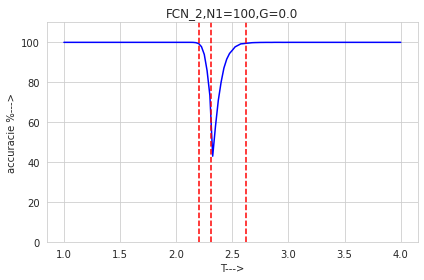

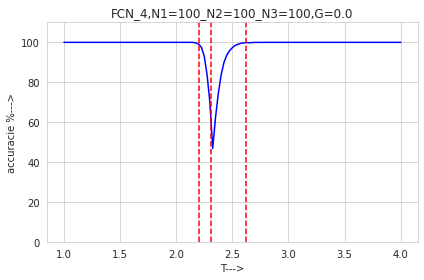

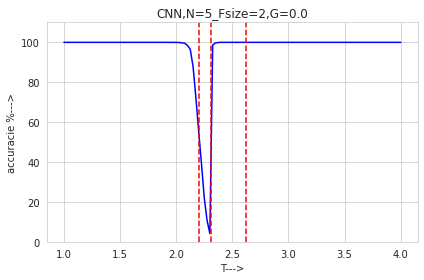

In [73]:
# Plottin all Networks accuriers  for g=0.0 data
import matplotlib.pyplot as plt
import pickle

G_0_pkl_data_folder_path = "./G_0_data_in_pkl_format"
important_parameters_file_name = "important_parameters.pkl"
important_parameters_file_path = os.path.join(G_0_pkl_data_folder_path, important_parameters_file_name)
with open(important_parameters_file_path, 'rb') as f:
    important_parameters_dict = pickle.load(f)
    T_list = important_parameters_dict["T_list"]
    T_critical = important_parameters_dict["T_critical"]
    T_low_for_critical = important_parameters_dict["T_low_for_critical"] 
    T_up_for_critical = important_parameters_dict["T_up_for_critical"]

for key in FCN_2.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"FCN_2,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"FCN_2,{key},G=0.0")
    figure_file_name = f"FCN_2,{key},G=0.0.jpg"
    figure_file_path = os.path.join(shuffled_accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

for key in FCN_4.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"FCN_4,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"FCN_4,{key},G=0.0")
    figure_file_name = f"FCN_4,{key},G=0.0.jpg"
    figure_file_path = os.path.join(shuffled_accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

for key in CNN.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"CNN,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"CNN,{key},G=0.0")
    figure_file_name = f"CNN,{key},G=0.0.jpg"
    figure_file_path = os.path.join(shuffled_accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

In [74]:
import pandas as pd

G_0_pkl_data_folder_path = "./G_0_data_in_pkl_format"
important_parameters_file_name = "important_parameters.pkl"
important_parameters_file_path = os.path.join(G_0_pkl_data_folder_path, important_parameters_file_name)
with open(important_parameters_file_path, 'rb') as f:
    important_parameters_dict = pickle.load(f)
    T_list = important_parameters_dict["T_list"]
    T_critical = important_parameters_dict["T_critical"]
    T_low_for_critical = important_parameters_dict["T_low_for_critical"] 
    T_up_for_critical = important_parameters_dict["T_up_for_critical"]
    
    
    
critical_accuracies_dict = {}
non_critical_accuracies_dict = {}


accuracies_file_names_list = []
for file_name in os.listdir(shuffled_accuracies_folder_name):
    if file_name.endswith('.csv'):
        if file_name.find("G=0.0")>=0:
            accuracies_file_names_list.append(file_name)


for accuracy_file_name in accuracies_file_names_list:
    accuracy_file_path = os.path.join(shuffled_accuracies_folder_name, accuracy_file_name)
    df_all = pd.read_csv(accuracy_file_path, header=0)
    filt = (df_all['T_list'] >= T_low_for_critical) & (df_all['T_list'] <= T_up_for_critical)
    df_critical = df_all[filt]
    df_non_critical = df_all[~filt]
    critical_accuracies_dict[accuracy_file_name[0:-4]] = df_critical["accuracies"].mean()
    non_critical_accuracies_dict[accuracy_file_name[0:-4]] = df_non_critical["accuracies"].mean()

for pair in critical_accuracies_dict.items():
    print("critical accuracy -->",pair)
    
for pair in non_critical_accuracies_dict.items():
    print("non critical accuracy -->",pair)



critical accuracy --> ('CNN,N=5_Fsize=2,G=0.0', 80.84058823529412)
critical accuracy --> ('FCN_2,N1=100,G=0.0', 86.2570588235294)
critical accuracy --> ('FCN_4,N1=100_N2=100_N3=100,G=0.0', 87.30529411764707)
non critical accuracy --> ('CNN,N=5_Fsize=2,G=0.0', 97.95931818181818)
non critical accuracy --> ('FCN_2,N1=100,G=0.0', 99.96181818181817)
non critical accuracy --> ('FCN_4,N1=100_N2=100_N3=100,G=0.0', 99.96340909090908)


In [75]:
Phase_accuracies_shuffled_df.loc["J=1.0,G=0.0,Critical", "1_layer_DNN"] = critical_accuracies_dict["FCN_2,N1=100,G=0.0"]
Phase_accuracies_shuffled_df.loc["J=1.0,G=0.0,Critical", "3_layer_DNN"] = critical_accuracies_dict["FCN_4,N1=100_N2=100_N3=100,G=0.0"]
Phase_accuracies_shuffled_df.loc["J=1.0,G=0.0,Critical", "CNN"] = critical_accuracies_dict["CNN,N=5_Fsize=2,G=0.0"]
Phase_accuracies_shuffled_df.loc["J=1.0,G=0.0,Non-Critical", "1_layer_DNN"] = non_critical_accuracies_dict["FCN_2,N1=100,G=0.0"]
Phase_accuracies_shuffled_df.loc["J=1.0,G=0.0,Non-Critical", "3_layer_DNN"] = non_critical_accuracies_dict["FCN_4,N1=100_N2=100_N3=100,G=0.0"]
Phase_accuracies_shuffled_df.loc["J=1.0,G=0.0,Non-Critical", "CNN"] = non_critical_accuracies_dict["CNN,N=5_Fsize=2,G=0.0"]
Phase_accuracies_shuffled_df

,1_layer_DNN,3_layer_DNN,CNN,1_layer_DNN_FFT,3_layer_DNN_FFT,CNN_FFT
"J=1.0,G=0.0,Critical",86.257059,87.305294,80.840588,NaN,NaN,NaN
"J=1.0,G=0.0,Non-Critical",99.961818,99.963409,97.959318,NaN,NaN,NaN
"J=1.0,G=0.1,Critical",NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.1,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.5,Critical",NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.5,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN


# G = 0.1

In [76]:
%%time
data_loader_dict = load_testing_dataset_g_0_1_ver2(cuda_kwargs, transform=Random_shuffle_Transform())

accuracies_dict = {}

test_criterion = nn.NLLLoss(reduction="mean")

for key in FCN_2.keys():
    testing_model = FCN_2[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"FCN_2,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"FCN_2,{key},{T_key}",criterion=test_criterion)


for key in FCN_4.keys():
    testing_model = FCN_4[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"FCN_4,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"FCN_4,{key},{T_key}",criterion=test_criterion)

for key in CNN.keys():
    testing_model = CNN[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"CNN,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"CNN,{key},{T_key}",criterion=test_criterion)


for pair in accuracies_dict.items():
    print(pair)

# print(f"accuracies_dict = {accuracies_dict}")
# To save memory
del data_loader_dict

/opt/conda/lib/python3.7/site-packages/torch/utils/data/dataloader.py:481: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))



FCN_2,N1=100,T_1.000000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.100000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.200000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.300000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.400000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.500000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.600000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.700000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.800000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.900000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.000000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.025000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_

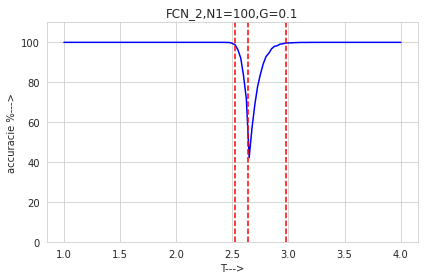

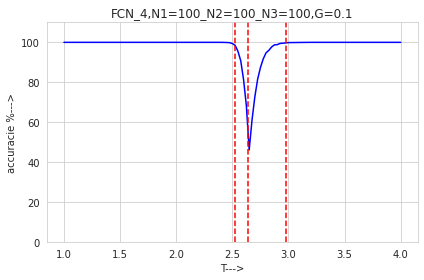

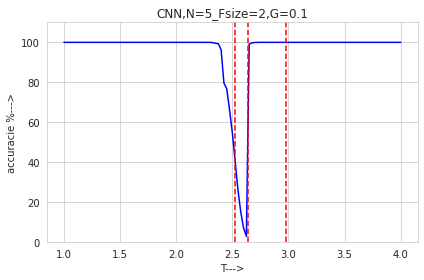

In [77]:
# Plottin all Networks accuriers  for g=0.1 data
import matplotlib.pyplot as plt
import pickle

G_0_1_pkl_data_folder_path = "./G_0.1_data_in_pkl_format"
important_parameters_file_name = "important_parameters.pkl"
important_parameters_file_path = os.path.join(G_0_1_pkl_data_folder_path, important_parameters_file_name)
with open(important_parameters_file_path, 'rb') as f:
    important_parameters_dict = pickle.load(f)
    T_list = important_parameters_dict["T_list"]
    T_critical = important_parameters_dict["T_critical"]
    T_low_for_critical = important_parameters_dict["T_low_for_critical"] 
    T_up_for_critical = important_parameters_dict["T_up_for_critical"]

for key in FCN_2.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"FCN_2,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"FCN_2,{key},G=0.1")
    figure_file_name = f"FCN_2,{key},G=0.1.jpg"
    figure_file_path = os.path.join(shuffled_accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

for key in FCN_4.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"FCN_4,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"FCN_4,{key},G=0.1")
    figure_file_name = f"FCN_4,{key},G=0.1.jpg"
    figure_file_path = os.path.join(shuffled_accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

for key in CNN.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"CNN,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"CNN,{key},G=0.1")
    figure_file_name = f"CNN,{key},G=0.1.jpg"
    figure_file_path = os.path.join(shuffled_accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

In [78]:
import pandas as pd

G_0_1_pkl_data_folder_path = "./G_0.1_data_in_pkl_format"
important_parameters_file_name = "important_parameters.pkl"
important_parameters_file_path = os.path.join(G_0_1_pkl_data_folder_path, important_parameters_file_name)
with open(important_parameters_file_path, 'rb') as f:
    important_parameters_dict = pickle.load(f)
    T_list = important_parameters_dict["T_list"]
    T_critical = important_parameters_dict["T_critical"]
    T_low_for_critical = important_parameters_dict["T_low_for_critical"] 
    T_up_for_critical = important_parameters_dict["T_up_for_critical"]
    
    
    
critical_accuracies_dict = {}
non_critical_accuracies_dict = {}


accuracies_file_names_list = []
for file_name in os.listdir(shuffled_accuracies_folder_name):
    if file_name.endswith('.csv'):
        if file_name.find("G=0.1")>=0:
            accuracies_file_names_list.append(file_name)


for accuracy_file_name in accuracies_file_names_list:
    accuracy_file_path = os.path.join(shuffled_accuracies_folder_name, accuracy_file_name)
    df_all = pd.read_csv(accuracy_file_path, header=0)
    filt = (df_all['T_list'] >= T_low_for_critical) & (df_all['T_list'] <= T_up_for_critical)
    df_critical = df_all[filt]
    df_non_critical = df_all[~filt]
    critical_accuracies_dict[accuracy_file_name[0:-4]] = df_critical["accuracies"].mean()
    non_critical_accuracies_dict[accuracy_file_name[0:-4]] = df_non_critical["accuracies"].mean()

for pair in critical_accuracies_dict.items():
    print("critical accuracy -->",pair)
    
for pair in non_critical_accuracies_dict.items():
    print("non critical accuracy -->",pair)



critical accuracy --> ('FCN_4,N1=100_N2=100_N3=100,G=0.1', 85.91529411764705)
critical accuracy --> ('FCN_2,N1=100,G=0.1', 84.75647058823527)
critical accuracy --> ('CNN,N=5_Fsize=2,G=0.1', 79.37294117647059)
non critical accuracy --> ('FCN_4,N1=100_N2=100_N3=100,G=0.1', 99.93522727272726)
non critical accuracy --> ('FCN_2,N1=100,G=0.1', 99.93954545454545)
non critical accuracy --> ('CNN,N=5_Fsize=2,G=0.1', 95.7440909090909)


In [79]:
Phase_accuracies_shuffled_df.loc["J=1.0,G=0.1,Critical", "1_layer_DNN"] = critical_accuracies_dict["FCN_2,N1=100,G=0.1"]
Phase_accuracies_shuffled_df.loc["J=1.0,G=0.1,Critical", "3_layer_DNN"] = critical_accuracies_dict["FCN_4,N1=100_N2=100_N3=100,G=0.1"]
Phase_accuracies_shuffled_df.loc["J=1.0,G=0.1,Critical", "CNN"] = critical_accuracies_dict["CNN,N=5_Fsize=2,G=0.1"]
Phase_accuracies_shuffled_df.loc["J=1.0,G=0.1,Non-Critical", "1_layer_DNN"] = non_critical_accuracies_dict["FCN_2,N1=100,G=0.1"]
Phase_accuracies_shuffled_df.loc["J=1.0,G=0.1,Non-Critical", "3_layer_DNN"] = non_critical_accuracies_dict["FCN_4,N1=100_N2=100_N3=100,G=0.1"]
Phase_accuracies_shuffled_df.loc["J=1.0,G=0.1,Non-Critical", "CNN"] = non_critical_accuracies_dict["CNN,N=5_Fsize=2,G=0.1"]
Phase_accuracies_shuffled_df

,1_layer_DNN,3_layer_DNN,CNN,1_layer_DNN_FFT,3_layer_DNN_FFT,CNN_FFT
"J=1.0,G=0.0,Critical",86.257059,87.305294,80.840588,NaN,NaN,NaN
"J=1.0,G=0.0,Non-Critical",99.961818,99.963409,97.959318,NaN,NaN,NaN
"J=1.0,G=0.1,Critical",84.756471,85.915294,79.372941,NaN,NaN,NaN
"J=1.0,G=0.1,Non-Critical",99.939545,99.935227,95.744091,NaN,NaN,NaN
"J=1.0,G=0.5,Critical",NaN,NaN,NaN,NaN,NaN,NaN
"J=1.0,G=0.5,Non-Critical",NaN,NaN,NaN,NaN,NaN,NaN


# G = 0.5

In [80]:
%%time
data_loader_dict = load_testing_dataset_g_0_5_ver2(cuda_kwargs, transform=Random_shuffle_Transform())

accuracies_dict = {}

test_criterion = nn.NLLLoss(reduction="mean")

for key in FCN_2.keys():
    testing_model = FCN_2[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"FCN_2,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"FCN_2,{key},{T_key}",criterion=test_criterion)


for key in FCN_4.keys():
    testing_model = FCN_4[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"FCN_4,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"FCN_4,{key},{T_key}",criterion=test_criterion)

for key in CNN.keys():
    testing_model = CNN[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"CNN,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"CNN,{key},{T_key}",criterion=test_criterion)


for pair in accuracies_dict.items():
    print(pair)

# print(f"accuracies_dict = {accuracies_dict}")
# To save memory
del data_loader_dict

/opt/conda/lib/python3.7/site-packages/torch/utils/data/dataloader.py:481: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))



FCN_2,N1=100,T_2.500000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.600000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.700000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.800000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.900000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_3.000000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_3.100000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_3.200000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_3.300000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_3.400000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_3.500000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_3.525000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_

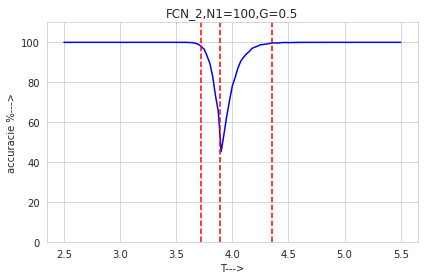

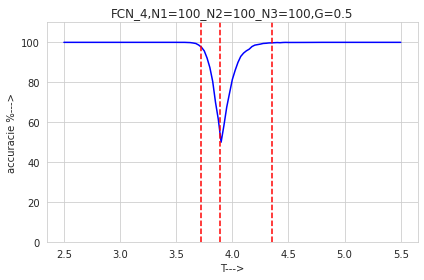

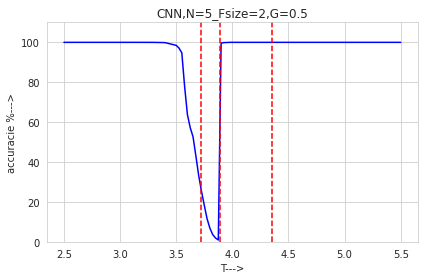

In [81]:
# Plottin all Networks accuriers  for g=0.5 data
import matplotlib.pyplot as plt
import pickle

G_0_5_pkl_data_folder_path = "./G_0.5_data_in_pkl_format"
important_parameters_file_name = "important_parameters.pkl"
important_parameters_file_path = os.path.join(G_0_5_pkl_data_folder_path, important_parameters_file_name)
with open(important_parameters_file_path, 'rb') as f:
    important_parameters_dict = pickle.load(f)
    T_list = important_parameters_dict["T_list"]
    T_critical = important_parameters_dict["T_critical"]
    T_low_for_critical = important_parameters_dict["T_low_for_critical"] 
    T_up_for_critical = important_parameters_dict["T_up_for_critical"]

for key in FCN_2.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"FCN_2,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"FCN_2,{key},G=0.5")
    figure_file_name = f"FCN_2,{key},G=0.5.jpg"
    figure_file_path = os.path.join(shuffled_accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

for key in FCN_4.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"FCN_4,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"FCN_4,{key},G=0.5")
    figure_file_name = f"FCN_4,{key},G=0.5.jpg"
    figure_file_path = os.path.join(shuffled_accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

for key in CNN.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"CNN,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"CNN,{key},G=0.5")
    figure_file_name = f"CNN,{key},G=0.5.jpg"
    figure_file_path = os.path.join(shuffled_accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

In [82]:
import pandas as pd

G_0_5_pkl_data_folder_path = "./G_0.5_data_in_pkl_format"
important_parameters_file_name = "important_parameters.pkl"
important_parameters_file_path = os.path.join(G_0_5_pkl_data_folder_path, important_parameters_file_name)
with open(important_parameters_file_path, 'rb') as f:
    important_parameters_dict = pickle.load(f)
    T_list = important_parameters_dict["T_list"]
    T_critical = important_parameters_dict["T_critical"]
    T_low_for_critical = important_parameters_dict["T_low_for_critical"] 
    T_up_for_critical = important_parameters_dict["T_up_for_critical"]
    
    
    
critical_accuracies_dict = {}
non_critical_accuracies_dict = {}


accuracies_file_names_list = []
for file_name in os.listdir(shuffled_accuracies_folder_name):
    if file_name.endswith('.csv'):
        if file_name.find("G=0.5")>=0:
            accuracies_file_names_list.append(file_name)


for accuracy_file_name in accuracies_file_names_list:
    accuracy_file_path = os.path.join(shuffled_accuracies_folder_name, accuracy_file_name)
    df_all = pd.read_csv(accuracy_file_path, header=0)
    filt = (df_all['T_list'] >= T_low_for_critical) & (df_all['T_list'] <= T_up_for_critical)
    df_critical = df_all[filt]
    df_non_critical = df_all[~filt]
    critical_accuracies_dict[accuracy_file_name[0:-4]] = df_critical["accuracies"].mean()
    non_critical_accuracies_dict[accuracy_file_name[0:-4]] = df_non_critical["accuracies"].mean()

for pair in critical_accuracies_dict.items():
    print("critical accuracy -->",pair)
    
for pair in non_critical_accuracies_dict.items():
    print("non critical accuracy -->",pair)

critical accuracy --> ('FCN_4,N1=100_N2=100_N3=100,G=0.5', 86.6004)
critical accuracy --> ('CNN,N=5_Fsize=2,G=0.5', 74.7192)
critical accuracy --> ('FCN_2,N1=100,G=0.5', 85.61240000000002)
non critical accuracy --> ('FCN_4,N1=100_N2=100_N3=100,G=0.5', 99.90555555555557)
non critical accuracy --> ('CNN,N=5_Fsize=2,G=0.5', 92.16972222222222)
non critical accuracy --> ('FCN_2,N1=100,G=0.5', 99.90444444444444)


In [83]:
Phase_accuracies_shuffled_df.loc["J=1.0,G=0.5,Critical", "1_layer_DNN"] = critical_accuracies_dict["FCN_2,N1=100,G=0.5"]
Phase_accuracies_shuffled_df.loc["J=1.0,G=0.5,Critical", "3_layer_DNN"] = critical_accuracies_dict["FCN_4,N1=100_N2=100_N3=100,G=0.5"]
Phase_accuracies_shuffled_df.loc["J=1.0,G=0.5,Critical", "CNN"] = critical_accuracies_dict["CNN,N=5_Fsize=2,G=0.5"]
Phase_accuracies_shuffled_df.loc["J=1.0,G=0.5,Non-Critical", "1_layer_DNN"] = non_critical_accuracies_dict["FCN_2,N1=100,G=0.5"]
Phase_accuracies_shuffled_df.loc["J=1.0,G=0.5,Non-Critical", "3_layer_DNN"] = non_critical_accuracies_dict["FCN_4,N1=100_N2=100_N3=100,G=0.5"]
Phase_accuracies_shuffled_df.loc["J=1.0,G=0.5,Non-Critical", "CNN"] = non_critical_accuracies_dict["CNN,N=5_Fsize=2,G=0.5"]
Phase_accuracies_shuffled_df

,1_layer_DNN,3_layer_DNN,CNN,1_layer_DNN_FFT,3_layer_DNN_FFT,CNN_FFT
"J=1.0,G=0.0,Critical",86.257059,87.305294,80.840588,NaN,NaN,NaN
"J=1.0,G=0.0,Non-Critical",99.961818,99.963409,97.959318,NaN,NaN,NaN
"J=1.0,G=0.1,Critical",84.756471,85.915294,79.372941,NaN,NaN,NaN
"J=1.0,G=0.1,Non-Critical",99.939545,99.935227,95.744091,NaN,NaN,NaN
"J=1.0,G=0.5,Critical",85.6124,86.6004,74.7192,NaN,NaN,NaN
"J=1.0,G=0.5,Non-Critical",99.904444,99.905556,92.169722,NaN,NaN,NaN


# J=0.0 , G= 1.0

In [84]:
%%time
data_loader_dict = load_testing_dataset_G_1_J_0_ver2(cuda_kwargs, transform=Random_shuffle_Transform())

accuracies_dict = {}

test_criterion = nn.NLLLoss(reduction="mean")

for key in FCN_2.keys():
    testing_model = FCN_2[key]

    if args.cuda:
        testing_model.cuda()
        
    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"FCN_2,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"FCN_2,{key},{T_key}",criterion=test_criterion)


for key in FCN_4.keys():
    testing_model = FCN_4[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"FCN_4,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"FCN_4,{key},{T_key}",criterion=test_criterion)

for key in CNN.keys():
    testing_model = CNN[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"CNN,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"CNN,{key},{T_key}",criterion=test_criterion)


for pair in accuracies_dict.items():
    print(pair)

# print(f"accuracies_dict = {accuracies_dict}")
# To save memory
del data_loader_dict

/opt/conda/lib/python3.7/site-packages/torch/utils/data/dataloader.py:481: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))



FCN_2,N1=100,T_1.000000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.100000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.200000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.300000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.400000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.500000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.600000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.700000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.800000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_1.900000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.000000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.025000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_

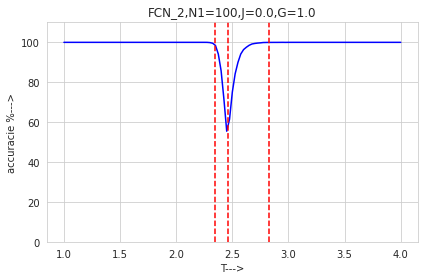

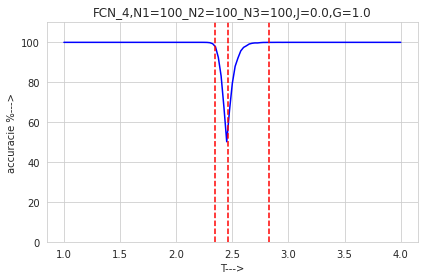

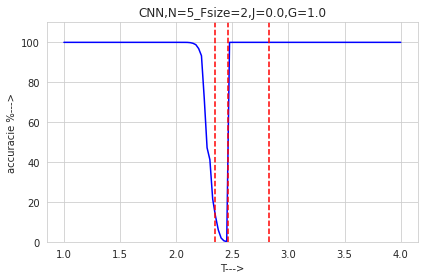

In [85]:
# Plottin all Networks accuriers  for J=0.0 , G=1.0 data
import matplotlib.pyplot as plt
import pickle

G_1_J_0_pkl_folder_path = "./G_1_J_0_data_in_pkl_format"
important_parameters_file_name = "important_parameters.pkl"
important_parameters_file_path = os.path.join(G_1_J_0_pkl_folder_path, important_parameters_file_name)
with open(important_parameters_file_path, 'rb') as f:
    important_parameters_dict = pickle.load(f)
    T_list = important_parameters_dict["T_list"]
    T_critical = important_parameters_dict["T_critical"]
    T_low_for_critical = important_parameters_dict["T_low_for_critical"] 
    T_up_for_critical = important_parameters_dict["T_up_for_critical"]

for key in FCN_2.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"FCN_2,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"FCN_2,{key},J=0.0,G=1.0")
    figure_file_name = f"FCN_2,{key},J=0.0,G=1.0.jpg"
    figure_file_path = os.path.join(shuffled_accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

for key in FCN_4.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"FCN_4,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"FCN_4,{key},J=0.0,G=1.0")
    figure_file_name = f"FCN_4,{key},J=0.0,G=1.0.jpg"
    figure_file_path = os.path.join(shuffled_accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

for key in CNN.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"CNN,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"CNN,{key},J=0.0,G=1.0")
    figure_file_name = f"CNN,{key},J=0.0,G=1.0.jpg"
    figure_file_path = os.path.join(shuffled_accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

In [86]:
import pandas as pd

G_1_J_0_pkl_folder_path = "./G_1_J_0_data_in_pkl_format"
important_parameters_file_name = "important_parameters.pkl"
important_parameters_file_path = os.path.join(G_1_J_0_pkl_folder_path, important_parameters_file_name)
with open(important_parameters_file_path, 'rb') as f:
    important_parameters_dict = pickle.load(f)
    T_list = important_parameters_dict["T_list"]
    T_critical = important_parameters_dict["T_critical"]
    T_low_for_critical = important_parameters_dict["T_low_for_critical"] 
    T_up_for_critical = important_parameters_dict["T_up_for_critical"]
    
    
    
critical_accuracies_dict = {}
non_critical_accuracies_dict = {}


accuracies_file_names_list = []
for file_name in os.listdir(shuffled_accuracies_folder_name):
    if file_name.endswith('.csv'):
        if file_name.find("J=0.0,G=1.0")>=0:
            accuracies_file_names_list.append(file_name)


for accuracy_file_name in accuracies_file_names_list:
    accuracy_file_path = os.path.join(shuffled_accuracies_folder_name, accuracy_file_name)
    df_all = pd.read_csv(accuracy_file_path, header=0)
    filt = (df_all['T_list'] >= T_low_for_critical) & (df_all['T_list'] <= T_up_for_critical)
    df_critical = df_all[filt]
    df_non_critical = df_all[~filt]
    critical_accuracies_dict[accuracy_file_name[0:-4]] = df_critical["accuracies"].mean()
    non_critical_accuracies_dict[accuracy_file_name[0:-4]] = df_non_critical["accuracies"].mean()

for pair in critical_accuracies_dict.items():
    print("critical accuracy -->",pair)
    
for pair in non_critical_accuracies_dict.items():
    print("non critical accuracy -->",pair)

critical accuracy --> ('FCN_2,N1=100,J=0.0,G=1.0', 90.02000000000002)
critical accuracy --> ('CNN,N=5_Fsize=2,J=0.0,G=1.0', 76.064)
critical accuracy --> ('FCN_4,N1=100_N2=100_N3=100,J=0.0,G=1.0', 90.304)
non critical accuracy --> ('FCN_2,N1=100,J=0.0,G=1.0', 99.98341463414633)
non critical accuracy --> ('CNN,N=5_Fsize=2,J=0.0,G=1.0', 94.38536585365854)
non critical accuracy --> ('FCN_4,N1=100_N2=100_N3=100,J=0.0,G=1.0', 99.97658536585364)


In [87]:
Phase_accuracies_shuffled_df.loc["J=0.0,G=1.0,Critical", "1_layer_DNN"] = critical_accuracies_dict["FCN_2,N1=100,J=0.0,G=1.0"]
Phase_accuracies_shuffled_df.loc["J=0.0,G=1.0,Critical", "3_layer_DNN"] = critical_accuracies_dict["FCN_4,N1=100_N2=100_N3=100,J=0.0,G=1.0"]
Phase_accuracies_shuffled_df.loc["J=0.0,G=1.0,Critical", "CNN"] = critical_accuracies_dict["CNN,N=5_Fsize=2,J=0.0,G=1.0"]
Phase_accuracies_shuffled_df.loc["J=0.0,G=1.0,Non-Critical", "1_layer_DNN"] = non_critical_accuracies_dict["FCN_2,N1=100,J=0.0,G=1.0"]
Phase_accuracies_shuffled_df.loc["J=0.0,G=1.0,Non-Critical", "3_layer_DNN"] = non_critical_accuracies_dict["FCN_4,N1=100_N2=100_N3=100,J=0.0,G=1.0"]
Phase_accuracies_shuffled_df.loc["J=0.0,G=1.0,Non-Critical", "CNN"] = non_critical_accuracies_dict["CNN,N=5_Fsize=2,J=0.0,G=1.0"]
Phase_accuracies_shuffled_df

,1_layer_DNN,3_layer_DNN,CNN,1_layer_DNN_FFT,3_layer_DNN_FFT,CNN_FFT
"J=1.0,G=0.0,Critical",86.257059,87.305294,80.840588,NaN,NaN,NaN
"J=1.0,G=0.0,Non-Critical",99.961818,99.963409,97.959318,NaN,NaN,NaN
"J=1.0,G=0.1,Critical",84.756471,85.915294,79.372941,NaN,NaN,NaN
"J=1.0,G=0.1,Non-Critical",99.939545,99.935227,95.744091,NaN,NaN,NaN
"J=1.0,G=0.5,Critical",85.6124,86.6004,74.7192,NaN,NaN,NaN
"J=1.0,G=0.5,Non-Critical",99.904444,99.905556,92.169722,NaN,NaN,NaN
"J=0.0,G=1.0,Critical",90.02,90.304,76.064,NaN,NaN,NaN
"J=0.0,G=1.0,Non-Critical",99.983415,99.976585,94.385366,NaN,NaN,NaN


# J=1.0 , G= 1.0

In [88]:
%%time
data_loader_dict = load_testing_dataset_G_1_J_1_ver2(cuda_kwargs, transform=Random_shuffle_Transform())

accuracies_dict = {}

test_criterion = nn.NLLLoss(reduction="mean")

for key in FCN_2.keys():
    testing_model = FCN_2[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"FCN_2,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"FCN_2,{key},{T_key}",criterion=test_criterion)


for key in FCN_4.keys():
    testing_model = FCN_4[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"FCN_4,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"FCN_4,{key},{T_key}",criterion=test_criterion)

for key in CNN.keys():
    testing_model = CNN[key]

    if args.cuda:
        testing_model.cuda()

    for T_key in data_loader_dict.keys():
        _, accuracies_dict[f"CNN,{key},{T_key}"] = test(data_loader_dict[T_key], testing_model, verbose=f"CNN,{key},{T_key}",criterion=test_criterion)


for pair in accuracies_dict.items():
    print(pair)

# print(f"accuracies_dict = {accuracies_dict}")
# To save memory
del data_loader_dict

/opt/conda/lib/python3.7/site-packages/torch/utils/data/dataloader.py:481: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))



FCN_2,N1=100,T_2.000000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.100000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.200000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.300000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.400000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.500000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.600000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.700000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.800000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_2.900000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_3.000000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_3.100000 set: Average loss: 0.0000, Accuracy: 10000/10000 (100%)


FCN_2,N1=100,T_

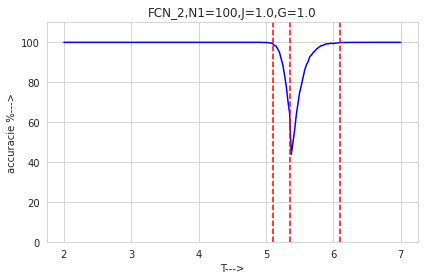

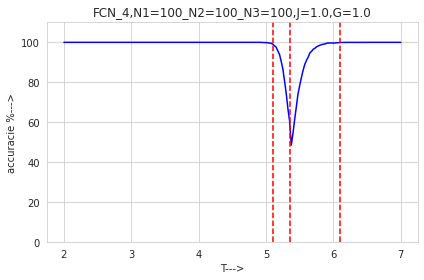

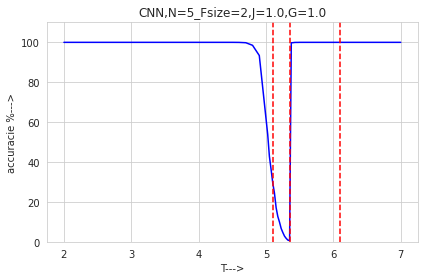

In [89]:
# Plottin all Networks accuriers  for J=1.0 , G=1.0 data
import matplotlib.pyplot as plt
import pickle

G_1_J_1_pkl_folder_path = "./G_1_J_1_data_in_pkl_format"
important_parameters_file_name = "important_parameters.pkl"
important_parameters_file_path = os.path.join(G_1_J_1_pkl_folder_path, important_parameters_file_name)
with open(important_parameters_file_path, 'rb') as f:
    important_parameters_dict = pickle.load(f)
    T_list = important_parameters_dict["T_list"]
    T_critical = important_parameters_dict["T_critical"]
    T_low_for_critical = important_parameters_dict["T_low_for_critical"] 
    T_up_for_critical = important_parameters_dict["T_up_for_critical"]

for key in FCN_2.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"FCN_2,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"FCN_2,{key},J=1.0,G=1.0")
    figure_file_name = f"FCN_2,{key},J=1.0,G=1.0.jpg"
    figure_file_path = os.path.join(shuffled_accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

for key in FCN_4.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"FCN_4,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"FCN_4,{key},J=1.0,G=1.0")
    figure_file_name = f"FCN_4,{key},J=1.0,G=1.0.jpg"
    figure_file_path = os.path.join(shuffled_accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

for key in CNN.keys():
    accuracies = []
    for T in T_list:
        accuracies.append(accuracies_dict[f"CNN,{key},T_{T:.6f}"])
    plt.figure()
    plt.plot(T_list,accuracies,"b")
    plt.axvline(x=T_critical,ls="--",c='r')
    plt.axvline(x=T_low_for_critical,ls="--",c='r')
    plt.axvline(x=T_up_for_critical,ls="--",c='r')
    plt.xlabel("T--->")
    plt.ylabel("accuracie %--->")
    plt.ylim([0,110])
    plt.grid(True)
    plt.title(f"CNN,{key},J=1.0,G=1.0")
    figure_file_name = f"CNN,{key},J=1.0,G=1.0.jpg"
    figure_file_path = os.path.join(shuffled_accuracies_folder_name,figure_file_name)
    plt.tight_layout()
    plt.savefig(figure_file_path)
    # plt.show()
    # Storing the the data related to the plot
    df_dict = {"T_list":list(T_list), "accuracies":list(accuracies)}
    df = pd.DataFrame(df_dict)
    figure_data_file_path = figure_file_path[0:-4] + ".csv"
    df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

In [90]:
import pandas as pd

G_1_J_1_pkl_folder_path = "./G_1_J_1_data_in_pkl_format"
important_parameters_file_name = "important_parameters.pkl"
important_parameters_file_path = os.path.join(G_1_J_1_pkl_folder_path, important_parameters_file_name)
with open(important_parameters_file_path, 'rb') as f:
    important_parameters_dict = pickle.load(f)
    T_list = important_parameters_dict["T_list"]
    T_critical = important_parameters_dict["T_critical"]
    T_low_for_critical = important_parameters_dict["T_low_for_critical"] 
    T_up_for_critical = important_parameters_dict["T_up_for_critical"]
    
    
    
critical_accuracies_dict = {}
non_critical_accuracies_dict = {}


accuracies_file_names_list = []
for file_name in os.listdir(shuffled_accuracies_folder_name):
    if file_name.endswith('.csv'):
        if file_name.find("J=1.0,G=1.0")>=0:
            accuracies_file_names_list.append(file_name)


for accuracy_file_name in accuracies_file_names_list:
    accuracy_file_path = os.path.join(shuffled_accuracies_folder_name, accuracy_file_name)
    df_all = pd.read_csv(accuracy_file_path, header=0)
    filt = (df_all['T_list'] >= T_low_for_critical) & (df_all['T_list'] <= T_up_for_critical)
    df_critical = df_all[filt]
    df_non_critical = df_all[~filt]
    critical_accuracies_dict[accuracy_file_name[0:-4]] = df_critical["accuracies"].mean()
    non_critical_accuracies_dict[accuracy_file_name[0:-4]] = df_non_critical["accuracies"].mean()

for pair in critical_accuracies_dict.items():
    print("critical accuracy -->",pair)
    
for pair in non_critical_accuracies_dict.items():
    print("non critical accuracy -->",pair)

critical accuracy --> ('FCN_2,N1=100,J=1.0,G=1.0', 86.76972972972973)
critical accuracy --> ('FCN_4,N1=100_N2=100_N3=100,J=1.0,G=1.0', 87.63648648648648)
critical accuracy --> ('CNN,N=5_Fsize=2,J=1.0,G=1.0', 73.25243243243244)
non critical accuracy --> ('FCN_2,N1=100,J=1.0,G=1.0', 99.97906976744184)
non critical accuracy --> ('FCN_4,N1=100_N2=100_N3=100,J=1.0,G=1.0', 99.97348837209302)
non critical accuracy --> ('CNN,N=5_Fsize=2,J=1.0,G=1.0', 95.92348837209302)


In [91]:
Phase_accuracies_shuffled_df.loc["J=1.0,G=1.0,Critical", "1_layer_DNN"] = critical_accuracies_dict["FCN_2,N1=100,J=1.0,G=1.0"]
Phase_accuracies_shuffled_df.loc["J=1.0,G=1.0,Critical", "3_layer_DNN"] = critical_accuracies_dict["FCN_4,N1=100_N2=100_N3=100,J=1.0,G=1.0"]
Phase_accuracies_shuffled_df.loc["J=1.0,G=1.0,Critical", "CNN"] = critical_accuracies_dict["CNN,N=5_Fsize=2,J=1.0,G=1.0"]
Phase_accuracies_shuffled_df.loc["J=1.0,G=1.0,Non-Critical", "1_layer_DNN"] = non_critical_accuracies_dict["FCN_2,N1=100,J=1.0,G=1.0"]
Phase_accuracies_shuffled_df.loc["J=1.0,G=1.0,Non-Critical", "3_layer_DNN"] = non_critical_accuracies_dict["FCN_4,N1=100_N2=100_N3=100,J=1.0,G=1.0"]
Phase_accuracies_shuffled_df.loc["J=1.0,G=1.0,Non-Critical", "CNN"] = non_critical_accuracies_dict["CNN,N=5_Fsize=2,J=1.0,G=1.0"]
Phase_accuracies_shuffled_df

,1_layer_DNN,3_layer_DNN,CNN,1_layer_DNN_FFT,3_layer_DNN_FFT,CNN_FFT
"J=1.0,G=0.0,Critical",86.257059,87.305294,80.840588,NaN,NaN,NaN
"J=1.0,G=0.0,Non-Critical",99.961818,99.963409,97.959318,NaN,NaN,NaN
"J=1.0,G=0.1,Critical",84.756471,85.915294,79.372941,NaN,NaN,NaN
"J=1.0,G=0.1,Non-Critical",99.939545,99.935227,95.744091,NaN,NaN,NaN
"J=1.0,G=0.5,Critical",85.6124,86.6004,74.7192,NaN,NaN,NaN
"J=1.0,G=0.5,Non-Critical",99.904444,99.905556,92.169722,NaN,NaN,NaN
"J=0.0,G=1.0,Critical",90.02,90.304,76.064,NaN,NaN,NaN
"J=0.0,G=1.0,Non-Critical",99.983415,99.976585,94.385366,NaN,NaN,NaN
"J=1.0,G=1.0,Critical",86.76973,87.636486,73.252432,NaN,NaN,NaN
"J=1.0,G=1.0,Non-Critical",99.97907,99.973488,95.923488,NaN,NaN,NaN
